# Reto Compartamos — Desarrollo del modelo logístico WOE

Notebook metodológico del modelo principal de riesgo crediticio.

## Objetivo de negocio

Construir una solución que permita **ordenar el riesgo de los clientes y apoyar la decisión de renovación**, buscando maximizar la cantidad de clientes habilitados manteniendo el nivel de default alrededor del objetivo definido por el reto.

## Datos

La versión entregada para el reto contiene **49 columnas**. La reducción respecto de la base interna responde a criterios de seguridad y anonimización de información.

## Modelo principal

- Regresión Logística con variables transformadas mediante WOE.
- Binning aprendido exclusivamente en TRAIN.
- Tratamiento explícito de valores centinela como bins especiales.
- Selección multivariada y Drop-One hasta llegar a **18 variables finales**.
- Coarse classing manual en 2 variables.
- Sin Feature Engineering adicional en el modelo principal.
- Sin regularización en el modelo principal.

## Principio metodológico

> **TRAIN aprende → VALIDATION decide → OOT confirma**

TRAIN se utiliza para estimar bins y coeficientes.  
VALIDATION se utiliza para comparar alternativas y tomar decisiones de selección.  
OOT se reserva para comprobar el comportamiento temporal del modelo ya definido.




## Flujo del notebook

1. Carga y diagnóstico inicial  
2. Definición de variables y partición temporal  
3. Análisis univariado  
4. Missing y valores centinela  
5. Selección univariada  
6. Binning WOE e Information Value  
7. Estabilidad temporal y correlación  
8. Selección multivariada  
9. Revisión visual y coarse classing  
10. Modelo candidato de 20 variables  
11. Selección final mediante Drop-One  
12. Modelo final de 18 variables y performance  
13. Deciles y lift  
14. Calibración general  
15. Backtesting estadístico de PD por bandas  
16. Política de renovación con cutoffs enteros de PD  
17. Cierre metodológico  

La lógica del proyecto es:

**datos → calidad → WOE → selección → logística → validación → PD → decisión de renovación**

La decisión operativa final se comunicará directamente mediante **PD**.



# 1. Carga y diagnóstico inicial

In [1]:
# ============================================================
# FASE 0 — DIAGNÓSTICO INICIAL DE LA BASE
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np


# ============================================================
# 0.1 — CARGAR LA BASE
# ============================================================

# Cargamos la base original
ROOT = Path.cwd().resolve()
if not (ROOT / "data").is_dir():
    ROOT = ROOT.parent
DATA_PATH = ROOT / "data" / "raw" / "base_analytics_lab_061628.parquet"
if not DATA_PATH.is_file():
    raise FileNotFoundError(f"No se encontró la base en: {DATA_PATH}")

df_raw = pd.read_parquet(DATA_PATH)

# Creamos una copia para trabajar sin modificar la base original
df = df_raw.copy()


# ============================================================
# 0.2 — DIMENSIONES
# ============================================================

print("=" * 60)
print("DIMENSIONES DE LA BASE")
print("=" * 60)

print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])


# ============================================================
# 0.3 — PRIMERAS FILAS
# ============================================================

print("\n" + "=" * 60)
print("PRIMERAS 5 FILAS")
print("=" * 60)

display(df.head())


# ============================================================
# 0.4 — NOMBRES DE LAS COLUMNAS
# ============================================================

print("\n" + "=" * 60)
print("VARIABLES DE LA BASE")
print("=" * 60)

for i, columna in enumerate(df.columns, start=1):
    print(i, columna)


# ============================================================
# 0.5 — TIPOS DE DATOS
# ============================================================

print("\n" + "=" * 60)
print("TIPOS DE DATOS")
print("=" * 60)

print(df.dtypes)


# ============================================================
# 0.6 — RESUMEN DE TIPOS
# ============================================================

resumen_tipos = pd.DataFrame({
    "variable": df.columns,
    "tipo": df.dtypes.astype(str).values
})

print("\n" + "=" * 60)
print("RESUMEN DE TIPOS")
print("=" * 60)

display(resumen_tipos)


# ============================================================
# 0.7 — REVISIÓN DEL TARGET
# ============================================================

print("\n" + "=" * 60)
print("DISTRIBUCIÓN DEL TARGET")
print("=" * 60)

print("\nCantidad:")
print(df["TARGET"].value_counts(dropna=False))

print("\nPorcentaje:")
print(
    df["TARGET"]
      .value_counts(normalize=True, dropna=False)
      .mul(100)
      .round(2)
)


# ============================================================
# 0.8 — REVISIÓN DE CODMES
# ============================================================

print("\n" + "=" * 60)
print("DISTRIBUCIÓN DE CODMES")
print("=" * 60)

print(df["CODMES"].value_counts().sort_index())

print("\nPrimer mes:", df["CODMES"].min())
print("Último mes:", df["CODMES"].max())


# ============================================================
# 0.9 — CANTIDAD DE REGISTROS POR MES
# ============================================================

registros_por_mes = (
    df.groupby("CODMES")
      .size()
      .reset_index(name="cantidad")
)

print("\n" + "=" * 60)
print("REGISTROS POR MES")
print("=" * 60)

display(registros_por_mes)


# ============================================================
# 0.10 — TASA DE MALOS POR MES
# ============================================================

tasa_malos_mes = (
    df.groupby("CODMES")["TARGET"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

# Convertimos la proporción a porcentaje
tasa_malos_mes["tasa_malos_%"] = (
    tasa_malos_mes["mean"] * 100
).round(2)

# Eliminamos mean porque ya tenemos la versión en porcentaje
tasa_malos_mes = tasa_malos_mes.drop(columns="mean")

print("\n" + "=" * 60)
print("TASA DE MALOS POR MES")
print("=" * 60)

display(tasa_malos_mes)


# ============================================================
# 0.11 — VALORES NULOS
# ============================================================

resumen_nulos = pd.DataFrame({
    "variable": df.columns,
    "nulos": df.isnull().sum().values,
    "porcentaje_nulos": (df.isnull().mean().values * 100).round(2)
})

resumen_nulos = resumen_nulos.sort_values(
    by="porcentaje_nulos",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 60)
print("RESUMEN DE NULOS")
print("=" * 60)

display(resumen_nulos)


# ============================================================
# 0.12 — CARDINALIDAD
# ============================================================

resumen_cardinalidad = pd.DataFrame({
    "variable": df.columns,
    "valores_unicos": df.nunique(dropna=False).values
})

resumen_cardinalidad = resumen_cardinalidad.sort_values(
    by="valores_unicos",
    ascending=True
).reset_index(drop=True)

print("\n" + "=" * 60)
print("CARDINALIDAD DE LAS VARIABLES")
print("=" * 60)

display(resumen_cardinalidad)


# ============================================================
# 0.13 — VARIABLES CONSTANTES
# ============================================================

variables_constantes = [
    columna
    for columna in df.columns
    if df[columna].nunique(dropna=False) <= 1
]

print("\n" + "=" * 60)
print("VARIABLES CONSTANTES")
print("=" * 60)

if len(variables_constantes) == 0:
    print("No se encontraron variables constantes.")
else:
    print(variables_constantes)


# ============================================================
# 0.14 — DUPLICADOS COMPLETOS
# ============================================================

cantidad_duplicados = df.duplicated().sum()
porcentaje_duplicados = df.duplicated().mean() * 100

print("\n" + "=" * 60)
print("DUPLICADOS COMPLETOS")
print("=" * 60)

print("Cantidad de filas duplicadas:", cantidad_duplicados)
print("Porcentaje de duplicados:", round(porcentaje_duplicados, 2), "%")


# ============================================================
# 0.15 — TABLA RESUMEN GENERAL
# ============================================================

resumen_variables = pd.DataFrame({
    "variable": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "valores_unicos": df.nunique(dropna=False).values,
    "nulos": df.isnull().sum().values,
    "porcentaje_nulos": (df.isnull().mean().values * 100).round(2)
})

resumen_variables = resumen_variables.sort_values(
    by="porcentaje_nulos",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 60)
print("RESUMEN GENERAL DE VARIABLES")
print("=" * 60)

display(resumen_variables)


# ============================================================
# 0.16 — ESTADÍSTICOS DESCRIPTIVOS
# ============================================================

print("\n" + "=" * 60)
print("ESTADÍSTICOS DESCRIPTIVOS")
print("=" * 60)

display(df.describe().T)


# ============================================================
# RESUMEN FINAL DEL DIAGNÓSTICO
# ============================================================

print("\n" + "=" * 60)
print("RESUMEN FINAL")
print("=" * 60)

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
print("Periodo:", df["CODMES"].min(), "-", df["CODMES"].max())
print("Tasa global de malos:", round(df["TARGET"].mean() * 100, 2), "%")
print("Variables constantes:", len(variables_constantes))
print("Filas duplicadas:", cantidad_duplicados)
print("Variables con algún nulo:", (df.isnull().sum() > 0).sum())

DIMENSIONES DE LA BASE
Número de filas: 60000
Número de columnas: 49

PRIMERAS 5 FILAS


,CODMES,TARGET,MEDIDA1_MORA_INTERNA_U6M,MEDIDA1_MORA_INTERNA_U12M,MEDIDA1_MORA_INTERNA_U1M,MEDIDA2_MORA_INTERNA_U12M,MEDIDA2_MORA_INTERNA_U6M,MEDIDA3_MORA_INTERNA_U12M,MEDIDA1_APALANCAMIENTO_INTERNO_U6M,MEDIDA2_APALANCAMIENTO_INTERNO_U6M,...,MEDIDA2_PRODUCTOS_SSFF_U3M,MEDIDA1_LINEA_TARJETACREDITO,PREDICCION_MODELO_ANTERIOR,PROXY_TARGET_6M,MEDIDA1_TRX_CASHIN_U3M,MEDIDA2_TRX_TRANSFER_U1M,MEDIDA3_TRX_QR_U1M,MEDIDA4_TRX_DEBITO_U1M,MEDIDA5_TRX_ECOM_U1M,MEDIDA6_TRX_APP_U1M
0,202308,0,0,0,-1,99,99,0,0.853261,1.000000,...,2.0,NaN,0.250741,0,26.740000,NaN,NaN,1.0,51.860001,1
1,202401,1,4,4,1,99,0,5,0.706940,0.897245,...,5.0,NaN,0.605026,0,71.269997,89.379997,NaN,6.0,49.099998,1
2,202402,0,3,3,3,99,0,6,0.392161,0.869825,...,2.0,NaN,0.601767,0,40.180000,136.169998,NaN,1.0,153.330002,1
3,202307,1,21,21,21,0,0,2,0.706261,1.049905,...,3.0,NaN,0.665567,0,739.659973,NaN,NaN,2.0,176.559998,0
4,202307,1,0,0,0,99,99,0,1.000000,1.238984,...,4.0,NaN,0.564676,1,374.079987,291.910004,NaN,3.0,59.529999,0



VARIABLES DE LA BASE
1 CODMES
2 TARGET
3 MEDIDA1_MORA_INTERNA_U6M
4 MEDIDA1_MORA_INTERNA_U12M
5 MEDIDA1_MORA_INTERNA_U1M
6 MEDIDA2_MORA_INTERNA_U12M
7 MEDIDA2_MORA_INTERNA_U6M
8 MEDIDA3_MORA_INTERNA_U12M
9 MEDIDA1_APALANCAMIENTO_INTERNO_U6M
10 MEDIDA2_APALANCAMIENTO_INTERNO_U6M
11 SOCIODEMOGRAFICO_1
12 MEDIDA2_APALANCAMIENTO_INTERNO_U12M
13 SOCIODEMOGRAFICO_4
14 MEDIDA3_APALANCAMIENTO_INTERNO_U1M
15 SOCIODEMOGRAFICO_3
16 SOCIODEMOGRAFICO_2
17 MEDIDA1_AHORRO
18 MEDIDA1_MORA_SSFF_U36M
19 MEDIDA1_MORA_SSFF_U12M
20 MEDIDA2_MORA_SSFF_U36M
21 MEDIDA2_MORA_SSFF_U6M
22 MEDIDA1_APALANCAMIENTO_SSFF_U36M
23 MEDIDA1_DESAPALANCAMIENTO_SSFF_U12M
24 MEDIDA1_APALANCAMIENTO_SSFF_U6M
25 MEDIDA2_APALANCAMIENTO_SSFF_U36M
26 MEDIDA3_APALANCAMIENTO_SSFF_U12M
27 MEDIDA3_APALANCAMIENTO_SSFF_U6M
28 MEDIDA2_APALANCAMIENTO_SSFF_U12M
29 MEDIDA1_PRODUCTOS_SSFF_U1M
30 DEUDA_PROMEDIO_SSFF
31 MEDIDA1_ENTIDADES_SSFF_U12M
32 MEDIDA4_DEUDA_SSFF_U1M
33 MEDIDA3_MORA_SSFF_U36M
34 MEDIDA1_CALIFICACION_SSFF_U60M
35 MEDIDA1_

,variable,tipo
0,CODMES,int32
1,TARGET,int16
2,MEDIDA1_MORA_INTERNA_U6M,int16
3,MEDIDA1_MORA_INTERNA_U12M,int16
4,MEDIDA1_MORA_INTERNA_U1M,int16
5,MEDIDA2_MORA_INTERNA_U12M,int16
6,MEDIDA2_MORA_INTERNA_U6M,int16
7,MEDIDA3_MORA_INTERNA_U12M,int16
8,MEDIDA1_APALANCAMIENTO_INTERNO_U6M,float32
9,MEDIDA2_APALANCAMIENTO_INTERNO_U6M,float32



DISTRIBUCIÓN DEL TARGET

Cantidad:
TARGET
0    50709
1     9291
Name: count, dtype: int64

Porcentaje:
TARGET
0    84.52
1    15.48
Name: proportion, dtype: float64

DISTRIBUCIÓN DE CODMES
CODMES
202306    4340
202307    4436
202308    4595
202309    4742
202310    4875
202311    5042
202312    5179
202401    5253
202402    5263
202403    5320
202404    5425
202405    5530
Name: count, dtype: int64

Primer mes: 202306
Último mes: 202405

REGISTROS POR MES


...


VARIABLES CONSTANTES
No se encontraron variables constantes.

DUPLICADOS COMPLETOS
Cantidad de filas duplicadas: 0
Porcentaje de duplicados: 0.0 %

RESUMEN GENERAL DE VARIABLES


,variable,tipo,valores_unicos,nulos,porcentaje_nulos
0,MEDIDA1_AHORRO,float32,707,59276,98.79
1,MEDIDA3_TRX_QR_U1M,float32,3,58803,98.00
2,MEDIDA1_LINEA_TARJETACREDITO,float32,9036,42754,71.26
3,SOCIODEMOGRAFICO_4,float32,8,27919,46.53
4,MEDIDA2_TRX_TRANSFER_U1M,float32,29722,27169,45.28
5,MEDIDA1_TRX_CASHIN_U3M,float32,29617,8854,14.76
6,MEDIDA5_TRX_ECOM_U1M,float32,24904,5871,9.78
7,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M,float32,8,3440,5.73
8,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M,float32,14,3110,5.18
9,SOCIODEMOGRAFICO_1,float32,5,2879,4.80



ESTADÍSTICOS DESCRIPTIVOS


,count,mean,std,min,25%,50%,75%,max
CODMES,60000.0,2.023511e+05,4.671726e+01,202306.000000,202309.000000,202312.000000,202403.000000,2.024050e+05
TARGET,60000.0,1.548500e-01,3.617646e-01,0.000000,0.000000,0.000000,0.000000,1.000000e+00
MEDIDA1_MORA_INTERNA_U6M,60000.0,3.528583e+00,7.187870e+00,-62.000000,0.000000,1.000000,5.000000,7.200000e+02
MEDIDA1_MORA_INTERNA_U12M,60000.0,4.585883e+00,8.303195e+00,-28.000000,0.000000,2.000000,6.000000,7.200000e+02
MEDIDA1_MORA_INTERNA_U1M,60000.0,5.978333e-01,7.105310e+00,-191.000000,0.000000,0.000000,2.000000,2.900000e+01
MEDIDA2_MORA_INTERNA_U12M,60000.0,8.244858e+01,3.626797e+01,0.000000,99.000000,99.000000,99.000000,9.900000e+01
MEDIDA2_MORA_INTERNA_U6M,60000.0,4.031585e+01,4.817092e+01,0.000000,0.000000,2.000000,99.000000,9.900000e+01
MEDIDA3_MORA_INTERNA_U12M,60000.0,2.719917e+00,3.155609e+00,0.000000,0.000000,1.000000,4.000000,1.200000e+01
MEDIDA1_APALANCAMIENTO_INTERNO_U6M,60000.0,7.544660e-01,2.230920e-01,0.000536,0.624555,0.807751,0.935555,1.000000e+00
MEDIDA2_APALANCAMIENTO_INTERNO_U6M,60000.0,9.916896e-01,2.450844e-01,0.028891,0.872386,0.964375,1.000000,3.988093e+00



RESUMEN FINAL
Filas: 60000
Columnas: 49
Periodo: 202306 - 202405
Tasa global de malos: 15.48 %
Variables constantes: 0
Filas duplicadas: 0
Variables con algún nulo: 26


### ¿Qué buscamos en el diagnóstico inicial?

Antes de modelar necesitamos saber con qué tipo de problema estamos trabajando. El diagnóstico inicial responde preguntas básicas:

- ¿Cuántas filas y columnas existen?
- ¿Cuál es el tipo de dato de cada variable?
- ¿Hay duplicados?
- ¿Cuánto missing existe?
- ¿Cómo está distribuido el TARGET?
- ¿Qué meses están disponibles?

Esto no es todavía "modelamiento". Es una revisión de calidad y estructura.

En este proyecto partimos de **60,000 observaciones y 49 columnas**. La variable objetivo es binaria:

- `TARGET = 0`: sin evento.
- `TARGET = 1`: con evento de incumplimiento.

La tasa global de malos es aproximadamente **15.5%**. Existe desbalance, pero no es extremo; para un scorecard tradicional no es necesario aplicar SMOTE automáticamente.

> **Concepto para recordar:** antes de corregir algo debemos distinguir entre un dato realmente erróneo y un valor extraño que tiene significado de negocio.


# 2. Definición de variables y partición temporal

Antes de modelar se separan las variables que no deben utilizarse como predictores y se define una validación temporal.

Se excluyen:

- `TARGET`: variable objetivo.
- `CODMES`: se utiliza para construir la partición temporal.
- `PREDICCION_MODELO_ANTERIOR`: se conserva únicamente como benchmark.
- `PROXY_TARGET_6M`: contiene información futura y produciría leakage.

La separación temporal es:

- **TRAIN:** hasta 202401.
- **VALIDATION:** 202402–202403.
- **OOT:** 202404–202405.

### ¿Por qué una partición temporal?

En riesgo crediticio no basta con funcionar sobre una muestra aleatoria del mismo período. El modelo será utilizado sobre clientes futuros.

Por eso simulamos el flujo real:

> **TRAIN aprende → VALIDATION decide → OOT confirma**

El modelo nunca debe aprender bins, coeficientes o reglas operativas utilizando información de OOT.


In [2]:
# ============================================================
# FASE 1 — DEFINICIÓN DE VARIABLES
# ============================================================

# Variable objetivo
TARGET = "TARGET"

# Variable temporal
TIEMPO = "CODMES"

# Benchmark: se guarda para comparar al final,
# pero NO será predictor del nuevo modelo
BENCHMARK = "PREDICCION_MODELO_ANTERIOR"


# Variables que NO pueden entrar al modelo
variables_excluir = [
    "TARGET",                       # Es lo que queremos predecir
    "CODMES",                       # La usamos para la separación temporal
    "PREDICCION_MODELO_ANTERIOR",   # Benchmark, no predictor
    "PROXY_TARGET_6M"               # Tiene información futura / leakage
]


# Variables candidatas iniciales
variables_modelo = [
    columna
    for columna in df.columns
    if columna not in variables_excluir
]


print("Total columnas originales:", df.shape[1])
print("Variables excluidas:", len(variables_excluir))
print("Variables candidatas:", len(variables_modelo))

print("\nVariables excluidas:")
for variable in variables_excluir:
    print("-", variable)

Total columnas originales: 49
Variables excluidas: 4
Variables candidatas: 45

Variables excluidas:
- TARGET
- CODMES
- PREDICCION_MODELO_ANTERIOR
- PROXY_TARGET_6M


In [3]:
# ============================================================
# COMPROBACIÓN
# ============================================================

for variable in variables_excluir:

    if variable in df.columns:
        print(variable, "→ OK")

    else:
        print(variable, "→ NO EXISTE")

TARGET → OK
CODMES → OK
PREDICCION_MODELO_ANTERIOR → OK
PROXY_TARGET_6M → OK


In [4]:
# ============================================================
# FASE 2 — PARTICIÓN TEMPORAL
# ============================================================


# TRAIN
train = df[
    df["CODMES"] <= 202401
].copy()


# VALIDACIÓN TEMPORAL
validation = df[
    df["CODMES"].isin([202402, 202403])
].copy()


# OUT OF TIME
oot = df[
    df["CODMES"].isin([202404, 202405])
].copy()

In [5]:
# ============================================================
# REVISAR PERIODOS
# ============================================================

print("TRAIN")
print("Filas:", len(train))
print("Periodo:", train["CODMES"].min(), "-", train["CODMES"].max())


print("\nVALIDATION")
print("Filas:", len(validation))
print("Periodo:", validation["CODMES"].min(), "-", validation["CODMES"].max())


print("\nOOT")
print("Filas:", len(oot))
print("Periodo:", oot["CODMES"].min(), "-", oot["CODMES"].max())

TRAIN
Filas: 38462
Periodo: 202306 - 202401

VALIDATION
Filas: 10583
Periodo: 202402 - 202403

OOT
Filas: 10955
Periodo: 202404 - 202405


In [6]:
# ============================================================
# COMPROBAR PARTICIÓN
# ============================================================

total_particiones = (
    len(train)
    + len(validation)
    + len(oot)
)

print("Dataset original:", len(df))
print("Train + Validation + OOT:", total_particiones)

print(
    "¿Todas las observaciones fueron asignadas?",
    len(df) == total_particiones
)

Dataset original: 60000
Train + Validation + OOT: 60000
¿Todas las observaciones fueron asignadas? True


In [7]:
# ============================================================
# TASA DE MALOS POR MUESTRA
# ============================================================

print(
    "TRAIN:",
    round(train["TARGET"].mean() * 100, 2),
    "%"
)

print(
    "VALIDATION:",
    round(validation["TARGET"].mean() * 100, 2),
    "%"
)

print(
    "OOT:",
    round(oot["TARGET"].mean() * 100, 2),
    "%"
)

TRAIN: 16.02 %
VALIDATION: 14.95 %
OOT: 14.13 %


In [8]:
# ============================================================
# RESUMEN DE PARTICIONES
# ============================================================

resumen_particiones = pd.DataFrame({

    "muestra": [
        "TRAIN",
        "VALIDATION",
        "OOT"
    ],

    "filas": [
        len(train),
        len(validation),
        len(oot)
    ],

    "desde": [
        train["CODMES"].min(),
        validation["CODMES"].min(),
        oot["CODMES"].min()
    ],

    "hasta": [
        train["CODMES"].max(),
        validation["CODMES"].max(),
        oot["CODMES"].max()
    ],

    "malos": [
        train["TARGET"].sum(),
        validation["TARGET"].sum(),
        oot["TARGET"].sum()
    ],

    "tasa_malos_%": [
        train["TARGET"].mean() * 100,
        validation["TARGET"].mean() * 100,
        oot["TARGET"].mean() * 100
    ]
})


resumen_particiones["tasa_malos_%"] = (
    resumen_particiones["tasa_malos_%"]
    .round(2)
)

resumen_particiones

,muestra,filas,desde,hasta,malos,tasa_malos_%
0,TRAIN,38462,202306,202401,6161,16.02
1,VALIDATION,10583,202402,202403,1582,14.95
2,OOT,10955,202404,202405,1548,14.13


In [9]:
# ============================================================
# SEPARAR PREDICTORES Y TARGET
# ============================================================

# TRAIN
X_train = train[variables_modelo].copy()
y_train = train[TARGET].copy()


# VALIDATION
X_validation = validation[variables_modelo].copy()
y_validation = validation[TARGET].copy()


# OOT
X_oot = oot[variables_modelo].copy()
y_oot = oot[TARGET].copy()


print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_oot:", X_oot.shape)

X_train: (38462, 45)
X_validation: (10583, 45)
X_oot: (10955, 45)


### ¿Por qué excluimos algunas variables antes de modelar?

No toda columna disponible debe convertirse en predictor.

Se excluyeron:

- `TARGET`: es lo que queremos predecir.
- `CODMES`: se utiliza para ordenar temporalmente la información y construir las muestras.
- `PREDICCION_MODELO_ANTERIOR`: se conserva como benchmark, no como predictor principal.
- `PROXY_TARGET_6M`: contiene información demasiado cercana al futuro del target y representa riesgo de **data leakage**.

**Data leakage** ocurre cuando el modelo recibe información que no estaría disponible en el momento real de tomar la decisión. Puede producir métricas artificialmente altas y un modelo inútil en producción.

### ¿Por qué usamos una partición temporal?

En riesgo crediticio queremos entrenar con el pasado y comprobar si el modelo funciona en periodos posteriores. Por eso no utilizamos como diseño principal un split aleatorio.

- **TRAIN:** hasta `202401`
- **VALIDATION:** `202402–202403`
- **OOT:** `202404–202405`

TRAIN aprende parámetros y bins. VALIDATION ayuda a tomar decisiones de modelamiento. OOT se utiliza para observar desempeño temporal posterior.

$
\text{Pasado} \rightarrow \text{entrenamiento}
\qquad
\text{Futuro cercano} \rightarrow \text{validación}
\qquad
\text{Futuro posterior} \rightarrow \text{OOT}
$

> **Error común:** seleccionar variables mirando repetidamente OOT. Eso convierte OOT, en la práctica, en otra muestra de validación.


## Decisión metodológica — ¿Por qué WOE + Regresión Logística?

La elección del modelo no se realiza únicamente buscando maximizar Gini.

El reto requiere una solución que pueda ser:

- interpretada;
- auditada;
- validada de forma independiente;
- implementada con facilidad;
- monitoreada en el tiempo.

La combinación **WOE + Regresión Logística** permite:

1. representar relaciones no lineales mediante bins;
2. tratar valores centinela como estados de negocio independientes;
3. observar directamente la tasa de malos de cada grupo;
4. reducir redundancia entre predictores;
5. entender la dirección del riesgo;
6. explicar por qué una característica aumenta o reduce la PD;
7. trabajar con un número reducido de variables;
8. simplificar implementación y mantenimiento.

Por tanto, la regresión logística se utiliza como **modelo principal interpretable**.

En un notebook separado se construirá un **CatBoost benchmark** con el mismo split temporal y las mismas exclusiones de leakage. Su objetivo será medir cuánto desempeño adicional aporta una alternativa más compleja, no modificar retrospectivamente la selección del modelo logístico.


# 3. Análisis univariado

Todo este análisis se hace solo con TRAIN. Las banderas son alertas; no implican eliminar una variable automáticamente.

In [10]:
# ============================================================
# FASE 3 — ANÁLISIS UNIVARIADO SOLO EN TRAIN
# ============================================================

resultados_univariado = []


for variable in variables_modelo:

    # Tomamos únicamente la variable dentro de TRAIN
    serie = train[variable]

    # Observaciones que realmente tienen un valor
    observados = serie.dropna()

    # Porcentaje de valores nulos
    porcentaje_missing = serie.isna().mean() * 100

    # Cantidad de valores diferentes sin contar NaN
    valores_unicos = observados.nunique()

    # Porcentaje correspondiente al valor más frecuente
    if len(observados) > 0:
        porcentaje_moda = observados.value_counts(normalize=True).iloc[0] * 100
    else:
        porcentaje_moda = 100

    # Guardamos todos los resultados
    resultados_univariado.append({

        "variable": variable,

        "missing_%": round(porcentaje_missing, 2),

        "valores_unicos": valores_unicos,

        "moda_%": round(porcentaje_moda, 2),

        "min": observados.min() if len(observados) > 0 else np.nan,

        "p01": observados.quantile(0.01) if len(observados) > 0 else np.nan,

        "p25": observados.quantile(0.25) if len(observados) > 0 else np.nan,

        "mediana": observados.median() if len(observados) > 0 else np.nan,

        "p75": observados.quantile(0.75) if len(observados) > 0 else np.nan,

        "p99": observados.quantile(0.99) if len(observados) > 0 else np.nan,

        "max": observados.max() if len(observados) > 0 else np.nan,

        "std": observados.std() if len(observados) > 0 else np.nan
    })


# Convertimos los resultados en DataFrame
univariado = pd.DataFrame(resultados_univariado)


# Ordenamos primero por porcentaje de missing
univariado = univariado.sort_values(
    by="missing_%",
    ascending=False
).reset_index(drop=True)


display(univariado)

,variable,missing_%,valores_unicos,moda_%,min,p01,p25,mediana,p75,p99,max,std
0,MEDIDA1_AHORRO,98.76,464,1.26,200.000000,202.993332,401.915833,865.335022,2850.260010,5.204203e+04,1.005621e+05,8.970686e+03
1,MEDIDA3_TRX_QR_U1M,97.92,2,59.82,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000e+00,1.000000e+00,4.905594e-01
2,MEDIDA1_LINEA_TARJETACREDITO,71.12,6085,5.01,1.000000,92.889420,1200.000000,2771.130859,6717.708008,5.170341e+04,2.174994e+05,1.115378e+04
3,SOCIODEMOGRAFICO_4,50.07,7,58.36,1.000000,1.000000,1.000000,1.000000,5.000000,7.000000e+00,7.000000e+00,1.836033e+00
4,MEDIDA2_TRX_TRANSFER_U1M,45.22,19778,0.02,8.180000,57.494499,295.847504,585.505005,1157.557495,6.311174e+03,2.683563e+04,1.306668e+03
5,MEDIDA1_TRX_CASHIN_U3M,14.74,21184,0.03,1.070000,6.119300,38.689999,94.370003,235.199997,1.570980e+03,1.028023e+04,3.366298e+02
6,MEDIDA5_TRX_ECOM_U1M,9.92,19665,0.03,1.020000,11.254500,48.740002,90.160004,165.157501,7.596075e+02,3.272450e+03,1.529016e+02
7,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M,5.96,7,27.20,0.000000,0.000000,2.000000,4.000000,6.000000,6.000000e+00,6.000000e+00,1.782809e+00
8,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M,5.43,13,13.00,0.000000,0.000000,3.000000,5.000000,8.000000,1.200000e+01,1.200000e+01,3.135081e+00
9,SOCIODEMOGRAFICO_1,4.52,4,45.82,1.000000,1.000000,2.000000,3.000000,3.000000,4.000000e+00,4.000000e+00,8.549851e-01


In [11]:
# ============================================================
# CREAR BANDERAS DE REVISIÓN
# ============================================================

# Missing extremo: 90% o más
univariado["flag_missing_extremo"] = (
    univariado["missing_%"] >= 90
)


# Variable casi constante:
# 99.5% o más de los valores observados son iguales
univariado["flag_casi_constante"] = (
    univariado["moda_%"] >= 99.5
)


# Variable sin variabilidad
univariado["flag_sin_variacion"] = (
    univariado["valores_unicos"] <= 1
)


display(
    univariado[
        [
            "variable",
            "missing_%",
            "valores_unicos",
            "moda_%",
            "flag_missing_extremo",
            "flag_casi_constante",
            "flag_sin_variacion"
        ]
    ]
)

,variable,missing_%,valores_unicos,moda_%,flag_missing_extremo,flag_casi_constante,flag_sin_variacion
0,MEDIDA1_AHORRO,98.76,464,1.26,True,False,False
1,MEDIDA3_TRX_QR_U1M,97.92,2,59.82,True,False,False
2,MEDIDA1_LINEA_TARJETACREDITO,71.12,6085,5.01,False,False,False
3,SOCIODEMOGRAFICO_4,50.07,7,58.36,False,False,False
4,MEDIDA2_TRX_TRANSFER_U1M,45.22,19778,0.02,False,False,False
5,MEDIDA1_TRX_CASHIN_U3M,14.74,21184,0.03,False,False,False
6,MEDIDA5_TRX_ECOM_U1M,9.92,19665,0.03,False,False,False
7,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M,5.96,7,27.20,False,False,False
8,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M,5.43,13,13.00,False,False,False
9,SOCIODEMOGRAFICO_1,4.52,4,45.82,False,False,False


In [12]:
# ============================================================
# MOTIVO DE REVISIÓN
# ============================================================

def motivo_revision(fila):

    motivos = []

    if fila["flag_missing_extremo"]:
        motivos.append("Missing >= 90%")

    if fila["flag_casi_constante"]:
        motivos.append("Moda >= 99.5%")

    if fila["flag_sin_variacion"]:
        motivos.append("Sin variación")

    if len(motivos) == 0:
        return "OK"

    return " | ".join(motivos)


univariado["revision"] = univariado.apply(
    motivo_revision,
    axis=1
)


display(
    univariado[
        [
            "variable",
            "missing_%",
            "valores_unicos",
            "moda_%",
            "revision"
        ]
    ]
)

,variable,missing_%,valores_unicos,moda_%,revision
0,MEDIDA1_AHORRO,98.76,464,1.26,Missing >= 90%
1,MEDIDA3_TRX_QR_U1M,97.92,2,59.82,Missing >= 90%
2,MEDIDA1_LINEA_TARJETACREDITO,71.12,6085,5.01,OK
3,SOCIODEMOGRAFICO_4,50.07,7,58.36,OK
4,MEDIDA2_TRX_TRANSFER_U1M,45.22,19778,0.02,OK
5,MEDIDA1_TRX_CASHIN_U3M,14.74,21184,0.03,OK
6,MEDIDA5_TRX_ECOM_U1M,9.92,19665,0.03,OK
7,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M,5.96,7,27.20,OK
8,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M,5.43,13,13.00,OK
9,SOCIODEMOGRAFICO_1,4.52,4,45.82,OK


In [13]:
# ============================================================
# VARIABLES QUE NECESITAN REVISIÓN
# ============================================================

variables_revisar = univariado[
    univariado["revision"] != "OK"
].copy()


display(
    variables_revisar[
        [
            "variable",
            "missing_%",
            "valores_unicos",
            "moda_%",
            "revision"
        ]
    ]
)

,variable,missing_%,valores_unicos,moda_%,revision
0,MEDIDA1_AHORRO,98.76,464,1.26,Missing >= 90%
1,MEDIDA3_TRX_QR_U1M,97.92,2,59.82,Missing >= 90%


In [14]:
# ============================================================
# VARIABLES CON POCOS VALORES DIFERENTES
# ============================================================

baja_cardinalidad = univariado[
    univariado["valores_unicos"] <= 15
].copy()


display(
    baja_cardinalidad[
        [
            "variable",
            "valores_unicos",
            "missing_%",
            "min",
            "mediana",
            "max"
        ]
    ]
)

,variable,valores_unicos,missing_%,min,mediana,max
1,MEDIDA3_TRX_QR_U1M,2,97.92,0.0,0.0,1.0
3,SOCIODEMOGRAFICO_4,7,50.07,1.0,1.0,7.0
7,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M,7,5.96,0.0,4.0,6.0
8,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M,13,5.43,0.0,5.0,12.0
9,SOCIODEMOGRAFICO_1,4,4.52,1.0,3.0,4.0
19,SOCIODEMOGRAFICO_2,6,1.16,1.0,3.0,8.0
22,MEDIDA1_CALIFICACION_SSFF_U60M,5,0.81,0.0,0.0,4.0
27,MEDIDA2_MORA_INTERNA_U12M,13,0.00,0.0,99.0,99.0
28,MEDIDA2_MORA_INTERNA_U6M,7,0.00,0.0,2.0,99.0
33,MEDIDA3_MORA_INTERNA_U12M,13,0.00,0.0,1.0,12.0


In [15]:
# ============================================================
# VALORES DE VARIABLES DE BAJA CARDINALIDAD
# ============================================================

for variable in baja_cardinalidad["variable"]:

    print("\n" + "=" * 70)
    print(variable)
    print("=" * 70)

    print(
        train[variable]
        .value_counts(dropna=False)
        .sort_index()
    )


MEDIDA3_TRX_QR_U1M
MEDIDA3_TRX_QR_U1M
0.0      478
1.0      321
NaN    37663
Name: count, dtype: int64

SOCIODEMOGRAFICO_4
SOCIODEMOGRAFICO_4
1.0    11208
2.0     2254
3.0      234
4.0      383
5.0     4537
6.0      201
7.0      387
NaN    19258
Name: count, dtype: int64

MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M
MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M
0.0     847
1.0    3503
2.0    5289
3.0    7201
4.0    5535
5.0    3955
6.0    9838
NaN    2294
Name: count, dtype: int64

MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M
MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M
0.0      649
1.0     2666
2.0     3081
3.0     4206
4.0     4729
5.0     4432
6.0     4208
7.0     3162
8.0     2452
9.0     1901
10.0    1476
11.0    1054
12.0    2357
NaN     2089
Name: count, dtype: int64

SOCIODEMOGRAFICO_1
SOCIODEMOGRAFICO_1
1.0     4717
2.0    11004
3.0    16829
4.0     4175
NaN     1737
Name: count, dtype: int64

SOCIODEMOGRAFICO_2
SOCIODEMOGRAFICO_2
1.0     2116
2.0     5877
3.0    28534
4.0     1303
7.0      116
8.0    

### ¿Qué es el análisis univariado?

El análisis univariado estudia cada predictor por separado antes de combinarlo con los demás.

Revisamos, entre otras cosas:

- porcentaje de missing;
- cardinalidad;
- distribución de valores;
- variables casi constantes;
- valores extremos o códigos especiales;
- relación preliminar con el target.

Las banderas generadas en esta etapa **no significan eliminación automática**. Son alertas para investigar.

Una variable puede tener muchos missing y seguir siendo útil si el missing representa un comportamiento de negocio. También una variable con pocos valores puede ser una categoría codificada numéricamente y no una variable continua.

> **Concepto para recordar:** en riesgo, "raro" no significa necesariamente "incorrecto".


# 4. Missing y valores centinela

Los missing y códigos especiales pueden contener información de riesgo, por lo que no se imputan de forma automática.

In [16]:
# ============================================================
# FASE 4 — REVISIÓN DE VALORES ESPECIALES EN TRAIN
# ============================================================

valores_especiales = [
    99,
    60,
    333333344
]


resultados_especiales = []


for variable in variables_modelo:

    for valor in valores_especiales:

        cantidad = (train[variable] == valor).sum()

        if cantidad > 0:

            porcentaje = cantidad / len(train) * 100

            resultados_especiales.append({
                "variable": variable,
                "valor_especial": valor,
                "cantidad": cantidad,
                "porcentaje_%": round(porcentaje, 2)
            })


tabla_especiales = pd.DataFrame(resultados_especiales)

tabla_especiales = tabla_especiales.sort_values(
    by=["variable", "valor_especial"]
).reset_index(drop=True)

display(tabla_especiales)

,variable,valor_especial,cantidad,porcentaje_%
0,MEDIDA1_LINEA_TARJETACREDITO,60,1,0.00
1,MEDIDA1_MORA_SSFF_U12M,99,30587,79.53
2,MEDIDA1_MORA_SSFF_U36M,99,23426,60.91
3,MEDIDA2_CALIFICACION_SSFF_U60M,60,4783,12.44
4,MEDIDA2_MORA_INTERNA_U12M,99,31769,82.60
5,MEDIDA2_MORA_INTERNA_U6M,99,15892,41.32
6,MEDIDA2_MORA_SSFF_U36M,60,45,0.12
7,MEDIDA2_MORA_SSFF_U36M,99,13,0.03
8,MEDIDA2_MORA_SSFF_U6M,60,16,0.04
9,MEDIDA2_MORA_SSFF_U6M,99,1,0.00


In [17]:
# ============================================================
# TASA DE MALOS DE LOS VALORES ESPECIALES
# ============================================================

riesgo_especiales = []


for variable in variables_modelo:

    for valor in valores_especiales:

        mascara_especial = train[variable] == valor

        cantidad_especial = mascara_especial.sum()

        if cantidad_especial > 0:

            tasa_especial = train.loc[
                mascara_especial,
                "TARGET"
            ].mean() * 100

            tasa_resto = train.loc[
                ~mascara_especial & train[variable].notna(),
                "TARGET"
            ].mean() * 100


            riesgo_especiales.append({

                "variable": variable,

                "valor_especial": valor,

                "cantidad": cantidad_especial,

                "tasa_malos_especial_%": round(
                    tasa_especial,
                    2
                ),

                "tasa_malos_resto_%": round(
                    tasa_resto,
                    2
                )
            })


riesgo_especiales = pd.DataFrame(
    riesgo_especiales
)

display(riesgo_especiales)

,variable,valor_especial,cantidad,tasa_malos_especial_%,tasa_malos_resto_%
0,MEDIDA2_MORA_INTERNA_U12M,99,31769,12.26,33.84
1,MEDIDA2_MORA_INTERNA_U6M,99,15892,10.19,20.12
2,MEDIDA3_APALANCAMIENTO_INTERNO_U1M,333333344,2964,14.98,16.11
3,SOCIODEMOGRAFICO_3,60,546,15.93,16.02
4,MEDIDA1_MORA_SSFF_U36M,99,23426,12.25,21.89
5,MEDIDA1_MORA_SSFF_U12M,99,30587,12.87,28.23
6,MEDIDA2_MORA_SSFF_U36M,99,13,30.77,15.99
7,MEDIDA2_MORA_SSFF_U36M,60,45,17.78,16.00
8,MEDIDA2_MORA_SSFF_U6M,99,1,100.00,16.02
9,MEDIDA2_MORA_SSFF_U6M,60,16,37.50,16.02


In [18]:
# ============================================================
# MISSING VS TARGET
# ============================================================

variables_missing_extremo = [
    "MEDIDA1_AHORRO",
    "MEDIDA3_TRX_QR_U1M"
]


resultado_missing_target = []


for variable in variables_missing_extremo:

    # Grupo missing
    mascara_missing = train[variable].isna()

    # Grupo observado
    mascara_observado = train[variable].notna()


    resultado_missing_target.append({

        "variable": variable,

        "n_missing": mascara_missing.sum(),

        "missing_%": round(
            mascara_missing.mean() * 100,
            2
        ),

        "tasa_malos_missing_%": round(
            train.loc[
                mascara_missing,
                "TARGET"
            ].mean() * 100,
            2
        ),

        "n_observados": mascara_observado.sum(),

        "tasa_malos_observados_%": round(
            train.loc[
                mascara_observado,
                "TARGET"
            ].mean() * 100,
            2
        )
    })


resultado_missing_target = pd.DataFrame(
    resultado_missing_target
)

display(resultado_missing_target)

,variable,n_missing,missing_%,tasa_malos_missing_%,n_observados,tasa_malos_observados_%
0,MEDIDA1_AHORRO,37986,98.76,16.07,476,12.18
1,MEDIDA3_TRX_QR_U1M,37663,97.92,16.01,799,16.27


In [19]:
# ============================================================
# EVOLUCIÓN TEMPORAL DEL MISSING
# ============================================================

missing_por_mes = []


for variable in variables_missing_extremo:

    for mes, datos_mes in train.groupby("CODMES"):

        missing_por_mes.append({

            "variable": variable,

            "CODMES": mes,

            "missing_%": round(
                datos_mes[variable].isna().mean() * 100,
                2
            )
        })


missing_por_mes = pd.DataFrame(
    missing_por_mes
)


display(
    missing_por_mes.pivot(
        index="CODMES",
        columns="variable",
        values="missing_%"
    )
)

variable,MEDIDA1_AHORRO,MEDIDA3_TRX_QR_U1M
CODMES,,
202306,98.57,97.86
202307,98.92,98.17
202308,98.69,97.67
202309,98.84,98.06
202310,98.93,98.19
202311,98.79,98.00
202312,98.80,97.55
202401,98.55,97.91


In [23]:
# ============================================================
# MISSING POR MES PARA TODAS LAS VARIABLES
# ============================================================

missing_mensual = []

for mes, datos_mes in train.groupby("CODMES"):

    for variable in variables_modelo:

        missing_mensual.append({

            "CODMES": mes,

            "variable": variable,

            "missing_%": round(
                datos_mes[variable].isna().mean() * 100,
                2
            )
        })


missing_mensual = pd.DataFrame(missing_mensual)

In [25]:
# ============================================================
# RANGO TEMPORAL DEL MISSING
# ============================================================

estabilidad_missing = (
    missing_mensual
    .groupby("variable")["missing_%"]
    .agg(["min", "max"])
    .reset_index()
)

estabilidad_missing["rango_missing"] = (
    estabilidad_missing["max"]
    - estabilidad_missing["min"]
)


estabilidad_missing = estabilidad_missing.sort_values(
    by="rango_missing",
    ascending=False
)


display(estabilidad_missing)

,variable,min,max,rango_missing
44,SOCIODEMOGRAFICO_4,0.15,80.81,80.66
18,MEDIDA1_TRX_CASHIN_U3M,13.46,15.97,2.51
30,MEDIDA2_TRX_TRANSFER_U1M,43.85,46.15,2.30
11,MEDIDA1_LINEA_TARJETACREDITO,70.09,71.90,1.81
7,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M,4.73,6.09,1.36
8,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M,5.31,6.58,1.27
41,SOCIODEMOGRAFICO_1,4.13,5.19,1.06
39,MEDIDA5_TRX_ECOM_U1M,9.46,10.49,1.03
36,MEDIDA3_TRX_QR_U1M,97.55,98.19,0.64
42,SOCIODEMOGRAFICO_2,0.91,1.44,0.53


### Missing y valores centinela: dos conceptos distintos

Un **missing real** significa que el dato no está disponible.

Un **valor centinela** es un código que parece numérico pero representa un estado especial de negocio. En este proyecto aparecen ejemplos como `99`, `60` o `333333344`.

Por eso no reemplazamos automáticamente todos estos valores por la mediana ni los tratamos como números ordinarios.

Ejemplo conceptual:

- `99` puede significar "sin mora observada".
- `NaN` puede significar "no tenemos información".

Ambos casos pueden tener riesgos distintos y deben mantenerse separados.

En WOE, una estrategia natural es permitir que missing y centinelas formen bins propios cuando muestran comportamiento de riesgo diferenciado.

> **Error común:** imputar un centinela con la mediana. Eso puede destruir información de negocio y mezclar estados conceptualmente diferentes.


# 5. Selección univariada

Se excluyen:
- `MEDIDA1_AHORRO`
- `MEDIDA3_TRX_QR_U1M`
- `SOCIODEMOGRAFICO_4`

Quedan 42 variables para WOE.

In [26]:
# ============================================================
# FASE 5 — PRIMERA SELECCIÓN UNIVARIADA
# ============================================================

exclusiones_univariadas = {
    
    "MEDIDA1_AHORRO":
        "Missing extremo (~98.8%) y muy pocos observados",
    
    "MEDIDA3_TRX_QR_U1M":
        "Missing extremo (~97.9%) y prácticamente sin diferencia de riesgo entre missing y observado",
    
    "SOCIODEMOGRAFICO_4":
        "Fuerte inestabilidad temporal del missing: 0.15% a 80.81%"
}


# Mostramos las decisiones
for variable, motivo in exclusiones_univariadas.items():
    print(variable)
    print("Motivo:", motivo)
    print()

MEDIDA1_AHORRO
Motivo: Missing extremo (~98.8%) y muy pocos observados

MEDIDA3_TRX_QR_U1M
Motivo: Missing extremo (~97.9%) y prácticamente sin diferencia de riesgo entre missing y observado

SOCIODEMOGRAFICO_4
Motivo: Fuerte inestabilidad temporal del missing: 0.15% a 80.81%



In [27]:
# ============================================================
# VARIABLES QUE CONTINÚAN DESPUÉS DEL UNIVARIADO
# ============================================================

variables_post_univariado = [
    variable
    for variable in variables_modelo
    if variable not in exclusiones_univariadas
]


print("Variables antes del univariado:", len(variables_modelo))
print("Variables excluidas:", len(exclusiones_univariadas))
print("Variables que continúan:", len(variables_post_univariado))

Variables antes del univariado: 45
Variables excluidas: 3
Variables que continúan: 42


In [28]:
# ============================================================
# TABLA DE VARIABLES EXCLUIDAS
# ============================================================

tabla_exclusiones_univariadas = pd.DataFrame({
    "variable": exclusiones_univariadas.keys(),
    "motivo": exclusiones_univariadas.values()
})

display(tabla_exclusiones_univariadas)

,variable,motivo
0,MEDIDA1_AHORRO,Missing extremo (~98.8%) y muy pocos observados
1,MEDIDA3_TRX_QR_U1M,Missing extremo (~97.9%) y prácticamente sin d...
2,SOCIODEMOGRAFICO_4,Fuerte inestabilidad temporal del missing: 0.1...


In [29]:
# ============================================================
# CIERRE DEL ANÁLISIS UNIVARIADO
# ============================================================

exclusiones_univariadas = {
    "MEDIDA1_AHORRO":
        "Missing extremo (~98.8%) y muy pocos observados",

    "MEDIDA3_TRX_QR_U1M":
        "Missing extremo (~97.9%) y prácticamente sin diferencia de riesgo",

    "SOCIODEMOGRAFICO_4":
        "Fuerte inestabilidad temporal del missing"
}


variables_post_univariado = [
    variable
    for variable in variables_modelo
    if variable not in exclusiones_univariadas
]


print("Variables iniciales:", len(variables_modelo))
print("Variables excluidas:", len(exclusiones_univariadas))
print("Variables que continúan:", len(variables_post_univariado))

print("\nVariables excluidas:")
for variable in exclusiones_univariadas:
    print("-", variable)

Variables iniciales: 45
Variables excluidas: 3
Variables que continúan: 42

Variables excluidas:
- MEDIDA1_AHORRO
- MEDIDA3_TRX_QR_U1M
- SOCIODEMOGRAFICO_4


### Primera reducción de variables

La selección univariada busca retirar predictores cuyo problema es suficientemente fuerte como para no justificar su permanencia.

En este proyecto se excluyeron inicialmente:

- `MEDIDA1_AHORRO`
- `MEDIDA3_TRX_QR_U1M`
- `SOCIODEMOGRAFICO_4`

El conjunto pasó de **45 predictores iniciales a 42**.

La idea no es maximizar el número de variables, sino conservar información que pueda ser aprendida de forma estable.

> **Concepto para recordar:** eliminar una variable debe responder a una razón documentada: calidad, ausencia de señal, inestabilidad, redundancia o imposibilidad de uso en producción.


# 6. Binning WOE e Information Value

Los bins se aprenden únicamente con TRAIN. Los centinelas se mantienen como bins especiales.

In [30]:
# ============================================================
# FASE 6 — PREPARAR TRAIN PARA WOE
# ============================================================

# Nos quedamos únicamente con:
# - las 42 variables que pasaron el univariado
# - TARGET

train_woe = train[
    variables_post_univariado + ["TARGET"]
].copy()


print("Dimensión train_woe:", train_woe.shape)

print("\nTipos de datos:")
print(
    train_woe[variables_post_univariado]
    .dtypes
    .value_counts()
)

Dimensión train_woe: (38462, 43)

Tipos de datos:
float32    27
int16      15
Name: count, dtype: int64


In [31]:
# ============================================================
# LIBRERÍA SCORECARDPY
# ============================================================

import scorecardpy as sc

In [32]:
# ============================================================
# VALORES ESPECIALES CONFIRMADOS
# ============================================================

valores_especiales_woe = {

    "MEDIDA2_MORA_INTERNA_U12M": [99],

    "MEDIDA2_MORA_INTERNA_U6M": [99],

    "MEDIDA1_MORA_SSFF_U36M": [99],

    "MEDIDA1_MORA_SSFF_U12M": [99],

    "MEDIDA2_CALIFICACION_SSFF_U60M": [60],

    "MEDIDA3_APALANCAMIENTO_INTERNO_U1M": [333333344]
}


for variable, valores in valores_especiales_woe.items():
    print(variable, "→", valores)

MEDIDA2_MORA_INTERNA_U12M → [99]
MEDIDA2_MORA_INTERNA_U6M → [99]
MEDIDA1_MORA_SSFF_U36M → [99]
MEDIDA1_MORA_SSFF_U12M → [99]
MEDIDA2_CALIFICACION_SSFF_U60M → [60]
MEDIDA3_APALANCAMIENTO_INTERNO_U1M → [333333344]


In [33]:
# ============================================================
# CORREGIR TIPO DE TARGET PARA SCORECARDPY
# ============================================================

train_woe_sc = train_woe.copy()

train_woe_sc["TARGET"] = train_woe_sc["TARGET"].astype("int64")

print(train_woe_sc["TARGET"].dtype)
print(train_woe_sc["TARGET"].value_counts())

int64
TARGET
0    32301
1     6161
Name: count, dtype: int64


In [34]:
# ============================================================
# BINNING WOE
# ============================================================

bins_woe = sc.woebin(
    train_woe_sc,
    y="TARGET",
    x=variables_post_univariado,
    positive="1",
    special_values=valores_especiales_woe,
    method="tree",
    bin_num_limit=8,
    count_distr_limit=0.05,
    no_cores=1,
    print_step=1
)

[INFO] creating woe binning ...


c:\Users\Manolo\AppData\Local\Programs\Python\Python311\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
c:\Users\Manolo\AppData\Local\Programs\Python\Python311\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
c:\Users\Manolo\AppData\Local\Programs\Python\Python311\Lib\site-packages\scorecardpy\woebin.py:320: FutureWarning: The default of obse

Binning on 38462 rows and 43 columns in 00:00:13


c:\Users\Manolo\AppData\Local\Programs\Python\Python311\Lib\site-packages\scorecardpy\woebin.py:442: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binning_1bst_brk = binning_1bst_brk.groupby(['variable', 'bstbin'], group_keys=False)\
c:\Users\Manolo\AppData\Local\Programs\Python\Python311\Lib\site-packages\scorecardpy\woebin.py:443: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index().assign(bin=lambda x: x['bstbin'])\
c:\Users\Manolo\AppData\Local\Programs\Python\Python311\Lib\site-packages\scorecardpy\woebin.py:443: FutureWarning: The provided callable <built-in function sum>

In [35]:
# ============================================================
# RANKING DE INFORMATION VALUE
# ============================================================

ranking_iv = []


for variable in bins_woe.keys():

    tabla_variable = bins_woe[variable]

    iv_total = tabla_variable["total_iv"].iloc[0]

    ranking_iv.append({
        "variable": variable,
        "IV": iv_total
    })


ranking_iv = pd.DataFrame(ranking_iv)


ranking_iv = ranking_iv.sort_values(
    by="IV",
    ascending=False
).reset_index(drop=True)


display(ranking_iv)

,variable,IV
0,MEDIDA1_MORA_INTERNA_U6M,0.470257
1,MEDIDA2_MORA_INTERNA_U12M,0.380547
2,MEDIDA1_MORA_INTERNA_U12M,0.373670
3,MEDIDA1_MORA_INTERNA_U1M,0.301074
4,MEDIDA1_MORA_SSFF_U36M,0.277067
5,MEDIDA2_MORA_SSFF_U6M,0.273359
6,MEDIDA1_MORA_SSFF_U12M,0.269004
7,MEDIDA2_MORA_INTERNA_U6M,0.174335
8,MEDIDA2_MORA_SSFF_U36M,0.160286
9,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M,0.132286


In [36]:
# ============================================================
# TOP 5 VARIABLES SEGÚN IV
# ============================================================

top_5_variables = ranking_iv.head(5)["variable"].tolist()

print(top_5_variables)

['MEDIDA1_MORA_INTERNA_U6M', 'MEDIDA2_MORA_INTERNA_U12M', 'MEDIDA1_MORA_INTERNA_U12M', 'MEDIDA1_MORA_INTERNA_U1M', 'MEDIDA1_MORA_SSFF_U36M']


In [37]:
# ============================================================
# VER BINNING, BAD RATE, WOE E IV
# ============================================================

for variable in top_5_variables:

    print("\n" + "=" * 100)
    print(variable)
    print("=" * 100)

    
    bins_woe[variable][
        [ "bin",
            "count",
            "count_distr",
            "good",
            "bad",
            "badprob",
            "woe",
            "bin_iv",
            "total_iv"
            ]]
    


MEDIDA1_MORA_INTERNA_U6M

MEDIDA2_MORA_INTERNA_U12M

MEDIDA1_MORA_INTERNA_U12M

MEDIDA1_MORA_INTERNA_U1M

MEDIDA1_MORA_SSFF_U36M


In [38]:
train.loc[
    train["MEDIDA1_MORA_INTERNA_U1M"] < 0,
    "MEDIDA1_MORA_INTERNA_U1M"
].value_counts().sort_index()

MEDIDA1_MORA_INTERNA_U1M
-191       1
-189       1
-154       1
-150       1
-146       1
        ... 
-5       337
-4       525
-3       795
-2      1357
-1      2106
Name: count, Length: 95, dtype: int64

In [39]:
# ============================================================
# DIAGNÓSTICO GENERAL DE LOS BINS WOE
# ============================================================

diagnostico_bins = []


for variable, tabla in bins_woe.items():

    # Número total de bins
    numero_bins = len(tabla)

    # Bin más pequeño como proporción de TRAIN
    bin_minimo_pct = tabla["count_distr"].min() * 100

    # Bad rate mínimo y máximo
    bad_rate_min = tabla["badprob"].min() * 100
    bad_rate_max = tabla["badprob"].max() * 100

    # Máximo WOE absoluto:
    # sirve para detectar bins extremadamente separados/inestables
    max_woe_abs = tabla["woe"].abs().max()

    # ¿Existe algún bin con 0 buenos o 0 malos?
    bin_sin_buenos = (tabla["good"] == 0).any()
    bin_sin_malos = (tabla["bad"] == 0).any()

    # IV total de la variable
    iv_total = tabla["total_iv"].iloc[0]


    diagnostico_bins.append({

        "variable": variable,
        "IV": iv_total,
        "numero_bins": numero_bins,
        "bin_minimo_%": round(bin_minimo_pct, 2),
        "bad_rate_min_%": round(bad_rate_min, 2),
        "bad_rate_max_%": round(bad_rate_max, 2),
        "max_WOE_abs": round(max_woe_abs, 3),
        "bin_sin_buenos": bin_sin_buenos,
        "bin_sin_malos": bin_sin_malos
    })


diagnostico_bins = pd.DataFrame(diagnostico_bins)

diagnostico_bins = diagnostico_bins.sort_values(
    by="IV",
    ascending=False
).reset_index(drop=True)

diagnostico_bins

,variable,IV,numero_bins,bin_minimo_%,bad_rate_min_%,bad_rate_max_%,max_WOE_abs,bin_sin_buenos,bin_sin_malos
0,MEDIDA1_MORA_INTERNA_U6M,0.470257,4,7.16,10.70,48.44,1.594,False,False
1,MEDIDA2_MORA_INTERNA_U12M,0.380547,4,5.16,12.26,48.14,1.582,False,False
2,MEDIDA1_MORA_INTERNA_U12M,0.373670,4,11.10,10.59,37.91,1.163,False,False
3,MEDIDA1_MORA_INTERNA_U1M,0.301074,4,9.24,8.26,39.95,1.250,False,False
4,MEDIDA1_MORA_SSFF_U36M,0.277067,4,8.98,12.25,41.14,1.299,False,False
5,MEDIDA2_MORA_SSFF_U6M,0.273359,4,1.96,13.23,45.25,1.466,False,False
6,MEDIDA1_MORA_SSFF_U12M,0.269004,4,5.60,12.87,41.14,1.299,False,False
7,MEDIDA2_MORA_INTERNA_U6M,0.174335,5,5.13,10.19,22.51,0.519,False,False
8,MEDIDA2_MORA_SSFF_U36M,0.160286,4,1.09,12.07,24.65,0.540,False,False
9,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M,0.132286,5,5.96,9.16,21.95,0.638,False,False


In [40]:
# ============================================================
# ALERTAS SOBRE LOS BINS
# ============================================================

diagnostico_bins["flag_bin_pequeno"] = (
    diagnostico_bins["bin_minimo_%"] < 5
)

diagnostico_bins["flag_woe_extremo"] = (
    diagnostico_bins["max_WOE_abs"] > 2
)

diagnostico_bins["flag_bin_vacio"] = (
    diagnostico_bins["bin_sin_buenos"]
    |
    diagnostico_bins["bin_sin_malos"]
)


diagnostico_bins["requiere_revision"] = (
    diagnostico_bins[
        [
            "flag_bin_pequeno",
            "flag_woe_extremo",
            "flag_bin_vacio"
        ]
    ]
    .any(axis=1)
)



diagnostico_bins[
    [
        "variable",
        "IV",
        "numero_bins",
        "bin_minimo_%",
        "bad_rate_min_%",
        "bad_rate_max_%",
        "max_WOE_abs",
        "requiere_revision"
    ]]


,variable,IV,numero_bins,bin_minimo_%,bad_rate_min_%,bad_rate_max_%,max_WOE_abs,requiere_revision
0,MEDIDA1_MORA_INTERNA_U6M,0.470257,4,7.16,10.70,48.44,1.594,False
1,MEDIDA2_MORA_INTERNA_U12M,0.380547,4,5.16,12.26,48.14,1.582,False
2,MEDIDA1_MORA_INTERNA_U12M,0.373670,4,11.10,10.59,37.91,1.163,False
3,MEDIDA1_MORA_INTERNA_U1M,0.301074,4,9.24,8.26,39.95,1.250,False
4,MEDIDA1_MORA_SSFF_U36M,0.277067,4,8.98,12.25,41.14,1.299,False
5,MEDIDA2_MORA_SSFF_U6M,0.273359,4,1.96,13.23,45.25,1.466,True
6,MEDIDA1_MORA_SSFF_U12M,0.269004,4,5.60,12.87,41.14,1.299,False
7,MEDIDA2_MORA_INTERNA_U6M,0.174335,5,5.13,10.19,22.51,0.519,False
8,MEDIDA2_MORA_SSFF_U36M,0.160286,4,1.09,12.07,24.65,0.540,True
9,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M,0.132286,5,5.96,9.16,21.95,0.638,False


In [41]:
variables_bins_revisar = diagnostico_bins[
    diagnostico_bins["requiere_revision"]
].copy()

variables_bins_revisar

,variable,IV,numero_bins,bin_minimo_%,bad_rate_min_%,bad_rate_max_%,max_WOE_abs,bin_sin_buenos,bin_sin_malos,flag_bin_pequeno,flag_woe_extremo,flag_bin_vacio,requiere_revision
5,MEDIDA2_MORA_SSFF_U6M,0.273359,4,1.96,13.23,45.25,1.466,False,False,True,False,False,True
8,MEDIDA2_MORA_SSFF_U36M,0.160286,4,1.09,12.07,24.65,0.540,False,False,True,False,False,True
16,MEDIDA1_APALANCAMIENTO_SSFF_U36M,0.119717,5,2.99,6.68,20.68,0.980,False,False,True,False,False,True
17,MEDIDA1_CALIFICACION_SSFF_U60M,0.115388,4,0.81,12.14,24.36,0.524,False,False,True,False,False,True
18,MEDIDA2_APALANCAMIENTO_SSFF_U36M,0.108218,5,2.35,7.38,20.35,0.872,False,False,True,False,False,True
19,MEDIDA2_APALANCAMIENTO_SSFF_U60M,0.103795,5,2.35,8.38,20.27,0.734,False,False,True,False,False,True
24,MEDIDA2_APALANCAMIENTO_SSFF_U12M,0.082893,4,2.35,9.42,18.59,0.607,False,False,True,False,False,True
26,SOCIODEMOGRAFICO_1,0.078107,5,4.52,9.65,23.16,0.580,False,False,True,False,False,True
28,MEDIDA1_APALANCAMIENTO_SSFF_U6M,0.070969,6,2.99,9.21,19.87,0.631,False,False,True,False,False,True
29,MEDIDA1_PRODUCTOS_SSFF_U1M,0.045439,5,2.99,13.47,22.10,0.397,False,False,True,False,False,True


In [42]:
# ============================================================
# IDENTIFICAR BINS CON MENOS DEL 5% DE LA POBLACIÓN
# ============================================================

bins_pequenos = []

for variable, tabla in bins_woe.items():

    tabla_aux = tabla.copy()

    tabla_aux["count_distr_%"] = tabla_aux["count_distr"] * 100

    tabla_aux = tabla_aux[
        tabla_aux["count_distr_%"] < 5
    ]

    for _, fila in tabla_aux.iterrows():

        bins_pequenos.append({
            "variable": variable,
            "bin": fila["bin"],
            "poblacion_%": round(fila["count_distr_%"], 2),
            "count": fila["count"],
            "bad_rate_%": round(fila["badprob"] * 100, 2),
            "woe": round(fila["woe"], 3)
        })


bins_pequenos = pd.DataFrame(bins_pequenos)

bins_pequenos = bins_pequenos.sort_values(
    by="poblacion_%"
).reset_index(drop=True)

bins_pequenos

,variable,bin,poblacion_%,count,bad_rate_%,woe
0,SOCIODEMOGRAFICO_3,missing,0.18,68,16.18,0.012
1,MEDIDA1_ANTIGUEDAD_SSFF,missing,0.81,312,19.23,0.222
2,MEDIDA1_CALIFICACION_SSFF_U60M,missing,0.81,312,19.23,0.222
3,DEUDA_PROMEDIO_SSFF,missing,1.06,406,17.73,0.122
4,MEDIDA2_MORA_SSFF_U36M,missing,1.09,418,17.94,0.137
5,SOCIODEMOGRAFICO_2,missing,1.16,445,19.78,0.256
6,MEDIDA2_MORA_SSFF_U6M,missing,1.96,753,15.67,-0.026
7,MEDIDA2_APALANCAMIENTO_SSFF_U36M,missing,2.35,904,15.38,-0.049
8,MEDIDA2_APALANCAMIENTO_SSFF_U60M,missing,2.35,904,15.38,-0.049
9,MEDIDA2_PRODUCTOS_SSFF_U3M,missing,2.35,904,15.38,-0.049


### ¿Qué es el binning?

El binning divide una variable en grupos o intervalos con comportamientos de riesgo similares.

Ejemplo:

$
\text{edad} \rightarrow
[18,25),\ [25,35),\ [35,50),\ [50,+\infty)
$

En scorecarding no buscamos únicamente cortes estadísticos: buscamos bins suficientemente grandes, estables e interpretables.

Los bins se aprendieron **solo con TRAIN**. Después se aplican sin volver a estimarlos sobre VALIDATION u OOT.

### ¿Qué es Weight of Evidence (WOE)?

Para cada bin \(i\):

$
WOE_i =
\ln\left(
\frac{\%\,malos_i}{\%\,buenos_i}
\right)
$

Con la convención utilizada por `scorecardpy` en este proyecto:

- **WOE positivo** → relativamente más malos → mayor riesgo.
- **WOE negativo** → relativamente más buenos → menor riesgo.

El WOE es útil porque:

1. permite representar relaciones no lineales mediante bins;
2. incorpora missing y estados especiales;
3. facilita interpretación;
4. funciona muy bien con regresión logística;


### ¿Qué es Information Value (IV)?

El IV resume cuánto separa una variable a buenos y malos:

$
IV = \sum_i
(\%malos_i-\%buenos_i)\times WOE_i
$

Un IV alto indica señal univariada, pero **no garantiza** que la variable aporte información incremental dentro de un modelo multivariado.

> **Error común:** seleccionar variables solo por IV. Dos variables con IV alto pueden contener casi la misma información.


# 7. Estabilidad temporal y correlación

Se calcula Gini univariado, estabilidad mensual, correlación WOE y PSI. El OOT no participa en esta selección.

In [43]:
# ============================================================
# FASE 7 — TRANSFORMAR TRAIN A WOE
# ============================================================

train_woe_transformado = sc.woebin_ply(
    train_woe_sc,
    bins_woe,
    print_step=0
)

print("Dimensión:", train_woe_transformado.shape)

train_woe_transformado.head()

[INFO] converting into woe values ...
Dimensión: (38462, 43)


,TARGET,MEDIDA1_ENTIDADES_SSFF_U12M_woe,SOCIODEMOGRAFICO_1_woe,MEDIDA2_MORA_SSFF_U36M_woe,MEDIDA6_TRX_APP_U1M_woe,MEDIDA1_ANTIGUEDAD_SSFF_woe,MEDIDA3_MORA_SSFF_U36M_woe,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M_woe,MEDIDA2_TRX_TRANSFER_U1M_woe,MEDIDA1_MORA_INTERNA_U6M_woe,...,MEDIDA1_MORA_SSFF_U12M_woe,DEUDA_PROMEDIO_SSFF_woe,MEDIDA3_APALANCAMIENTO_INTERNO_U1M_woe,MEDIDA2_MORA_SSFF_U6M_woe,MEDIDA1_MORA_INTERNA_U12M_woe,MEDIDA4_TRX_DEBITO_U1M_woe,MEDIDA3_APALANCAMIENTO_SSFF_U12M_woe,MEDIDA2_CALIFICACION_SSFF_U60M_woe,MEDIDA2_APALANCAMIENTO_INTERNO_U6M_woe,SOCIODEMOGRAFICO_2_woe
0,0,0.000261,-0.148323,0.539513,-0.018329,-0.177628,0.466415,0.294366,0.020829,-0.465359,...,-0.255220,-0.159905,-0.125205,-0.224086,-0.476225,-0.024833,-0.066122,-0.139225,0.236416,0.049099
1,1,0.000261,0.457655,0.539513,-0.018329,-0.177628,0.185554,-0.317798,-0.434869,0.060793,...,1.298707,-0.159905,-0.125205,0.911823,0.000645,-0.046639,-0.066122,-0.139225,-0.084535,0.049099
3,1,0.000261,-0.148323,0.539513,0.009703,-0.177628,0.466415,0.294366,0.020829,1.594384,...,1.298707,-0.159905,-0.125205,1.466299,1.163354,0.014489,-0.066122,-0.139225,0.236416,0.049099
4,1,0.000261,-0.365569,0.044140,0.009703,0.185891,0.185554,0.025596,-0.434869,-0.465359,...,0.243037,0.026332,0.786599,-0.224086,-0.476225,0.024296,0.317290,-0.139225,0.236416,0.049099
6,0,0.000261,0.121385,-0.328567,0.009703,0.306797,-0.311982,0.025596,0.020829,-0.465359,...,-0.255220,0.192886,-0.125205,-0.224086,-0.476225,-0.046639,-0.351237,0.331839,-0.084535,0.049099


In [44]:
# ============================================================
# GINI UNIVARIADO DE CADA VARIABLE WOE
# ============================================================

from sklearn.metrics import roc_auc_score

resultados_gini = []


for variable in variables_post_univariado:

    nombre_woe = variable + "_woe"

    auc = roc_auc_score(
        train_woe_transformado["TARGET"],
        train_woe_transformado[nombre_woe]
    )

    gini = 2 * auc - 1

    resultados_gini.append({
        "variable": variable,
        "AUC": auc,
        "GINI": gini
    })


ranking_gini = pd.DataFrame(resultados_gini)

ranking_gini = ranking_gini.sort_values(
    by="GINI",
    ascending=False
).reset_index(drop=True)


ranking_gini

,variable,AUC,GINI
0,MEDIDA1_MORA_INTERNA_U6M,0.659501,0.319002
1,MEDIDA1_MORA_INTERNA_U12M,0.652066,0.304132
2,MEDIDA1_MORA_INTERNA_U1M,0.626530,0.253059
3,MEDIDA2_MORA_INTERNA_U12M,0.622769,0.245539
4,MEDIDA1_MORA_SSFF_U36M,0.613591,0.227182
5,MEDIDA2_MORA_INTERNA_U6M,0.610655,0.221309
6,MEDIDA1_MORA_SSFF_U12M,0.602084,0.204167
7,MEDIDA2_MORA_SSFF_U36M,0.599998,0.199996
8,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M,0.596562,0.193125
9,MEDIDA2_MORA_SSFF_U6M,0.593827,0.187654


In [45]:
# ============================================================
# COMBINAR IV Y GINI
# ============================================================

ranking_iv_gini = ranking_iv.merge(
    ranking_gini,
    on="variable",
    how="left"
)

ranking_iv_gini = ranking_iv_gini.sort_values(
    by="GINI",
    ascending=False
).reset_index(drop=True)

ranking_iv_gini

,variable,IV,AUC,GINI
0,MEDIDA1_MORA_INTERNA_U6M,0.470257,0.659501,0.319002
1,MEDIDA1_MORA_INTERNA_U12M,0.373670,0.652066,0.304132
2,MEDIDA1_MORA_INTERNA_U1M,0.301074,0.626530,0.253059
3,MEDIDA2_MORA_INTERNA_U12M,0.380547,0.622769,0.245539
4,MEDIDA1_MORA_SSFF_U36M,0.277067,0.613591,0.227182
5,MEDIDA2_MORA_INTERNA_U6M,0.174335,0.610655,0.221309
6,MEDIDA1_MORA_SSFF_U12M,0.269004,0.602084,0.204167
7,MEDIDA2_MORA_SSFF_U36M,0.160286,0.599998,0.199996
8,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M,0.132286,0.596562,0.193125
9,MEDIDA2_MORA_SSFF_U6M,0.273359,0.593827,0.187654


In [46]:
# ============================================================
# FASE 8 — PREPARAR VALIDATION PARA WOE
# ============================================================

validation_woe_sc = validation[
    variables_post_univariado + ["TARGET"]
].copy()

validation_woe_sc["TARGET"] = (
    validation_woe_sc["TARGET"]
    .astype("int64")
)


print("TRAIN:", train_woe_sc.shape)
print("VALIDATION:", validation_woe_sc.shape)

TRAIN: (38462, 43)
VALIDATION: (10583, 43)


In [47]:
# ============================================================
# APLICAR A VALIDATION LOS BINS APRENDIDOS EN TRAIN
# ============================================================

validation_woe_transformado = sc.woebin_ply(
    validation_woe_sc,
    bins_woe,
    print_step=0
)

print(
    "Dimensión validation transformado:",
    validation_woe_transformado.shape
)

[INFO] converting into woe values ...
Dimensión validation transformado: (10583, 43)


In [48]:
# ============================================================
# GINI UNIVARIADO EN VALIDATION
# ============================================================

resultados_gini_valid = []


for variable in variables_post_univariado:

    nombre_woe = variable + "_woe"

    auc_valid = roc_auc_score(
        validation_woe_transformado["TARGET"],
        validation_woe_transformado[nombre_woe]
    )

    gini_valid = 2 * auc_valid - 1


    resultados_gini_valid.append({
        "variable": variable,
        "GINI_VALID": gini_valid
    })


gini_valid = pd.DataFrame(
    resultados_gini_valid
)

In [49]:
# ============================================================
# TRAIN VS VALIDATION
# ============================================================

comparacion_gini = ranking_iv_gini.merge(
    gini_valid,
    on="variable",
    how="left"
)


comparacion_gini = comparacion_gini.rename(
    columns={
        "GINI": "GINI_TRAIN"
    }
)


# Cambio absoluto
comparacion_gini["cambio_gini"] = (
    comparacion_gini["GINI_VALID"]
    - comparacion_gini["GINI_TRAIN"]
)


# Porcentaje de señal que conserva
comparacion_gini["retencion_gini_%"] = (
    comparacion_gini["GINI_VALID"]
    / comparacion_gini["GINI_TRAIN"]
    * 100
)


comparacion_gini = comparacion_gini.sort_values(
    by="GINI_TRAIN",
    ascending=False
).reset_index(drop=True)


comparacion_gini

,variable,IV,AUC,GINI_TRAIN,GINI_VALID,cambio_gini,retencion_gini_%
0,MEDIDA1_MORA_INTERNA_U6M,0.470257,0.659501,0.319002,0.329860,0.010858,103.403850
1,MEDIDA1_MORA_INTERNA_U12M,0.373670,0.652066,0.304132,0.331882,0.027750,109.124199
2,MEDIDA1_MORA_INTERNA_U1M,0.301074,0.626530,0.253059,0.290814,0.037754,114.919207
3,MEDIDA2_MORA_INTERNA_U12M,0.380547,0.622769,0.245539,0.267408,0.021870,108.906820
4,MEDIDA1_MORA_SSFF_U36M,0.277067,0.613591,0.227182,0.178131,-0.049051,78.408892
5,MEDIDA2_MORA_INTERNA_U6M,0.174335,0.610655,0.221309,0.252015,0.030705,113.874437
6,MEDIDA1_MORA_SSFF_U12M,0.269004,0.602084,0.204167,0.166203,-0.037964,81.405444
7,MEDIDA2_MORA_SSFF_U36M,0.160286,0.599998,0.199996,0.156868,-0.043128,78.435732
8,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M,0.132286,0.596562,0.193125,0.163924,-0.029201,84.879740
9,MEDIDA2_MORA_SSFF_U6M,0.273359,0.593827,0.187654,0.146105,-0.041549,77.858821


In [50]:
# ============================================================
# FASE 9 — GINI UNIVARIADO POR CODMES
# Usamos los bins aprendidos únicamente en TRAIN
# ============================================================

resultados_gini_mensual = []


# Usamos TRAIN + VALIDATION.
# OOT sigue completamente cerrado.
desarrollo = pd.concat(
    [train, validation],
    axis=0
).copy()


# Recorremos cada mes
for mes in sorted(desarrollo["CODMES"].unique()):

    # Datos de ese mes
    datos_mes = desarrollo[
        desarrollo["CODMES"] == mes
    ].copy()

    # Solo variables del modelo + TARGET
    datos_mes_woe = datos_mes[
        variables_post_univariado + ["TARGET"]
    ].copy()

    datos_mes_woe["TARGET"] = (
        datos_mes_woe["TARGET"].astype("int64")
    )

    # IMPORTANTE:
    # aplicamos los bins originales aprendidos con TRAIN.
    # No recalculamos binning.
    datos_mes_transformados = sc.woebin_ply(
        datos_mes_woe,
        bins_woe,
        print_step=0
    )

    # Calculamos Gini de cada variable
    for variable in variables_post_univariado:

        variable_woe = variable + "_woe"

        auc = roc_auc_score(
            datos_mes_transformados["TARGET"],
            datos_mes_transformados[variable_woe]
        )

        gini = 2 * auc - 1

        resultados_gini_mensual.append({

            "CODMES": mes,
            "variable": variable,
            "n": len(datos_mes),
            "bad_rate_%": datos_mes["TARGET"].mean() * 100,
            "GINI": gini
        })


gini_mensual = pd.DataFrame(
    resultados_gini_mensual
)

gini_mensual.head()

[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] converting into woe values ...


,CODMES,variable,n,bad_rate_%,GINI
0,202306,MEDIDA1_MORA_INTERNA_U6M,4340,14.792627,0.286670
1,202306,MEDIDA1_MORA_INTERNA_U12M,4340,14.792627,0.279256
2,202306,MEDIDA1_MORA_INTERNA_U1M,4340,14.792627,0.225648
3,202306,MEDIDA2_MORA_INTERNA_U12M,4340,14.792627,0.222051
4,202306,MEDIDA2_MORA_INTERNA_U6M,4340,14.792627,0.180731


In [51]:
# ============================================================
# TABLA GINI POR MES
# ============================================================

tabla_gini_mensual = gini_mensual.pivot(
    index="variable",
    columns="CODMES",
    values="GINI"
)

tabla_gini_mensual


CODMES,202306,202307,202308,202309,202310,202311,202312,202401,202402,202403
variable,,,,,,,,,,
DEUDA_PROMEDIO_SSFF,0.072909,0.111475,0.056344,0.121150,0.102189,0.087446,0.117559,0.087467,0.117279,0.087445
MEDIDA1_ANTIGUEDAD_SSFF,0.119973,0.076187,0.094003,0.125065,0.106156,0.143340,0.104421,0.086469,0.117453,0.065686
MEDIDA1_APALANCAMIENTO_INTERNO_U6M,0.161589,0.102724,0.147578,0.166978,0.140492,0.107783,0.148475,0.128002,0.122537,0.132836
MEDIDA1_APALANCAMIENTO_SSFF_U36M,0.215789,0.196443,0.204874,0.190680,0.150720,0.156296,0.147116,0.165884,0.157049,0.142595
MEDIDA1_APALANCAMIENTO_SSFF_U6M,0.191390,0.145801,0.162182,0.164294,0.133501,0.113406,0.102815,0.133674,0.145439,0.098175
MEDIDA1_CALIFICACION_SSFF_U60M,0.144799,0.211994,0.179207,0.190920,0.195891,0.147001,0.177395,0.168348,0.159202,0.168087
MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M,0.175769,0.171833,0.142469,0.231251,0.166814,0.145283,0.184154,0.199063,0.183446,0.176735
MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M,0.171732,0.166357,0.174604,0.228651,0.212468,0.167437,0.216323,0.198501,0.184102,0.143142
MEDIDA1_DESAPALANCAMIENTO_SSFF_U12M,0.161215,0.207203,0.163090,0.182759,0.170438,0.154194,0.197691,0.174210,0.188781,0.174393


In [52]:
# ============================================================
# RESUMEN DE ESTABILIDAD DEL GINI
# ============================================================

estabilidad_gini = (
    gini_mensual
    .groupby("variable")["GINI"]
    .agg(
        gini_min="min",
        gini_max="max",
        gini_promedio="mean",
        gini_std="std"
    )
    .reset_index()
)


# Añadimos nuestros Gini globales
estabilidad_gini = estabilidad_gini.merge(
    comparacion_gini[
        [
            "variable",
            "GINI_TRAIN",
            "GINI_VALID"
        ]
    ],
    on="variable",
    how="left"
)


estabilidad_gini = estabilidad_gini.sort_values(
    by="gini_std",
    ascending=False
).reset_index(drop=True)

estabilidad_gini

,variable,gini_min,gini_max,gini_promedio,gini_std,GINI_TRAIN,GINI_VALID
0,MEDIDA2_TRX_TRANSFER_U1M,0.036283,0.227153,0.121090,0.073664,0.132869,0.046768
1,MEDIDA3_APALANCAMIENTO_INTERNO_U1M,0.088450,0.204029,0.135807,0.041577,0.148278,0.095656
2,MEDIDA1_MORA_SSFF_U36M,0.167152,0.274411,0.217867,0.034056,0.227182,0.178131
3,MEDIDA2_MORA_SSFF_U6M,0.135413,0.226100,0.179151,0.030779,0.187654,0.146105
4,MEDIDA1_MORA_SSFF_U12M,0.165062,0.251923,0.197150,0.030564,0.204167,0.166203
5,MEDIDA2_PRODUCTOS_SSFF_U3M,0.052204,0.150803,0.098778,0.029735,0.105484,0.067265
6,MEDIDA1_MORA_INTERNA_U1M,0.216577,0.321109,0.260050,0.029674,0.253059,0.290814
7,MEDIDA3_APALANCAMIENTO_SSFF_U6M,0.103990,0.196450,0.151935,0.029391,0.159604,0.115551
8,MEDIDA1_APALANCAMIENTO_SSFF_U6M,0.098175,0.191390,0.139068,0.029248,0.140988,0.121805
9,MEDIDA2_MORA_SSFF_U36M,0.146072,0.233916,0.191649,0.028156,0.199996,0.156868


In [53]:
# ============================================================
# CORRELACIÓN ENTRE VARIABLES WOE
# ============================================================

# Nos quedamos solamente con las columnas WOE
columnas_woe = [
    variable + "_woe"
    for variable in variables_post_univariado
]

# Calculamos correlación de Pearson
correlacion_woe = train_woe_transformado[
    columnas_woe
].corr(method="pearson")

correlacion_woe

,MEDIDA1_MORA_INTERNA_U6M_woe,MEDIDA1_MORA_INTERNA_U12M_woe,MEDIDA1_MORA_INTERNA_U1M_woe,MEDIDA2_MORA_INTERNA_U12M_woe,MEDIDA2_MORA_INTERNA_U6M_woe,MEDIDA3_MORA_INTERNA_U12M_woe,MEDIDA1_APALANCAMIENTO_INTERNO_U6M_woe,MEDIDA2_APALANCAMIENTO_INTERNO_U6M_woe,SOCIODEMOGRAFICO_1_woe,MEDIDA2_APALANCAMIENTO_INTERNO_U12M_woe,...,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M_woe,MEDIDA2_APALANCAMIENTO_SSFF_U60M_woe,MEDIDA1_ANTIGUEDAD_SSFF_woe,MEDIDA2_PRODUCTOS_SSFF_U3M_woe,MEDIDA1_LINEA_TARJETACREDITO_woe,MEDIDA1_TRX_CASHIN_U3M_woe,MEDIDA2_TRX_TRANSFER_U1M_woe,MEDIDA4_TRX_DEBITO_U1M_woe,MEDIDA5_TRX_ECOM_U1M_woe,MEDIDA6_TRX_APP_U1M_woe
MEDIDA1_MORA_INTERNA_U6M_woe,1.000000,0.841406,0.581597,0.794149,0.494054,0.486557,-0.123045,-0.150906,0.017757,-0.164418,...,-0.122315,-0.014108,-0.038723,0.096329,0.016141,2.073669e-02,0.029602,0.011430,0.010859,0.005067
MEDIDA1_MORA_INTERNA_U12M_woe,0.841406,1.000000,0.499930,0.749316,0.454240,0.565869,-0.114748,-0.145345,0.002830,-0.150541,...,-0.126755,-0.009765,-0.058496,0.087862,0.012516,1.343684e-02,0.025614,0.009310,0.011323,0.004727
MEDIDA1_MORA_INTERNA_U1M_woe,0.581597,0.499930,1.000000,0.553900,0.526359,0.393536,-0.034722,-0.041598,0.022912,-0.049813,...,-0.060644,0.017841,-0.024883,0.074030,0.024347,8.692995e-03,0.016327,0.005635,0.007024,-0.001071
MEDIDA2_MORA_INTERNA_U12M_woe,0.794149,0.749316,0.553900,1.000000,0.347383,0.357364,-0.094109,-0.109344,0.020580,-0.122960,...,-0.077928,-0.008972,-0.022607,0.071558,0.020537,1.896600e-02,0.028373,0.000151,0.008856,0.003785
MEDIDA2_MORA_INTERNA_U6M_woe,0.494054,0.454240,0.526359,0.347383,1.000000,0.828200,-0.156588,-0.179304,0.001635,-0.146493,...,-0.145245,0.044841,-0.062945,0.110564,0.014328,1.394850e-02,0.008407,-0.002564,0.007730,0.001516
MEDIDA3_MORA_INTERNA_U12M_woe,0.486557,0.565869,0.393536,0.357364,0.828200,1.000000,-0.186598,-0.238385,-0.023269,-0.208558,...,-0.250676,0.019507,-0.096160,0.115958,0.002332,1.296994e-02,0.008905,-0.001718,0.012523,-0.001215
MEDIDA1_APALANCAMIENTO_INTERNO_U6M_woe,-0.123045,-0.114748,-0.034722,-0.094109,-0.156588,-0.186598,1.000000,0.803555,-0.026129,0.734531,...,0.272342,0.213144,0.006042,-0.006192,0.010691,1.075029e-02,0.010499,0.001777,-0.002005,-0.009564
MEDIDA2_APALANCAMIENTO_INTERNO_U6M_woe,-0.150906,-0.145345,-0.041598,-0.109344,-0.179304,-0.238385,0.803555,1.000000,-0.019145,0.754463,...,0.379401,0.206344,0.022092,-0.028325,0.026083,6.783006e-03,0.014554,0.007227,-0.008138,-0.013307
SOCIODEMOGRAFICO_1_woe,0.017757,0.002830,0.022912,0.020580,0.001635,-0.023269,-0.026129,-0.019145,1.000000,0.020200,...,0.068803,0.031011,0.188823,-0.072081,0.028325,1.057485e-02,0.008460,0.003054,0.001155,0.000355
MEDIDA2_APALANCAMIENTO_INTERNO_U12M_woe,-0.164418,-0.150541,-0.049813,-0.122960,-0.146493,-0.208558,0.734531,0.754463,0.020200,1.000000,...,0.484819,0.279485,0.070416,-0.048929,0.051869,9.183896e-03,0.011239,0.004979,-0.008672,-0.013903


In [54]:
# ============================================================
# CREAR TABLA DE PARES CORRELACIONADOS
# ============================================================

pares_correlacion = []


for i in range(len(columnas_woe)):

    for j in range(i + 1, len(columnas_woe)):

        variable_1 = columnas_woe[i]
        variable_2 = columnas_woe[j]

        correlacion = correlacion_woe.loc[
            variable_1,
            variable_2
        ]

        pares_correlacion.append({
            "variable_1": variable_1.replace("_woe", ""),
            "variable_2": variable_2.replace("_woe", ""),
            "correlacion": correlacion,
            "correlacion_abs": abs(correlacion)
        })


pares_correlacion = pd.DataFrame(
    pares_correlacion
)


pares_correlacion = pares_correlacion.sort_values(
    by="correlacion_abs",
    ascending=False
).reset_index(drop=True)


pares_correlacion.head(30)

,variable_1,variable_2,correlacion,correlacion_abs
0,MEDIDA1_MORA_SSFF_U36M,MEDIDA1_MORA_SSFF_U12M,0.971779,0.971779
1,MEDIDA1_PRODUCTOS_SSFF_U1M,MEDIDA2_PRODUCTOS_SSFF_U3M,0.941381,0.941381
2,MEDIDA2_MORA_SSFF_U36M,MEDIDA3_MORA_SSFF_U36M,0.871579,0.871579
3,MEDIDA2_APALANCAMIENTO_SSFF_U36M,MEDIDA2_APALANCAMIENTO_SSFF_U60M,0.849793,0.849793
4,MEDIDA1_MORA_INTERNA_U6M,MEDIDA1_MORA_INTERNA_U12M,0.841406,0.841406
5,MEDIDA2_MORA_INTERNA_U6M,MEDIDA3_MORA_INTERNA_U12M,0.828200,0.828200
6,MEDIDA1_APALANCAMIENTO_INTERNO_U6M,MEDIDA2_APALANCAMIENTO_INTERNO_U6M,0.803555,0.803555
7,MEDIDA1_MORA_INTERNA_U6M,MEDIDA2_MORA_INTERNA_U12M,0.794149,0.794149
8,MEDIDA1_MORA_SSFF_U12M,MEDIDA2_MORA_SSFF_U6M,0.769322,0.769322
9,MEDIDA2_APALANCAMIENTO_INTERNO_U6M,MEDIDA2_APALANCAMIENTO_INTERNO_U12M,0.754463,0.754463


In [55]:
# ============================================================
# PARES CON CORRELACIÓN ALTA
# ============================================================

pares_correlacion_alta = pares_correlacion[
    pares_correlacion["correlacion_abs"] >= 0.60
].copy()

pares_correlacion_alta

,variable_1,variable_2,correlacion,correlacion_abs
0,MEDIDA1_MORA_SSFF_U36M,MEDIDA1_MORA_SSFF_U12M,0.971779,0.971779
1,MEDIDA1_PRODUCTOS_SSFF_U1M,MEDIDA2_PRODUCTOS_SSFF_U3M,0.941381,0.941381
2,MEDIDA2_MORA_SSFF_U36M,MEDIDA3_MORA_SSFF_U36M,0.871579,0.871579
3,MEDIDA2_APALANCAMIENTO_SSFF_U36M,MEDIDA2_APALANCAMIENTO_SSFF_U60M,0.849793,0.849793
4,MEDIDA1_MORA_INTERNA_U6M,MEDIDA1_MORA_INTERNA_U12M,0.841406,0.841406
5,MEDIDA2_MORA_INTERNA_U6M,MEDIDA3_MORA_INTERNA_U12M,0.828200,0.828200
6,MEDIDA1_APALANCAMIENTO_INTERNO_U6M,MEDIDA2_APALANCAMIENTO_INTERNO_U6M,0.803555,0.803555
7,MEDIDA1_MORA_INTERNA_U6M,MEDIDA2_MORA_INTERNA_U12M,0.794149,0.794149
8,MEDIDA1_MORA_SSFF_U12M,MEDIDA2_MORA_SSFF_U6M,0.769322,0.769322
9,MEDIDA2_APALANCAMIENTO_INTERNO_U6M,MEDIDA2_APALANCAMIENTO_INTERNO_U12M,0.754463,0.754463


In [56]:
# ============================================================
# RESUMEN DE VARIABLES CON CORRELACIÓN >= 0.60
# ============================================================

# Juntamos todas las variables que aparecen en los pares correlacionados
variables_correlacionadas = pd.concat([
    pares_correlacion_alta["variable_1"],
    pares_correlacion_alta["variable_2"]
]).unique()


# Contamos cuántas correlaciones altas tiene cada variable
conteo_correlaciones = pd.concat([
    pares_correlacion_alta["variable_1"],
    pares_correlacion_alta["variable_2"]
]).value_counts().reset_index()

conteo_correlaciones.columns = [
    "variable",
    "n_correlaciones_>=60"
]


# Tomamos las métricas que ya calculamos
resumen_correlacion = comparacion_gini[
    [
        "variable",
        "IV",
        "GINI_TRAIN",
        "GINI_VALID"
    ]
].copy()


# Añadimos estabilidad mensual
resumen_correlacion = resumen_correlacion.merge(
    estabilidad_gini[
        [
            "variable",
            "gini_promedio",
            "gini_std"
        ]
    ],
    on="variable",
    how="left"
)


# Añadimos cantidad de correlaciones altas
resumen_correlacion = resumen_correlacion.merge(
    conteo_correlaciones,
    on="variable",
    how="left"
)


# Nos quedamos solo con variables involucradas en correlaciones >= 60%
resumen_correlacion = resumen_correlacion[
    resumen_correlacion["variable"].isin(
        variables_correlacionadas
    )
].copy()


# Ordenamos primero por familia problemática y luego por IV
resumen_correlacion = resumen_correlacion.sort_values(
    by="IV",
    ascending=False
).reset_index(drop=True)


resumen_correlacion

,variable,IV,GINI_TRAIN,GINI_VALID,gini_promedio,gini_std,n_correlaciones_>=60
0,MEDIDA1_MORA_INTERNA_U6M,0.470257,0.319002,0.329860,0.320600,0.019106,2.0
1,MEDIDA2_MORA_INTERNA_U12M,0.380547,0.245539,0.267408,0.250071,0.023856,2.0
2,MEDIDA1_MORA_INTERNA_U12M,0.373670,0.304132,0.331882,0.309014,0.024974,2.0
3,MEDIDA1_MORA_SSFF_U36M,0.277067,0.227182,0.178131,0.217867,0.034056,3.0
4,MEDIDA2_MORA_SSFF_U6M,0.273359,0.187654,0.146105,0.179151,0.030779,2.0
5,MEDIDA1_MORA_SSFF_U12M,0.269004,0.204167,0.166203,0.197150,0.030564,2.0
6,MEDIDA2_MORA_INTERNA_U6M,0.174335,0.221309,0.252015,0.226978,0.023064,1.0
7,MEDIDA2_MORA_SSFF_U36M,0.160286,0.199996,0.156868,0.191649,0.028156,2.0
8,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M,0.132286,0.193125,0.163924,0.186332,0.026871,1.0
9,MEDIDA3_MORA_INTERNA_U12M,0.130893,0.183758,0.188956,0.183947,0.013861,1.0


In [57]:
# ============================================================
# VARIABLES EXCLUIDAS POR REDUNDANCIA WOE
# ============================================================

variables_excluir_correlacion = [

    # Mora interna
    "MEDIDA1_MORA_INTERNA_U12M",
    "MEDIDA2_MORA_INTERNA_U12M",
    "MEDIDA3_MORA_INTERNA_U12M",

    # Mora SSFF
    "MEDIDA1_MORA_SSFF_U12M",
    "MEDIDA2_MORA_SSFF_U6M",
    "MEDIDA3_MORA_SSFF_U36M",

    # Apalancamiento interno
    "MEDIDA2_APALANCAMIENTO_INTERNO_U6M",
    "MEDIDA2_APALANCAMIENTO_INTERNO_U12M",

    # Apalancamiento SSFF
    "MEDIDA2_APALANCAMIENTO_SSFF_U36M",
    "MEDIDA2_APALANCAMIENTO_SSFF_U60M",
    "MEDIDA2_APALANCAMIENTO_SSFF_U12M",
    "MEDIDA1_APALANCAMIENTO_SSFF_U6M",
    "MEDIDA3_APALANCAMIENTO_SSFF_U6M",

    # Productos SSFF
    "MEDIDA2_PRODUCTOS_SSFF_U3M"
]

In [58]:
# ============================================================
# VARIABLES DESPUÉS DE LA PODA POR CORRELACIÓN
# ============================================================

variables_post_correlacion = [
    variable
    for variable in variables_post_univariado
    if variable not in variables_excluir_correlacion
]


print("Variables antes de correlación:", len(variables_post_univariado))
print("Variables excluidas por redundancia:", len(variables_excluir_correlacion))
print("Variables que continúan:", len(variables_post_correlacion))


for variable in variables_post_correlacion:
    print(variable)

Variables antes de correlación: 42
Variables excluidas por redundancia: 14
Variables que continúan: 28
MEDIDA1_MORA_INTERNA_U6M
MEDIDA1_MORA_INTERNA_U1M
MEDIDA2_MORA_INTERNA_U6M
MEDIDA1_APALANCAMIENTO_INTERNO_U6M
SOCIODEMOGRAFICO_1
MEDIDA3_APALANCAMIENTO_INTERNO_U1M
SOCIODEMOGRAFICO_3
SOCIODEMOGRAFICO_2
MEDIDA1_MORA_SSFF_U36M
MEDIDA2_MORA_SSFF_U36M
MEDIDA1_APALANCAMIENTO_SSFF_U36M
MEDIDA1_DESAPALANCAMIENTO_SSFF_U12M
MEDIDA3_APALANCAMIENTO_SSFF_U12M
MEDIDA1_PRODUCTOS_SSFF_U1M
DEUDA_PROMEDIO_SSFF
MEDIDA1_ENTIDADES_SSFF_U12M
MEDIDA4_DEUDA_SSFF_U1M
MEDIDA1_CALIFICACION_SSFF_U60M
MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M
MEDIDA2_CALIFICACION_SSFF_U60M
MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M
MEDIDA1_ANTIGUEDAD_SSFF
MEDIDA1_LINEA_TARJETACREDITO
MEDIDA1_TRX_CASHIN_U3M
MEDIDA2_TRX_TRANSFER_U1M
MEDIDA4_TRX_DEBITO_U1M
MEDIDA5_TRX_ECOM_U1M
MEDIDA6_TRX_APP_U1M


In [59]:
# ============================================================
# DIAGNÓSTICO DE SEÑAL E INESTABILIDAD
# SOLO PARA LAS 28 VARIABLES QUE SOBREVIVIERON A CORRELACIÓN
# ============================================================

diagnostico_senal = comparacion_gini[
    comparacion_gini["variable"].isin(variables_post_correlacion)
][
    [
        "variable",
        "IV",
        "GINI_TRAIN",
        "GINI_VALID",
        "cambio_gini"
    ]
].copy()


# Añadimos estabilidad mensual
diagnostico_senal = diagnostico_senal.merge(
    estabilidad_gini[
        [
            "variable",
            "gini_promedio",
            "gini_std"
        ]
    ],
    on="variable",
    how="left"
)


# ============================================================
# BANDERAS
# ============================================================

diagnostico_senal["flag_IV_bajo"] = (
    diagnostico_senal["IV"] < 0.02
)

diagnostico_senal["flag_GINI_train_bajo"] = (
    diagnostico_senal["GINI_TRAIN"] < 0.05
)

diagnostico_senal["flag_GINI_valid_bajo"] = (
    diagnostico_senal["GINI_VALID"] < 0.05
)

diagnostico_senal["flag_caida_GINI"] = (
    diagnostico_senal["cambio_gini"] < -0.05
)

diagnostico_senal["flag_GINI_inestable"] = (
    diagnostico_senal["gini_std"] > 0.05
)


# Contamos cuántas alertas tiene cada variable
columnas_flags = [
    "flag_IV_bajo",
    "flag_GINI_train_bajo",
    "flag_GINI_valid_bajo",
    "flag_caida_GINI",
    "flag_GINI_inestable"
]

diagnostico_senal["n_alertas"] = (
    diagnostico_senal[columnas_flags]
    .sum(axis=1)
)


# Ordenamos para que primero aparezcan las variables más problemáticas
diagnostico_senal = diagnostico_senal.sort_values(
    by=["n_alertas", "IV"],
    ascending=[False, True]
).reset_index(drop=True)


display(diagnostico_senal)

,variable,IV,GINI_TRAIN,GINI_VALID,cambio_gini,gini_promedio,gini_std,flag_IV_bajo,flag_GINI_train_bajo,flag_GINI_valid_bajo,flag_caida_GINI,flag_GINI_inestable,n_alertas
0,MEDIDA6_TRX_APP_U1M,0.000178,0.006344,0.015823,0.009479,0.008904,0.020859,True,True,True,False,False,3
1,MEDIDA4_TRX_DEBITO_U1M,0.000673,0.013743,0.041704,0.027961,0.019374,0.016390,True,True,True,False,False,3
2,MEDIDA5_TRX_ECOM_U1M,0.003501,0.030558,-0.009327,-0.039885,0.022828,0.024715,True,True,True,False,False,3
3,MEDIDA2_TRX_TRANSFER_U1M,0.074121,0.132869,0.046768,-0.086101,0.121090,0.073664,False,False,True,True,True,3
4,SOCIODEMOGRAFICO_2,0.015643,0.046447,0.051350,0.004903,0.047505,0.013713,True,True,False,False,False,2
5,MEDIDA1_ENTIDADES_SSFF_U12M,0.017671,0.070660,0.063693,-0.006967,0.070318,0.025385,True,False,False,False,False,1
6,MEDIDA1_TRX_CASHIN_U3M,0.019117,0.074587,0.050148,-0.024439,0.074851,0.017208,True,False,False,False,False,1
7,MEDIDA3_APALANCAMIENTO_INTERNO_U1M,0.125000,0.148278,0.095656,-0.052622,0.135807,0.041577,False,False,False,True,False,1
8,SOCIODEMOGRAFICO_3,0.023484,0.081471,0.080532,-0.000939,0.081573,0.011324,False,False,False,False,False,0
9,DEUDA_PROMEDIO_SSFF,0.031498,0.095343,0.102525,0.007182,0.096126,0.021480,False,False,False,False,False,0


In [60]:
# ============================================================
# EXCLUSIÓN POR SEÑAL DÉBIL / INESTABILIDAD
# ============================================================

variables_excluir_senal = [

    # Señal prácticamente nula
    "MEDIDA6_TRX_APP_U1M",
    "MEDIDA4_TRX_DEBITO_U1M",
    "MEDIDA5_TRX_ECOM_U1M",

    # Señal temporalmente inestable
    "MEDIDA2_TRX_TRANSFER_U1M",

    # Señal demasiado débil
    "SOCIODEMOGRAFICO_2"
]


variables_shortlist = [
    variable
    for variable in variables_post_correlacion
    if variable not in variables_excluir_senal
]


print("Variables antes:", len(variables_post_correlacion))
print("Variables excluidas:", len(variables_excluir_senal))
print("Variables que continúan:", len(variables_shortlist))

for variable in variables_shortlist:
    print(variable)

Variables antes: 28
Variables excluidas: 5
Variables que continúan: 23
MEDIDA1_MORA_INTERNA_U6M
MEDIDA1_MORA_INTERNA_U1M
MEDIDA2_MORA_INTERNA_U6M
MEDIDA1_APALANCAMIENTO_INTERNO_U6M
SOCIODEMOGRAFICO_1
MEDIDA3_APALANCAMIENTO_INTERNO_U1M
SOCIODEMOGRAFICO_3
MEDIDA1_MORA_SSFF_U36M
MEDIDA2_MORA_SSFF_U36M
MEDIDA1_APALANCAMIENTO_SSFF_U36M
MEDIDA1_DESAPALANCAMIENTO_SSFF_U12M
MEDIDA3_APALANCAMIENTO_SSFF_U12M
MEDIDA1_PRODUCTOS_SSFF_U1M
DEUDA_PROMEDIO_SSFF
MEDIDA1_ENTIDADES_SSFF_U12M
MEDIDA4_DEUDA_SSFF_U1M
MEDIDA1_CALIFICACION_SSFF_U60M
MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M
MEDIDA2_CALIFICACION_SSFF_U60M
MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M
MEDIDA1_ANTIGUEDAD_SSFF
MEDIDA1_LINEA_TARJETACREDITO
MEDIDA1_TRX_CASHIN_U3M


In [61]:
# ============================================================
# COMPROBAR SHORTLIST
# ============================================================

print("Número de variables:", len(variables_shortlist))

for variable in variables_shortlist:
    print(variable)

Número de variables: 23
MEDIDA1_MORA_INTERNA_U6M
MEDIDA1_MORA_INTERNA_U1M
MEDIDA2_MORA_INTERNA_U6M
MEDIDA1_APALANCAMIENTO_INTERNO_U6M
SOCIODEMOGRAFICO_1
MEDIDA3_APALANCAMIENTO_INTERNO_U1M
SOCIODEMOGRAFICO_3
MEDIDA1_MORA_SSFF_U36M
MEDIDA2_MORA_SSFF_U36M
MEDIDA1_APALANCAMIENTO_SSFF_U36M
MEDIDA1_DESAPALANCAMIENTO_SSFF_U12M
MEDIDA3_APALANCAMIENTO_SSFF_U12M
MEDIDA1_PRODUCTOS_SSFF_U1M
DEUDA_PROMEDIO_SSFF
MEDIDA1_ENTIDADES_SSFF_U12M
MEDIDA4_DEUDA_SSFF_U1M
MEDIDA1_CALIFICACION_SSFF_U60M
MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M
MEDIDA2_CALIFICACION_SSFF_U60M
MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M
MEDIDA1_ANTIGUEDAD_SSFF
MEDIDA1_LINEA_TARJETACREDITO
MEDIDA1_TRX_CASHIN_U3M


In [62]:
# ============================================================
# FUNCIÓN PSI
# ============================================================

import numpy as np
import pandas as pd


def calcular_psi_woe(train_woe, valid_woe, variables):

    resumen_psi = []
    detalle_psi = []

    # Valor pequeño para evitar log(0)
    epsilon = 0.000001


    for variable in variables:

        columna_woe = variable + "_woe"


        # ----------------------------------------------------
        # Distribución de cada bin WOE en TRAIN
        # ----------------------------------------------------

        serie_train = train_woe[columna_woe].astype("object")
        serie_train = serie_train.where(
            serie_train.notna(),
            "MISSING_WOE"
        )

        distribucion_train = (
            serie_train
            .value_counts(normalize=True)
        )


        # ----------------------------------------------------
        # Distribución de cada bin WOE en VALIDATION
        # ----------------------------------------------------

        serie_valid = valid_woe[columna_woe].astype("object")
        serie_valid = serie_valid.where(
            serie_valid.notna(),
            "MISSING_WOE"
        )

        distribucion_valid = (
            serie_valid
            .value_counts(normalize=True)
        )


        # Tomamos todos los bins que existan en cualquiera
        # de las dos poblaciones
        bins = distribucion_train.index.union(
            distribucion_valid.index
        )


        psi_variable = 0


        # ----------------------------------------------------
        # PSI bin por bin
        # ----------------------------------------------------

        for bin_woe in bins:

            pct_train = distribucion_train.get(
                bin_woe,
                0
            )

            pct_valid = distribucion_valid.get(
                bin_woe,
                0
            )


            # Evitamos divisiones o logaritmos de cero
            pct_train_ajustado = max(
                pct_train,
                epsilon
            )

            pct_valid_ajustado = max(
                pct_valid,
                epsilon
            )


            psi_bin = (
                pct_valid_ajustado
                - pct_train_ajustado
            ) * np.log(
                pct_valid_ajustado
                / pct_train_ajustado
            )


            psi_variable += psi_bin


            detalle_psi.append({

                "variable": variable,
                "woe_bin": bin_woe,

                "pct_train": pct_train,
                "pct_valid": pct_valid,

                "psi_bin": psi_bin
            })


        resumen_psi.append({

            "variable": variable,
            "PSI": psi_variable
        })


    resumen_psi = pd.DataFrame(resumen_psi)

    detalle_psi = pd.DataFrame(detalle_psi)


    return resumen_psi, detalle_psi

In [63]:
# ============================================================
# PSI TRAIN VS VALIDATION
# ============================================================

resumen_psi, detalle_psi = calcular_psi_woe(

    train_woe_transformado,
    validation_woe_transformado,
    variables_shortlist

)

In [64]:
# ============================================================
# CLASIFICACIÓN DEL PSI
# ============================================================

def clasificar_psi(psi):

    if psi < 0.10:
        return "Estable"

    elif psi < 0.25:
        return "Revisar"

    else:
        return "Cambio importante"


resumen_psi["diagnostico"] = (
    resumen_psi["PSI"]
    .apply(clasificar_psi)
)


resumen_psi = resumen_psi.sort_values(
    by="PSI",
    ascending=False
).reset_index(drop=True)


display(resumen_psi)

,variable,PSI,diagnostico
0,MEDIDA1_TRX_CASHIN_U3M,0.009872,Estable
1,MEDIDA1_MORA_INTERNA_U1M,0.007050,Estable
2,MEDIDA2_MORA_INTERNA_U6M,0.004572,Estable
3,MEDIDA1_PRODUCTOS_SSFF_U1M,0.003566,Estable
4,MEDIDA1_MORA_SSFF_U36M,0.002827,Estable
5,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M,0.002560,Estable
6,MEDIDA1_MORA_INTERNA_U6M,0.002493,Estable
7,MEDIDA2_MORA_SSFF_U36M,0.002008,Estable
8,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M,0.001928,Estable
9,DEUDA_PROMEDIO_SSFF,0.001908,Estable


### ¿Por qué analizamos estabilidad temporal?

Una variable puede funcionar muy bien en TRAIN y deteriorarse en meses posteriores. Por eso revisamos:

- Gini univariado en TRAIN;
- Gini univariado en VALIDATION;
- Gini por `CODMES`;
- PSI;
- correlación entre variables WOE.

### Gini univariado

Mide cuánto discrimina una variable por sí sola. Sirve para comparar señal, pero no sustituye la evaluación multivariada.

### Correlación WOE y redundancia

Si dos variables transformadas a WOE presentan correlación elevada, pueden estar explicando prácticamente el mismo fenómeno.

Se utilizó un umbral de revisión de aproximadamente:

$
|\rho| \ge 0.60
$

No es una ley universal; es un criterio de poda utilizado junto con IV, estabilidad y lógica de negocio.

### PSI — Population Stability Index

El PSI compara si la distribución de una variable cambia entre dos poblaciones (train vs validación).

Una guía habitual es:

- PSI < 0.10 → cambio pequeño;
- 0.10–0.25 → cambio que merece seguimiento;
- > 0.25 → cambio importante.

Los umbrales son heurísticos y deben interpretarse en contexto.

Después de estas revisiones, el conjunto pasó de **42 a 28 variables**, y luego se retiraron variables con señal débil o inestabilidad hasta llegar a **23 candidatas**.

> **Concepto para recordar:** una buena variable de riesgo no solo debe discriminar; también debe ser estable.


# 8. Selección multivariada

Se usa significancia, VIF, AIC/BIC, Gini y parsimonia para llegar al candidato de 20 variables.

In [65]:
# ============================================================
# FASE 11 — PREPARAR REGRESIÓN LOGÍSTICA WOE
# ============================================================

import statsmodels.api as sm


# Nombres de las columnas transformadas a WOE
variables_woe_shortlist = [
    variable + "_woe"
    for variable in variables_shortlist
]


# TRAIN
X_train_logit = train_woe_transformado[
    variables_woe_shortlist
].copy()

y_train_logit = train_woe_transformado[
    "TARGET"
].copy()


# VALIDATION
X_valid_logit = validation_woe_transformado[
    variables_woe_shortlist
].copy()

y_valid_logit = validation_woe_transformado[
    "TARGET"
].copy()


print("X TRAIN:", X_train_logit.shape)
print("X VALID:", X_valid_logit.shape)

X TRAIN: (38462, 23)
X VALID: (10583, 23)


In [66]:
# ============================================================
# AGREGAR CONSTANTE / INTERCEPTO
# ============================================================

X_train_logit_const = sm.add_constant(
    X_train_logit
)

X_valid_logit_const = sm.add_constant(
    X_valid_logit
)

In [67]:
# ============================================================
# MODELO LOGÍSTICO WOE INICIAL
# ============================================================

modelo_logit_inicial = sm.Logit(
    y_train_logit,
    X_train_logit_const
)

resultado_logit_inicial = modelo_logit_inicial.fit(
    disp=False
)

print(
    resultado_logit_inicial.summary()
)

                           Logit Regression Results                           
Dep. Variable:                 TARGET   No. Observations:                38462
Model:                          Logit   Df Residuals:                    38438
Method:                           MLE   Df Model:                           23
Date:                Mon, 28 Sep 2026   Pseudo R-squ.:                  0.2060
Time:                        20:05:18   Log-Likelihood:                -13437.
converged:                       True   LL-Null:                       -16922.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
const                                         -1.6851      0.017   -101.658      0.000      -1.718      -1.653
MEDIDA1_MORA_INTERNA_U6M_woe       

In [68]:
# ============================================================
# TABLA SIMPLE DE COEFICIENTES Y P-VALUES
# ============================================================

tabla_coeficientes = pd.DataFrame({

    "variable": resultado_logit_inicial.params.index,

    "coeficiente": resultado_logit_inicial.params.values,

    "p_value": resultado_logit_inicial.pvalues.values

})


# Quitamos la constante para analizar variables
tabla_coeficientes_variables = tabla_coeficientes[
    tabla_coeficientes["variable"] != "const"
].copy()


# Quitamos "_woe" del nombre para leer mejor
tabla_coeficientes_variables["variable"] = (
    tabla_coeficientes_variables["variable"]
    .str.replace("_woe", "", regex=False)
)


# Significancia estadística convencional
tabla_coeficientes_variables["significativa_5%"] = (
    tabla_coeficientes_variables["p_value"] < 0.05
)


# Comprobamos el signo
tabla_coeficientes_variables["coeficiente_positivo"] = (
    tabla_coeficientes_variables["coeficiente"] > 0
)


tabla_coeficientes_variables = (
    tabla_coeficientes_variables
    .sort_values(
        by="p_value"
    )
    .reset_index(drop=True)
)


display(tabla_coeficientes_variables)

,variable,coeficiente,p_value,significativa_5%,coeficiente_positivo
0,MEDIDA1_MORA_INTERNA_U6M,0.712454,9.967850e-122,True,True
1,MEDIDA3_APALANCAMIENTO_INTERNO_U1M,0.758852,2.292427e-50,True,True
2,SOCIODEMOGRAFICO_1,0.877620,3.442706e-48,True,True
3,MEDIDA1_LINEA_TARJETACREDITO,1.377413,5.906353e-46,True,True
4,MEDIDA1_MORA_SSFF_U36M,0.487874,2.608644e-37,True,True
5,MEDIDA1_PRODUCTOS_SSFF_U1M,1.388996,1.759863e-32,True,True
6,MEDIDA1_MORA_INTERNA_U1M,0.407381,3.015308e-29,True,True
7,MEDIDA1_APALANCAMIENTO_INTERNO_U6M,0.785811,4.917065e-26,True,True
8,MEDIDA1_APALANCAMIENTO_SSFF_U36M,0.536586,5.265982e-22,True,True
9,MEDIDA1_CALIFICACION_SSFF_U60M,0.698101,2.479653e-21,True,True


In [69]:
# ============================================================
# VIF DE LAS VARIABLES WOE
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor


X_vif = X_train_logit.copy()


tabla_vif = pd.DataFrame()

tabla_vif["variable"] = X_vif.columns

tabla_vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]


# Quitamos "_woe" para leer más fácilmente
tabla_vif["variable"] = (
    tabla_vif["variable"]
    .str.replace("_woe", "", regex=False)
)


tabla_vif = tabla_vif.sort_values(
    by="VIF",
    ascending=False
).reset_index(drop=True)


display(tabla_vif)

,variable,VIF
0,MEDIDA2_CALIFICACION_SSFF_U60M,2.675080
1,MEDIDA1_PRODUCTOS_SSFF_U1M,2.451768
2,MEDIDA1_CALIFICACION_SSFF_U60M,2.443376
3,MEDIDA1_ANTIGUEDAD_SSFF,2.414543
4,MEDIDA2_MORA_SSFF_U36M,2.264561
5,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M,2.259937
6,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M,2.239719
7,MEDIDA3_APALANCAMIENTO_SSFF_U12M,2.235273
8,MEDIDA1_DESAPALANCAMIENTO_SSFF_U12M,2.093221
9,MEDIDA1_MORA_INTERNA_U6M,1.918591


In [70]:
# ============================================================
# BACKWARD SELECTION — PASO 1
# Eliminar la variable con mayor p-value
# ============================================================

variables_logit_2 = [
    variable
    for variable in variables_shortlist
    if variable != "MEDIDA2_MORA_SSFF_U36M"
]

print("Variables modelo inicial:", len(variables_shortlist))
print("Variables nuevo modelo:", len(variables_logit_2))

Variables modelo inicial: 23
Variables nuevo modelo: 22


In [71]:
# ============================================================
# PREPARAR MODELO CON 22 VARIABLES
# ============================================================

variables_woe_logit_2 = [
    variable + "_woe"
    for variable in variables_logit_2
]


X_train_logit_2 = train_woe_transformado[
    variables_woe_logit_2
].copy()


X_train_logit_2 = sm.add_constant(
    X_train_logit_2
)

In [72]:
# ============================================================
# ENTRENAR NUEVAMENTE LA LOGÍSTICA
# ============================================================

modelo_logit_2 = sm.Logit(
    y_train_logit,
    X_train_logit_2
)


resultado_logit_2 = modelo_logit_2.fit(
    disp=False
)

In [73]:
# ============================================================
# COEFICIENTES DEL MODELO 2
# ============================================================

tabla_coeficientes_2 = pd.DataFrame({

    "variable": resultado_logit_2.params.index,

    "coeficiente": resultado_logit_2.params.values,

    "p_value": resultado_logit_2.pvalues.values
})


tabla_coeficientes_2 = tabla_coeficientes_2[
    tabla_coeficientes_2["variable"] != "const"
].copy()


tabla_coeficientes_2["variable"] = (
    tabla_coeficientes_2["variable"]
    .str.replace("_woe", "", regex=False)
)


tabla_coeficientes_2["significativa_5%"] = (
    tabla_coeficientes_2["p_value"] < 0.05
)


tabla_coeficientes_2["coeficiente_positivo"] = (
    tabla_coeficientes_2["coeficiente"] > 0
)


tabla_coeficientes_2 = tabla_coeficientes_2.sort_values(
    by="p_value",
    ascending=False
).reset_index(drop=True)


display(tabla_coeficientes_2)

,variable,coeficiente,p_value,significativa_5%,coeficiente_positivo
0,SOCIODEMOGRAFICO_3,0.139955,1.961027e-01,False,True
1,MEDIDA4_DEUDA_SSFF_U1M,0.342771,2.661000e-04,True,True
2,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M,0.298011,9.960437e-06,True,True
3,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M,0.340957,1.392834e-07,True,True
4,DEUDA_PROMEDIO_SSFF,0.642768,8.979256e-08,True,True
5,MEDIDA3_APALANCAMIENTO_SSFF_U12M,0.398171,2.293123e-08,True,True
6,MEDIDA1_ENTIDADES_SSFF_U12M,-0.863189,1.010448e-09,True,False
7,MEDIDA2_CALIFICACION_SSFF_U60M,0.593855,1.482862e-14,True,True
8,MEDIDA1_DESAPALANCAMIENTO_SSFF_U12M,0.487469,7.759566e-15,True,True
9,MEDIDA1_TRX_CASHIN_U3M,0.893588,2.210813e-15,True,True


In [74]:
# ============================================================
# BACKWARD SELECTION — PASO 2
# Eliminar SOCIODEMOGRAFICO_3
# ============================================================

variables_logit_3 = [
    variable
    for variable in variables_logit_2
    if variable != "SOCIODEMOGRAFICO_3"
]


print("Modelo anterior:", len(variables_logit_2))
print("Nuevo modelo:", len(variables_logit_3))

Modelo anterior: 22
Nuevo modelo: 21


In [75]:
# ============================================================
# PREPARAR LAS 21 VARIABLES WOE
# ============================================================

variables_woe_logit_3 = [
    variable + "_woe"
    for variable in variables_logit_3
]


X_train_logit_3 = train_woe_transformado[
    variables_woe_logit_3
].copy()


X_train_logit_3 = sm.add_constant(
    X_train_logit_3
)

In [76]:
# ============================================================
# ENTRENAR MODELO 3
# ============================================================

modelo_logit_3 = sm.Logit(
    y_train_logit,
    X_train_logit_3
)


resultado_logit_3 = modelo_logit_3.fit(
    disp=False
)

In [77]:
# ============================================================
# COEFICIENTES DEL MODELO 3
# ============================================================

tabla_coeficientes_3 = pd.DataFrame({

    "variable": resultado_logit_3.params.index,

    "coeficiente": resultado_logit_3.params.values,

    "p_value": resultado_logit_3.pvalues.values
})


tabla_coeficientes_3 = tabla_coeficientes_3[
    tabla_coeficientes_3["variable"] != "const"
].copy()


tabla_coeficientes_3["variable"] = (
    tabla_coeficientes_3["variable"]
    .str.replace("_woe", "", regex=False)
)


tabla_coeficientes_3["significativa_5%"] = (
    tabla_coeficientes_3["p_value"] < 0.05
)


tabla_coeficientes_3["coeficiente_positivo"] = (
    tabla_coeficientes_3["coeficiente"] > 0
)


tabla_coeficientes_3 = tabla_coeficientes_3.sort_values(
    by="p_value",
    ascending=False
).reset_index(drop=True)


display(tabla_coeficientes_3)

,variable,coeficiente,p_value,significativa_5%,coeficiente_positivo
0,MEDIDA4_DEUDA_SSFF_U1M,0.343439,2.590750e-04,True,True
1,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M,0.299398,9.017013e-06,True,True
2,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M,0.341474,1.330273e-07,True,True
3,DEUDA_PROMEDIO_SSFF,0.659089,3.514430e-08,True,True
4,MEDIDA3_APALANCAMIENTO_SSFF_U12M,0.396809,2.566865e-08,True,True
5,MEDIDA1_ENTIDADES_SSFF_U12M,-0.851941,1.549947e-09,True,False
6,MEDIDA2_CALIFICACION_SSFF_U60M,0.594886,1.320186e-14,True,True
7,MEDIDA1_DESAPALANCAMIENTO_SSFF_U12M,0.486414,8.795006e-15,True,True
8,MEDIDA1_TRX_CASHIN_U3M,0.896330,1.795513e-15,True,True
9,MEDIDA2_MORA_INTERNA_U6M,0.408760,6.574970e-17,True,True


In [78]:
# ============================================================
# MODELO 4
# QUITAMOS SOLO MEDIDA1_ENTIDADES_SSFF_U12M
# ============================================================

variables_logit_4 = [
    variable
    for variable in variables_logit_3
    if variable != "MEDIDA1_ENTIDADES_SSFF_U12M"
]

print("Modelo actual:", len(variables_logit_3))
print("Modelo alternativo:", len(variables_logit_4))

Modelo actual: 21
Modelo alternativo: 20


In [79]:
# ============================================================
# PREPARAR Y ENTRENAR MODELO DE 20 VARIABLES
# ============================================================

variables_woe_logit_4 = [
    variable + "_woe"
    for variable in variables_logit_4
]


X_train_logit_4 = train_woe_transformado[
    variables_woe_logit_4
].copy()

X_train_logit_4 = sm.add_constant(
    X_train_logit_4
)


modelo_logit_4 = sm.Logit(
    y_train_logit,
    X_train_logit_4
)


resultado_logit_4 = modelo_logit_4.fit(
    disp=False
)

In [80]:
# ============================================================
# COMPARACIÓN MODELO 3 VS MODELO 4
# ============================================================

from sklearn.metrics import roc_auc_score


# ------------------------------------------------------------
# MODELO 3 — 21 variables
# ------------------------------------------------------------

X_valid_logit_3 = validation_woe_transformado[
    variables_woe_logit_3
].copy()

X_valid_logit_3 = sm.add_constant(
    X_valid_logit_3
)


prob_train_3 = resultado_logit_3.predict(
    X_train_logit_3
)

prob_valid_3 = resultado_logit_3.predict(
    X_valid_logit_3
)


auc_train_3 = roc_auc_score(
    y_train_logit,
    prob_train_3
)

auc_valid_3 = roc_auc_score(
    y_valid_logit,
    prob_valid_3
)


# ------------------------------------------------------------
# MODELO 4 — 20 variables
# ------------------------------------------------------------

X_valid_logit_4 = validation_woe_transformado[
    variables_woe_logit_4
].copy()

X_valid_logit_4 = sm.add_constant(
    X_valid_logit_4
)


prob_train_4 = resultado_logit_4.predict(
    X_train_logit_4
)

prob_valid_4 = resultado_logit_4.predict(
    X_valid_logit_4
)


auc_train_4 = roc_auc_score(
    y_train_logit,
    prob_train_4
)

auc_valid_4 = roc_auc_score(
    y_valid_logit,
    prob_valid_4
)

In [81]:
comparacion_modelos = pd.DataFrame({

    "modelo": [
        "21 variables",
        "20 variables sin ENTIDADES"
    ],

    "AUC_TRAIN": [
        auc_train_3,
        auc_train_4
    ],

    "GINI_TRAIN": [
        2 * auc_train_3 - 1,
        2 * auc_train_4 - 1
    ],

    "AUC_VALID": [
        auc_valid_3,
        auc_valid_4
    ],

    "GINI_VALID": [
        2 * auc_valid_3 - 1,
        2 * auc_valid_4 - 1
    ],

    "AIC": [
        resultado_logit_3.aic,
        resultado_logit_4.aic
    ],

    "BIC": [
        resultado_logit_3.bic,
        resultado_logit_4.bic
    ]
})

display(comparacion_modelos)

,modelo,AUC_TRAIN,GINI_TRAIN,AUC_VALID,GINI_VALID,AIC,BIC
0,21 variables,0.801001,0.602003,0.790124,0.580248,26920.550007,27108.813379
1,20 variables sin ENTIDADES,0.800089,0.600179,0.790189,0.580378,26954.824135,27134.530082


In [82]:
# ============================================================
# COEFICIENTES DEL MODELO DE 20 VARIABLES
# ============================================================

tabla_coeficientes_4 = pd.DataFrame({

    "variable": resultado_logit_4.params.index,
    "coeficiente": resultado_logit_4.params.values,
    "p_value": resultado_logit_4.pvalues.values

})


# Quitamos la constante
tabla_coeficientes_4 = tabla_coeficientes_4[
    tabla_coeficientes_4["variable"] != "const"
].copy()


# Limpiamos nombres
tabla_coeficientes_4["variable"] = (
    tabla_coeficientes_4["variable"]
    .str.replace("_woe", "", regex=False)
)


# Indicadores
tabla_coeficientes_4["significativa_5%"] = (
    tabla_coeficientes_4["p_value"] < 0.05
)

tabla_coeficientes_4["coeficiente_positivo"] = (
    tabla_coeficientes_4["coeficiente"] > 0
)


# Ponemos primero los casos más problemáticos
tabla_coeficientes_4 = tabla_coeficientes_4.sort_values(
    by="p_value",
    ascending=False
).reset_index(drop=True)


display(tabla_coeficientes_4)

,variable,coeficiente,p_value,significativa_5%,coeficiente_positivo
0,MEDIDA4_DEUDA_SSFF_U1M,0.276269,2.986178e-03,True,True
1,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M,0.273593,4.638518e-05,True,True
2,MEDIDA3_APALANCAMIENTO_SSFF_U12M,0.330029,3.204172e-06,True,True
3,DEUDA_PROMEDIO_SSFF,0.616314,2.332407e-07,True,True
4,MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M,0.340193,1.429504e-07,True,True
5,MEDIDA2_CALIFICACION_SSFF_U60M,0.527667,4.412548e-12,True,True
6,MEDIDA1_DESAPALANCAMIENTO_SSFF_U12M,0.431831,3.674413e-12,True,True
7,MEDIDA1_TRX_CASHIN_U3M,0.891986,2.370919e-15,True,True
8,MEDIDA2_MORA_INTERNA_U6M,0.406887,8.325395e-17,True,True
9,MEDIDA1_APALANCAMIENTO_SSFF_U36M,0.531855,4.281889e-22,True,True


In [83]:
print(
    "Variables significativas:",
    tabla_coeficientes_4["significativa_5%"].sum(),
    "/",
    len(tabla_coeficientes_4)
)

print(
    "Coeficientes positivos:",
    tabla_coeficientes_4["coeficiente_positivo"].sum(),
    "/",
    len(tabla_coeficientes_4)
)

Variables significativas: 20 / 20
Coeficientes positivos: 20 / 20


In [84]:
# ============================================================
# FUNCIÓN PARA CALCULAR KS
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np


def calcular_ks(y_real, probabilidad):

    tabla = pd.DataFrame({
        "TARGET": y_real,
        "probabilidad": probabilidad
    })

    # Ordenamos desde mayor probabilidad de ser malo
    # hasta menor probabilidad
    tabla = tabla.sort_values(
        by="probabilidad",
        ascending=False
    ).reset_index(drop=True)


    # Identificamos malos y buenos
    tabla["malos"] = tabla["TARGET"]

    tabla["buenos"] = 1 - tabla["TARGET"]


    # Distribución acumulada de malos
    tabla["malos_acum"] = (
        tabla["malos"].cumsum()
        / tabla["malos"].sum()
    )


    # Distribución acumulada de buenos
    tabla["buenos_acum"] = (
        tabla["buenos"].cumsum()
        / tabla["buenos"].sum()
    )


    # Diferencia entre ambas distribuciones
    tabla["KS"] = abs(
        tabla["malos_acum"]
        - tabla["buenos_acum"]
    )


    # Máxima separación
    ks = tabla["KS"].max()

    return ks

### ¿Qué cambia cuando pasamos al análisis multivariado?

Hasta ahora muchas decisiones se basaban en cada variable por separado. En la regresión logística estudiamos su aporte **condicional a las demás variables**.

Por eso una variable con IV alto puede dejar de ser necesaria si otra ya captura la misma información.

### Regresión logística

El modelo estima:


$\log\left(\frac{PD}{1-PD}\right) = \beta_0+\beta_1 X_1+\cdots+\beta_p X_p$

En nuestro caso, los \(X_j\) son las variables transformadas a WOE.

### p-value

Evalúa evidencia estadística contra la hipótesis:

$
H_0:\beta_j=0
$

Un p-value pequeño sugiere que el coeficiente aporta información estadística dentro del modelo, aunque la decisión no debe hacerse únicamente con este criterio.

### VIF

El Variance Inflation Factor ayuda a detectar multicolinealidad:

$
VIF_j=\frac{1}{1-R_j^2}
$

Valores altos indican que una variable puede explicarse fuertemente mediante otras.

### AIC y BIC

Son criterios que balancean ajuste y complejidad. Menor valor suele preferirse al comparar modelos estimados sobre la misma información.

Durante el backward selection se retiraron variables poco significativas y se comparó además una versión sin `MEDIDA1_ENTIDADES_SSFF_U12M`, cuyo signo era difícil de defender. Se eligió un **candidato de 20 variables** por parsimonia e interpretabilidad.


# 9. Revisión visual y coarse classing

Después de revisar los bins del candidato final, se aceptan dos colapsos:

### `MEDIDA1_LINEA_TARJETACREDITO`
`<2500` y `2500–5000` se unen en `<5000`.

### `MEDIDA2_MORA_INTERNA_U6M`
`1–2` y `2–3` se unen en `1–3`.

El valor `99` se mantiene como centinela independiente.

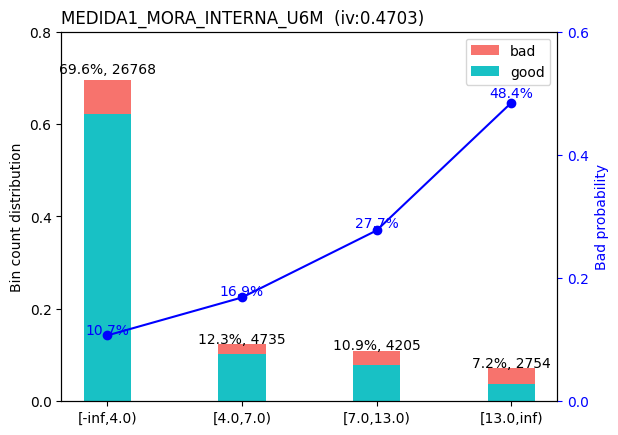

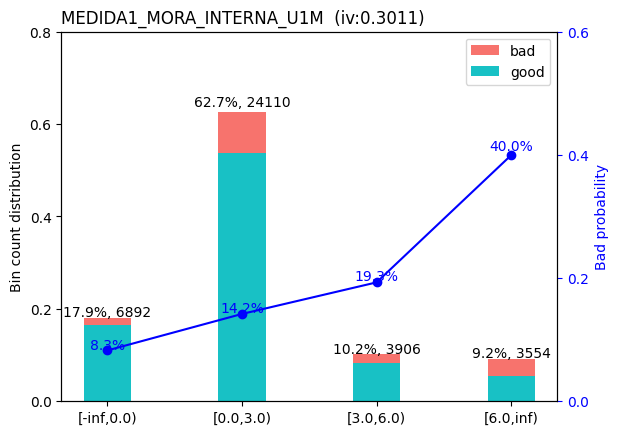

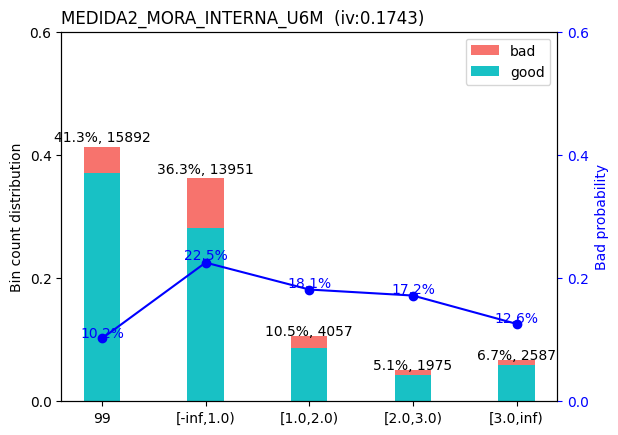

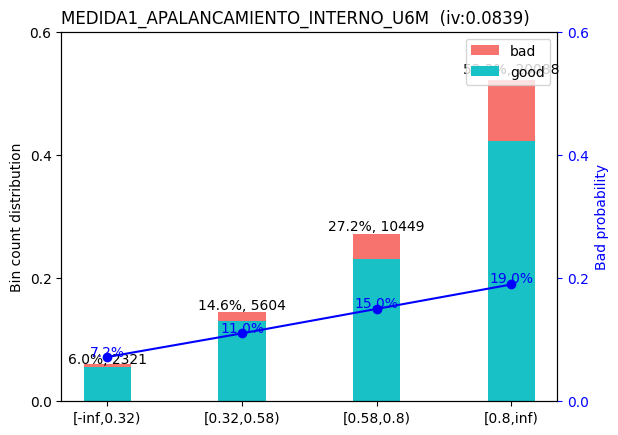

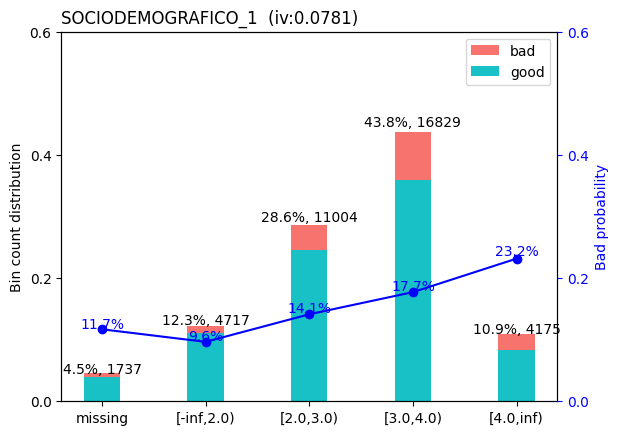

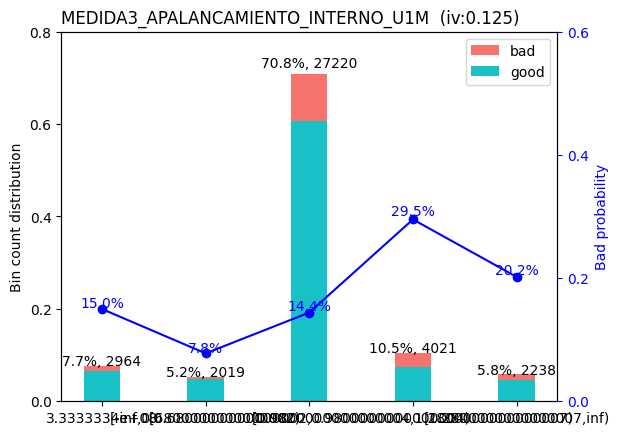

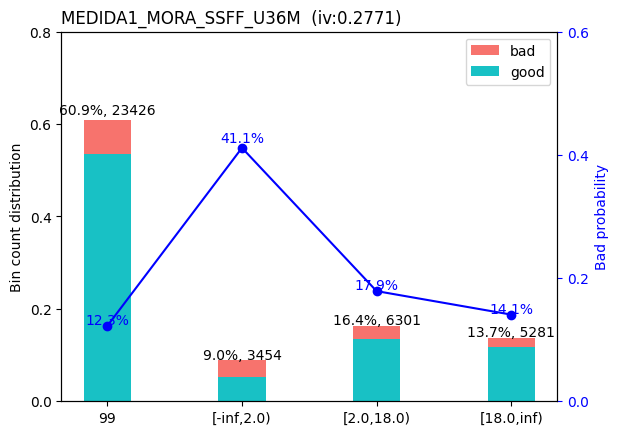

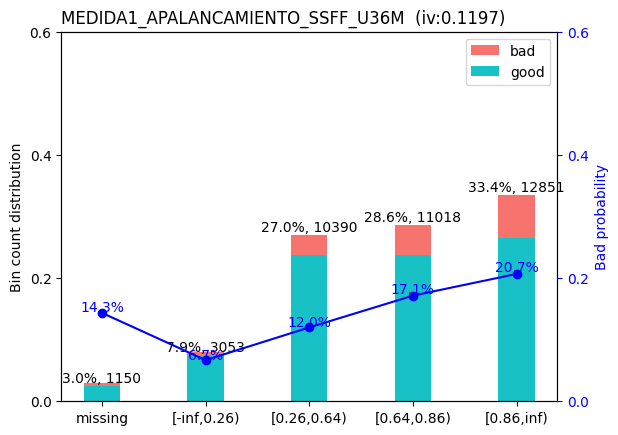

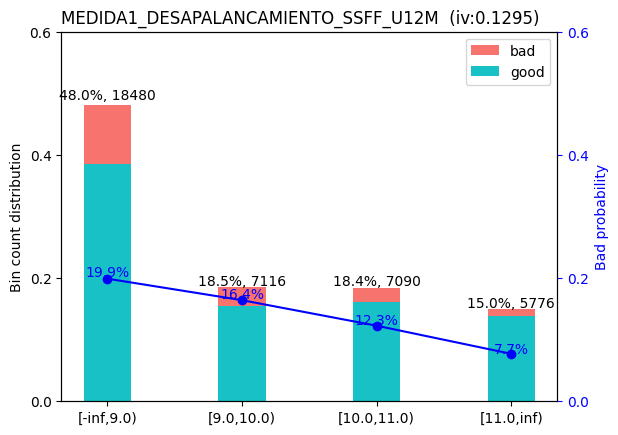

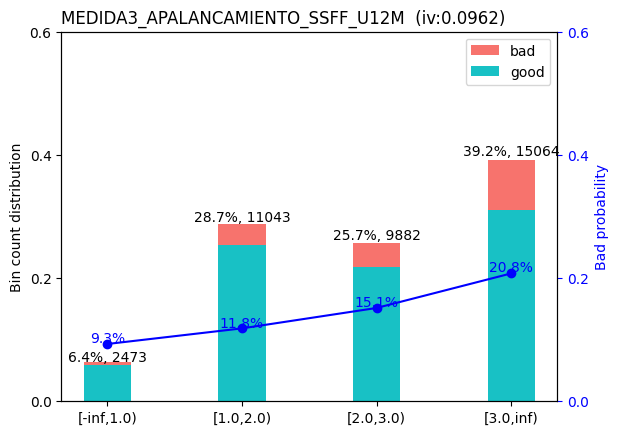

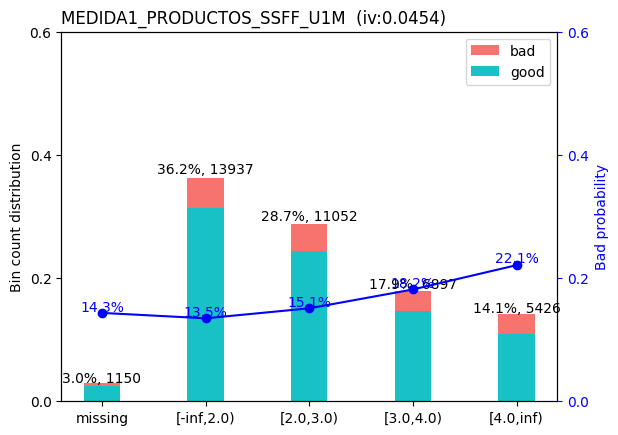

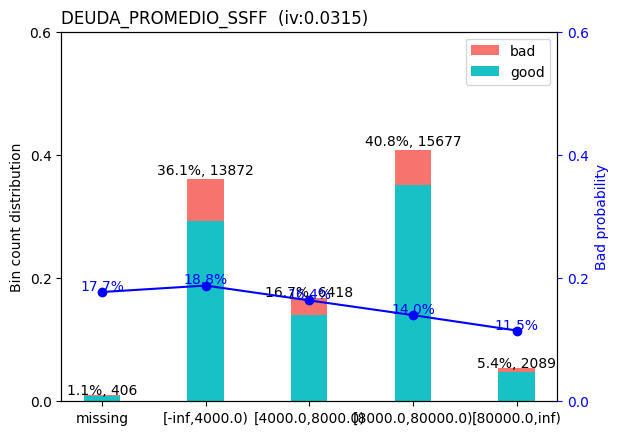

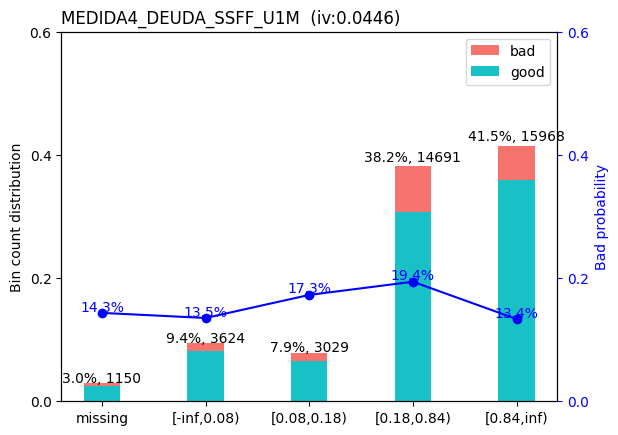

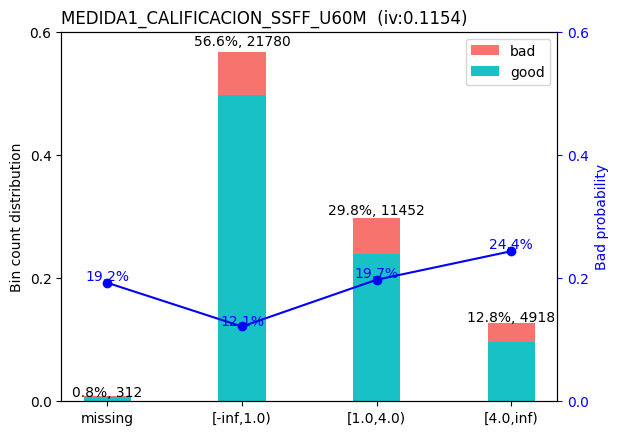

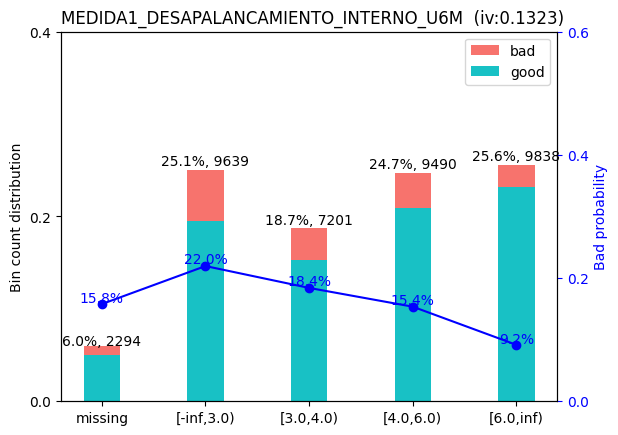

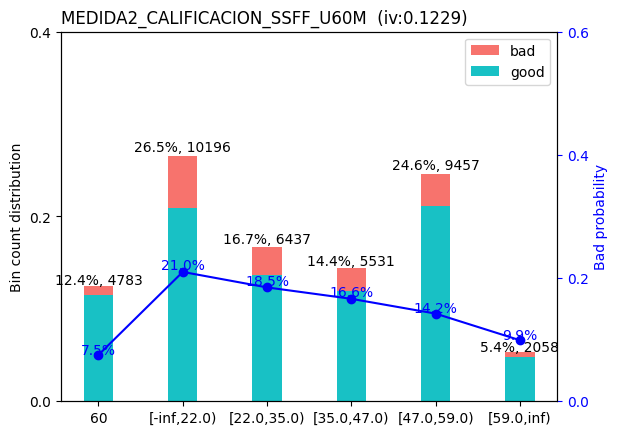

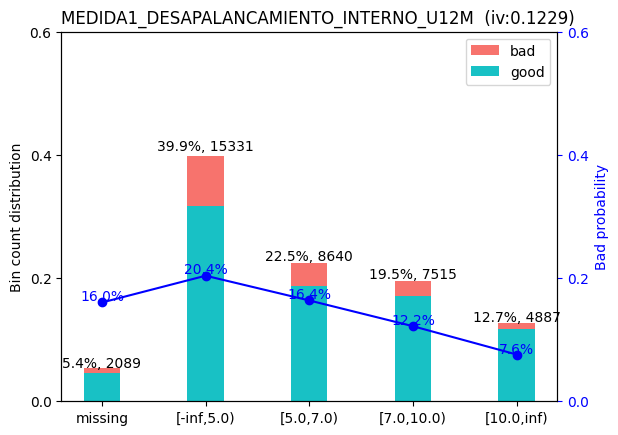

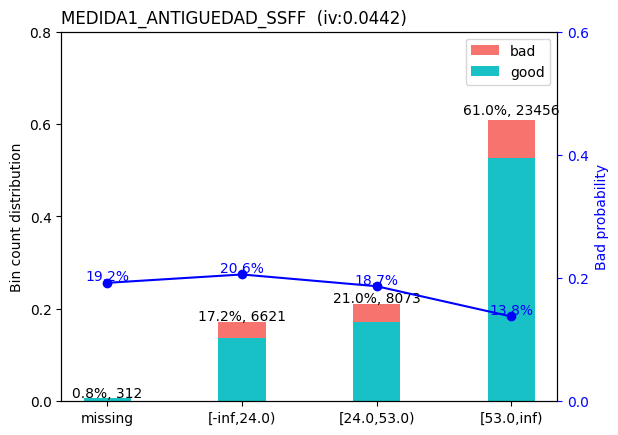

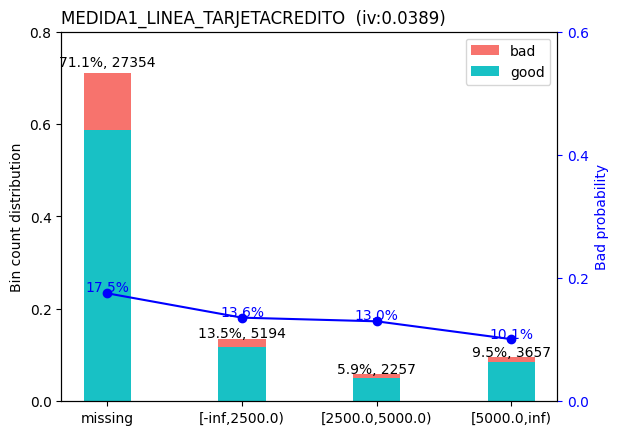

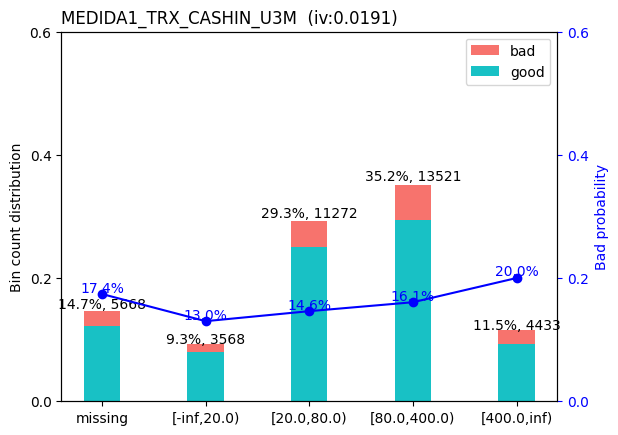

In [85]:
# Revisar gráficamente los bins de las 20 variables finales
for variable in variables_logit_4:
    sc.woebin_plot({variable: bins_woe[variable]})

In [86]:
# ============================================================
# COARSE CLASSING FINAL
# ============================================================

# LINEA DE TARJETA: <5000 | 5000+
bin_linea_ajustado = sc.woebin(
    train_woe_sc,
    y="TARGET",
    x=["MEDIDA1_LINEA_TARJETACREDITO"],
    positive="1",
    breaks_list={
        "MEDIDA1_LINEA_TARJETACREDITO": [5000]
    },
    no_cores=1,
    print_step=0
)

# MORA INTERNA U6M: <1 | 1-3 | 3+ ; 99 sigue separado
bin_mora_ajustado = sc.woebin(
    train_woe_sc,
    y="TARGET",
    x=["MEDIDA2_MORA_INTERNA_U6M"],
    positive="1",
    breaks_list={
        "MEDIDA2_MORA_INTERNA_U6M": [1, 3]
    },
    special_values={
        "MEDIDA2_MORA_INTERNA_U6M": [99]
    },
    no_cores=1,
    print_step=0
)

bins_woe_final = bins_woe.copy()

bins_woe_final["MEDIDA1_LINEA_TARJETACREDITO"] = (
    bin_linea_ajustado["MEDIDA1_LINEA_TARJETACREDITO"]
)

bins_woe_final["MEDIDA2_MORA_INTERNA_U6M"] = (
    bin_mora_ajustado["MEDIDA2_MORA_INTERNA_U6M"]
)

display(
    bins_woe_final["MEDIDA1_LINEA_TARJETACREDITO"][
        ["bin","count","count_distr","badprob","woe","bin_iv","total_iv"]
    ]
)

display(
    bins_woe_final["MEDIDA2_MORA_INTERNA_U6M"][
        ["bin","count","count_distr","badprob","woe","bin_iv","total_iv"]
    ]
)

[INFO] creating woe binning ...


c:\Users\Manolo\AppData\Local\Programs\Python\Python311\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
c:\Users\Manolo\AppData\Local\Programs\Python\Python311\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
c:\Users\Manolo\AppData\Local\Programs\Python\Python311\Lib\site-packages\scorecardpy\woebin.py:38: FutureWarning: Downcasting behavior

[INFO] creating woe binning ...


c:\Users\Manolo\AppData\Local\Programs\Python\Python311\Lib\site-packages\scorecardpy\woebin.py:141: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  ).groupby(['variable', 'rowid', 'bin_chr'], group_keys=False).agg({'bad':sum,'good':sum})\
c:\Users\Manolo\AppData\Local\Programs\Python\Python311\Lib\site-packages\scorecardpy\woebin.py:141: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  ).groupby(['variable', 'rowid', 'bin_chr'], group_keys=False).agg({'bad':sum,'good':sum})\


,bin,count,count_distr,badprob,woe,bin_iv,total_iv
0,missing,27354,0.711195,0.175258,0.108046,0.008610,0.038757
1,"[-inf,5000.0)",7451,0.193724,0.133942,-0.209688,0.007924,0.038757
2,"[5000.0,inf)",3657,0.095081,0.100902,-0.530379,0.022223,0.038757


,bin,count,count_distr,badprob,woe,bin_iv,total_iv
0,99,15892,0.413187,0.101938,-0.519014,0.092851,0.174173
1,"[-inf,1.0)",13951,0.362722,0.225145,0.420929,0.073728,0.174173
2,"[1.0,3.0)",6032,0.156830,0.178216,0.128379,0.002699,0.174173
3,"[3.0,inf)",2587,0.067261,0.125628,-0.283320,0.004895,0.174173


### ¿Qué es coarse classing?

El binning automático propone cortes estadísticos. El **coarse classing** revisa esos bins y decide si algunos deben fusionarse para obtener una estructura más:

- estable;
- parsimoniosa;
- interpretable;
- defendible desde negocio.

No se debe forzar monotonicidad a cualquier costo. Una relación no monotónica puede ser real si se mantiene temporalmente y tiene sentido en los datos.

En este proyecto se aceptaron dos ajustes finales:

1. `MEDIDA1_LINEA_TARJETACREDITO`: se fusionaron bins con riesgo muy parecido y se mantuvo `missing` separado.
2. `MEDIDA2_MORA_INTERNA_U6M`: se fusionaron intervalos intermedios y se conservó `99` como bin especial.

Variables con patrones no monotónicos pero temporalmente estables, como algunos indicadores de apalancamiento/deuda, no se colapsaron solo para "hacer bonita" la curva.

> **Concepto para recordar:** coarse classing es una decisión estadística + temporal + de negocio.


# 10. Modelo candidato de 20 variables

Después del coarse classing se vuelven a transformar TRAIN y VALIDATION porque cambió el WOE de dos variables.

Este modelo de 20 variables **todavía no es el modelo definitivo**. Se utiliza como punto de partida para medir el aporte incremental de cada predictor mediante Drop-One.


In [87]:
# Transformar TRAIN y VALIDATION con los bins finales
train_woe_final = sc.woebin_ply(
    train_woe_sc,
    bins_woe_final,
    print_step=0
)

validation_woe_final = sc.woebin_ply(
    validation_woe_sc,
    bins_woe_final,
    print_step=0
)

variables_woe_finales = [
    variable + "_woe"
    for variable in variables_logit_4
]

X_train_final = sm.add_constant(
    train_woe_final[variables_woe_finales].copy()
)

X_valid_final = sm.add_constant(
    validation_woe_final[variables_woe_finales].copy()
)

y_train_final = train_woe_final["TARGET"]
y_valid = validation_woe_final["TARGET"]

modelo_logit_final = sm.Logit(
    y_train_final,
    X_train_final
)

resultado_logit_final = modelo_logit_final.fit(
    disp=False
)

prob_train_final = resultado_logit_final.predict(
    X_train_final
)

prob_valid = resultado_logit_final.predict(
    X_valid_final
)

tabla_coeficientes_final = pd.DataFrame({
    "variable": resultado_logit_final.params.index,
    "coeficiente": resultado_logit_final.params.values,
    "p_value": resultado_logit_final.pvalues.values
})

tabla_coeficientes_final["significativa_5%"] = (
    tabla_coeficientes_final["p_value"] < 0.05
)

display(tabla_coeficientes_final)

[INFO] converting into woe values ...
[INFO] converting into woe values ...


,variable,coeficiente,p_value,significativa_5%
0,const,-1.684301,0.000000e+00,True
1,MEDIDA1_MORA_INTERNA_U6M_woe,0.719649,1.169291e-124,True
2,MEDIDA1_MORA_INTERNA_U1M_woe,0.407120,2.732080e-29,True
3,MEDIDA2_MORA_INTERNA_U6M_woe,0.404034,1.395767e-16,True
4,MEDIDA1_APALANCAMIENTO_INTERNO_U6M_woe,0.803886,2.466258e-27,True
5,SOCIODEMOGRAFICO_1_woe,0.879348,4.885120e-50,True
6,MEDIDA3_APALANCAMIENTO_INTERNO_U1M_woe,0.767815,6.832790e-52,True
7,MEDIDA1_MORA_SSFF_U36M_woe,0.508907,9.896276e-52,True
8,MEDIDA1_APALANCAMIENTO_SSFF_U36M_woe,0.532841,3.545553e-22,True
9,MEDIDA1_DESAPALANCAMIENTO_SSFF_U12M_woe,0.430451,4.293925e-12,True


### ¿Por qué reestimamos la regresión después del coarse classing?

La regresión no recibe el valor original de la variable; recibe su WOE.

Si fusionamos bins, cambian los valores WOE y, por tanto, también pueden cambiar:

- los coeficientes;
- los p-values;
- las predicciones;
- el Gini.

Por eso el modelo debe volver a estimarse después de modificar los bins.


# 11. Selección final mediante Drop-One

Después de las etapas univariadas, estabilidad, correlación y revisión multivariada se obtuvo un modelo candidato de **20 variables**.

Ahora queremos responder una pregunta distinta:

> **¿Cada variable sigue aportando discriminación cuando las demás ya están dentro del modelo?**

Para ello se aplica **Drop-One secuencial**:

1. se parte del modelo actual;
2. se retira una variable;
3. se vuelve a entrenar sobre TRAIN;
4. se calcula nuevamente el Gini en VALIDATION;
5. se repite el proceso para todas las variables;
6. si se elimina una variable, el Drop-One se recalcula desde cero porque las contribuciones pueden cambiar.

### Regla metodológica utilizada

- TRAIN estima.
- VALIDATION decide.
- **OOT no participa en la eliminación de variables.**

No afirmamos que 18 sea el número universalmente óptimo de variables. Lo que afirmamos es que, bajo este procedimiento y este conjunto de candidatos, **18 representa un punto parsimonioso donde seguir eliminando ya comienza a reducir la discriminación de VALIDATION**.


In [88]:
# ============================================================
# DROP-ONE IMPORTANCE
# ¿CUÁNTO GINI APORTA CADA UNA DE LAS 20 VARIABLES?
# ============================================================

import pandas as pd
import statsmodels.api as sm

from sklearn.metrics import roc_auc_score


# ============================================================
# 1. VARIABLES WOE DEL MODELO FINAL
# ============================================================

variables_woe_dropone = [
    variable + "_woe"
    for variable in variables_logit_4
]


# ============================================================
# 2. MODELO COMPLETO DE REFERENCIA
# ============================================================

X_train_completo = sm.add_constant(
    train_woe_final[
        variables_woe_dropone
    ].copy()
)

X_valid_completo = sm.add_constant(
    validation_woe_final[
        variables_woe_dropone
    ].copy()
)


y_train_dropone = train_woe_final["TARGET"]
y_valid_dropone = validation_woe_final["TARGET"]


modelo_completo = sm.Logit(
    y_train_dropone,
    X_train_completo
).fit(
    disp=False
)


prob_train_completo = modelo_completo.predict(
    X_train_completo
)

prob_valid_completo = modelo_completo.predict(
    X_valid_completo
)


gini_train_completo = (
    2 * roc_auc_score(
        y_train_dropone,
        prob_train_completo
    )
    - 1
)

gini_valid_completo = (
    2 * roc_auc_score(
        y_valid_dropone,
        prob_valid_completo
    )
    - 1
)


print("GINI TRAIN MODELO COMPLETO:", gini_train_completo)
print("GINI VALID MODELO COMPLETO:", gini_valid_completo)


# ============================================================
# 3. DROP-ONE
#
# Quitamos UNA variable cada vez,
# volvemos a entrenar y medimos cuánto cambia el Gini.
# ============================================================

resultados_dropone = []


for variable_original in variables_logit_4:

    variable_woe = variable_original + "_woe"


    # --------------------------------------------------------
    # Todas las variables excepto la que estamos probando
    # --------------------------------------------------------

    variables_sin_una = [
        variable
        for variable in variables_woe_dropone
        if variable != variable_woe
    ]


    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    X_train_drop = sm.add_constant(
        train_woe_final[
            variables_sin_una
        ].copy()
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    X_valid_drop = sm.add_constant(
        validation_woe_final[
            variables_sin_una
        ].copy()
    )


    # --------------------------------------------------------
    # Reentrenamos el modelo SIN esa variable
    # --------------------------------------------------------

    modelo_drop = sm.Logit(
        y_train_dropone,
        X_train_drop
    ).fit(
        disp=False
    )


    # --------------------------------------------------------
    # Probabilidades
    # --------------------------------------------------------

    prob_train_drop = modelo_drop.predict(
        X_train_drop
    )

    prob_valid_drop = modelo_drop.predict(
        X_valid_drop
    )


    # --------------------------------------------------------
    # Gini sin esa variable
    # --------------------------------------------------------

    gini_train_drop = (
        2 * roc_auc_score(
            y_train_dropone,
            prob_train_drop
        )
        - 1
    )

    gini_valid_drop = (
        2 * roc_auc_score(
            y_valid_dropone,
            prob_valid_drop
        )
        - 1
    )


    # --------------------------------------------------------
    # APORTE DE LA VARIABLE
    #
    # Si es positivo:
    # quitarla empeora el modelo → la variable aporta.
    #
    # Si está cerca de cero:
    # aporta muy poco incrementalmente.
    #
    # Si es negativo:
    # el modelo mejora cuando la quitamos.
    # --------------------------------------------------------

    aporte_train = (
        gini_train_completo
        - gini_train_drop
    )

    aporte_valid = (
        gini_valid_completo
        - gini_valid_drop
    )


    resultados_dropone.append({

        "variable": variable_original,

        "GINI_COMPLETO_TRAIN": gini_train_completo,

        "GINI_SIN_VARIABLE_TRAIN": gini_train_drop,

        "APORTE_GINI_TRAIN": aporte_train,

        "GINI_COMPLETO_VALID": gini_valid_completo,

        "GINI_SIN_VARIABLE_VALID": gini_valid_drop,

        "APORTE_GINI_VALID": aporte_valid

    })


# ============================================================
# 4. TABLA FINAL
# ============================================================

tabla_dropone = pd.DataFrame(
    resultados_dropone
)


# Ordenamos desde la variable que MÁS aporta
# hasta la que MENOS aporta
tabla_dropone = (
    tabla_dropone
    .sort_values(
        "APORTE_GINI_VALID",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    tabla_dropone
)

GINI TRAIN MODELO COMPLETO: 0.6000028260388992
GINI VALID MODELO COMPLETO: 0.5803477939169845


,variable,GINI_COMPLETO_TRAIN,GINI_SIN_VARIABLE_TRAIN,APORTE_GINI_TRAIN,GINI_COMPLETO_VALID,GINI_SIN_VARIABLE_VALID,APORTE_GINI_VALID
0,MEDIDA1_MORA_INTERNA_U6M,0.600003,0.581961,0.018042,0.580348,0.554330,0.026017
1,MEDIDA1_LINEA_TARJETACREDITO,0.600003,0.589695,0.010308,0.580348,0.567168,0.013180
2,MEDIDA1_APALANCAMIENTO_INTERNO_U6M,0.600003,0.595771,0.004232,0.580348,0.571032,0.009316
3,MEDIDA1_MORA_SSFF_U36M,0.600003,0.591714,0.008289,0.580348,0.573653,0.006695
4,SOCIODEMOGRAFICO_1,0.600003,0.590471,0.009531,0.580348,0.574270,0.006078
5,MEDIDA1_PRODUCTOS_SSFF_U1M,0.600003,0.595337,0.004666,0.580348,0.575031,0.005317
6,MEDIDA1_MORA_INTERNA_U1M,0.600003,0.594660,0.005342,0.580348,0.575406,0.004942
7,MEDIDA1_CALIFICACION_SSFF_U60M,0.600003,0.593381,0.006622,0.580348,0.576332,0.004016
8,MEDIDA2_MORA_INTERNA_U6M,0.600003,0.597066,0.002937,0.580348,0.576463,0.003885
9,MEDIDA1_TRX_CASHIN_U3M,0.600003,0.597303,0.002700,0.580348,0.576693,0.003655


### ¿Qué mide Drop-One?

Drop-One responde:

> **¿Cuánto cambia el poder discriminante si retiro una variable, vuelvo a entrenar y dejo todas las demás?**

Para una variable \(j\):

$
Aporte_j =Gini_{modelo\ completo}-Gini_{sin\ variable\ j}
$

Interpretación:

- aporte positivo → retirar la variable empeora el modelo;
- aporte cercano a cero → la variable aporta poca información incremental;
- aporte negativo → VALIDATION mejora al retirarla.

Esto **no es lo mismo** que coeficiente, IV o p-value.

- IV = señal univariada.
- Coeficiente = efecto sobre el logit condicionado a otras variables.
- p-value = evidencia estadística del coeficiente.
- Drop-One = pérdida de discriminación al retirar la variable.

> **Importante:** se utiliza VALIDATION para la decisión. OOT no debe guiar esta selección.


In [89]:
# ============================================================
# QUITAMOS LA VARIABLE CON PEOR APORTE DROP-ONE
# ============================================================

variable_a_eliminar = "MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M"


variables_19 = [
    variable
    for variable in variables_logit_4
    if variable != variable_a_eliminar
]


variables_woe_19 = [
    variable + "_woe"
    for variable in variables_19
]


# ============================================================
# TRAIN Y VALIDATION
# ============================================================

X_train_19 = sm.add_constant(
    train_woe_final[
        variables_woe_19
    ].copy()
)

X_valid_19 = sm.add_constant(
    validation_woe_final[
        variables_woe_19
    ].copy()
)


y_train_19 = train_woe_final["TARGET"]
y_valid_19 = validation_woe_final["TARGET"]


# ============================================================
# REENTRENAMOS CON 19 VARIABLES
# ============================================================

modelo_19 = sm.Logit(
    y_train_19,
    X_train_19
).fit(
    disp=False
)


prob_train_19 = modelo_19.predict(
    X_train_19
)

prob_valid_19 = modelo_19.predict(
    X_valid_19
)


gini_train_19 = (
    2 * roc_auc_score(
        y_train_19,
        prob_train_19
    )
    - 1
)

gini_valid_19 = (
    2 * roc_auc_score(
        y_valid_19,
        prob_valid_19
    )
    - 1
)


print("GINI TRAIN 20 variables :", gini_train_completo)
print("GINI TRAIN 19 variables :", gini_train_19)

print()

print("GINI VALID 20 variables :", gini_valid_completo)
print("GINI VALID 19 variables :", gini_valid_19)

GINI TRAIN 20 variables : 0.6000028260388992
GINI TRAIN 19 variables : 0.5992724829170244

GINI VALID 20 variables : 0.5803477939169845
GINI VALID 19 variables : 0.5812028049699776


### Primera eliminación: 20 → 19 variables

Se retiró:

`MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M`

Resultados:

- Gini TRAIN: `0.6000 → 0.5993`
- Gini VALIDATION: `0.5803 → 0.5812`

TRAIN cae ligeramente, pero VALIDATION mejora. Eso sugiere que la variable no estaba ayudando a generalizar y podía aportar complejidad redundante.

Después de eliminarla, **se vuelve a calcular Drop-One**, porque el aporte de las variables restantes puede cambiar.


In [90]:
# ============================================================
# DROP-ONE NUEVAMENTE, AHORA SOBRE EL MODELO DE 19 VARIABLES
# ============================================================

resultados_dropone_19 = []

for variable_original in variables_19:

    variable_woe = variable_original + "_woe"

    # Todas las variables excepto la que estamos probando
    variables_sin_una = [
        variable + "_woe"
        for variable in variables_19
        if variable != variable_original
    ]

    # TRAIN
    X_train_drop = sm.add_constant(
        train_woe_final[variables_sin_una].copy()
    )

    # VALIDATION
    X_valid_drop = sm.add_constant(
        validation_woe_final[variables_sin_una].copy()
    )

    # Reentrenar sin esa variable
    modelo_drop = sm.Logit(
        y_train_19,
        X_train_drop
    ).fit(
        disp=False
    )

    # Predicciones
    prob_train_drop = modelo_drop.predict(X_train_drop)
    prob_valid_drop = modelo_drop.predict(X_valid_drop)

    # Gini
    gini_train_drop = (
        2 * roc_auc_score(
            y_train_19,
            prob_train_drop
        ) - 1
    )

    gini_valid_drop = (
        2 * roc_auc_score(
            y_valid_19,
            prob_valid_drop
        ) - 1
    )

    # Aporte incremental respecto al modelo actual de 19 variables
    aporte_train = (
        gini_train_19 - gini_train_drop
    )

    aporte_valid = (
        gini_valid_19 - gini_valid_drop
    )

    resultados_dropone_19.append({

        "variable": variable_original,

        "GINI_19_TRAIN": gini_train_19,
        "GINI_SIN_VARIABLE_TRAIN": gini_train_drop,
        "APORTE_GINI_TRAIN": aporte_train,

        "GINI_19_VALID": gini_valid_19,
        "GINI_SIN_VARIABLE_VALID": gini_valid_drop,
        "APORTE_GINI_VALID": aporte_valid

    })


tabla_dropone_19 = pd.DataFrame(
    resultados_dropone_19
)


# Ordenamos de mayor aporte a menor aporte
tabla_dropone_19 = (
    tabla_dropone_19
    .sort_values(
        "APORTE_GINI_VALID",
        ascending=False
    )
    .reset_index(drop=True)
)


display(tabla_dropone_19)

,variable,GINI_19_TRAIN,GINI_SIN_VARIABLE_TRAIN,APORTE_GINI_TRAIN,GINI_19_VALID,GINI_SIN_VARIABLE_VALID,APORTE_GINI_VALID
0,MEDIDA1_MORA_INTERNA_U6M,0.599272,0.580943,0.018329,0.581203,0.555410,0.025793
1,MEDIDA1_LINEA_TARJETACREDITO,0.599272,0.588832,0.010441,0.581203,0.568068,0.013135
2,MEDIDA1_APALANCAMIENTO_INTERNO_U6M,0.599272,0.593801,0.005471,0.581203,0.570598,0.010605
3,MEDIDA1_MORA_SSFF_U36M,0.599272,0.590747,0.008525,0.581203,0.574443,0.006760
4,SOCIODEMOGRAFICO_1,0.599272,0.589729,0.009543,0.581203,0.574913,0.006289
5,MEDIDA1_PRODUCTOS_SSFF_U1M,0.599272,0.594710,0.004562,0.581203,0.576076,0.005126
6,MEDIDA1_MORA_INTERNA_U1M,0.599272,0.594098,0.005174,0.581203,0.576232,0.004971
7,MEDIDA1_CALIFICACION_SSFF_U60M,0.599272,0.592492,0.006780,0.581203,0.577352,0.003851
8,MEDIDA2_MORA_INTERNA_U6M,0.599272,0.596467,0.002805,0.581203,0.577432,0.003770
9,MEDIDA1_TRX_CASHIN_U3M,0.599272,0.596533,0.002740,0.581203,0.577737,0.003466


In [91]:
# ============================================================
# PASAR DE 19 A 18 VARIABLES
# ============================================================

variable_a_eliminar_2 = "MEDIDA4_DEUDA_SSFF_U1M"


variables_18 = [
    variable
    for variable in variables_19
    if variable != variable_a_eliminar_2
]


variables_woe_18 = [
    variable + "_woe"
    for variable in variables_18
]


# TRAIN
X_train_18 = sm.add_constant(
    train_woe_final[
        variables_woe_18
    ].copy()
)


# VALIDATION
X_valid_18 = sm.add_constant(
    validation_woe_final[
        variables_woe_18
    ].copy()
)


# Reentrenar
modelo_18 = sm.Logit(
    y_train_19,
    X_train_18
).fit(
    disp=False
)


# Predicciones
prob_train_18 = modelo_18.predict(
    X_train_18
)

prob_valid_18 = modelo_18.predict(
    X_valid_18
)


# Gini
gini_train_18 = (
    2 * roc_auc_score(
        y_train_19,
        prob_train_18
    ) - 1
)

gini_valid_18 = (
    2 * roc_auc_score(
        y_valid_19,
        prob_valid_18
    ) - 1
)


print("GINI TRAIN 19 variables :", gini_train_19)
print("GINI TRAIN 18 variables :", gini_train_18)

print()

print("GINI VALID 19 variables :", gini_valid_19)
print("GINI VALID 18 variables :", gini_valid_18)

GINI TRAIN 19 variables : 0.5992724829170244
GINI TRAIN 18 variables : 0.5990148581155865

GINI VALID 19 variables : 0.5812028049699776
GINI VALID 18 variables : 0.581576060308512


### Segunda eliminación: 19 → 18 variables

En el nuevo modelo la variable con peor aporte incremental fue:

`MEDIDA4_DEUDA_SSFF_U1M`

Resultados:

- Gini TRAIN: `0.5993 → 0.5990`
- Gini VALIDATION: `0.5812 → 0.5816`

Aunque esta variable había mostrado señal univariada real y un patrón temporalmente estable, **no agregaba discriminación incremental útil** una vez consideradas las demás variables.

Este punto es importante:

> una variable puede ser buena por sí sola y, aun así, ser redundante dentro de un modelo multivariado.


In [92]:
# ============================================================
# DROP-ONE SOBRE EL MODELO DE 18 VARIABLES
# ============================================================

resultados_dropone_18 = []

for variable_original in variables_18:

    # Variables restantes al quitar una
    variables_sin_una = [
        variable + "_woe"
        for variable in variables_18
        if variable != variable_original
    ]

    # TRAIN
    X_train_drop = sm.add_constant(
        train_woe_final[variables_sin_una].copy()
    )

    # VALIDATION
    X_valid_drop = sm.add_constant(
        validation_woe_final[variables_sin_una].copy()
    )

    # Reentrenamos sin esa variable
    modelo_drop = sm.Logit(
        y_train_19,
        X_train_drop
    ).fit(disp=False)

    # Predicciones
    prob_train_drop = modelo_drop.predict(X_train_drop)
    prob_valid_drop = modelo_drop.predict(X_valid_drop)

    # Gini
    gini_train_drop = (
        2 * roc_auc_score(
            y_train_19,
            prob_train_drop
        ) - 1
    )

    gini_valid_drop = (
        2 * roc_auc_score(
            y_valid_19,
            prob_valid_drop
        ) - 1
    )

    # Aporte respecto al modelo actual de 18 variables
    resultados_dropone_18.append({

        "variable": variable_original,

        "GINI_18_TRAIN": gini_train_18,

        "GINI_SIN_VARIABLE_TRAIN": gini_train_drop,

        "APORTE_GINI_TRAIN": (
            gini_train_18
            - gini_train_drop
        ),

        "GINI_18_VALID": gini_valid_18,

        "GINI_SIN_VARIABLE_VALID": gini_valid_drop,

        "APORTE_GINI_VALID": (
            gini_valid_18
            - gini_valid_drop
        )

    })


tabla_dropone_18 = pd.DataFrame(
    resultados_dropone_18
)


tabla_dropone_18 = (
    tabla_dropone_18
    .sort_values(
        "APORTE_GINI_VALID",
        ascending=False
    )
    .reset_index(drop=True)
)


display(tabla_dropone_18)

,variable,GINI_18_TRAIN,GINI_SIN_VARIABLE_TRAIN,APORTE_GINI_TRAIN,GINI_18_VALID,GINI_SIN_VARIABLE_VALID,APORTE_GINI_VALID
0,MEDIDA1_MORA_INTERNA_U6M,0.599015,0.580683,0.018331,0.581576,0.555584,0.025992
1,MEDIDA1_LINEA_TARJETACREDITO,0.599015,0.588148,0.010867,0.581576,0.568265,0.013311
2,MEDIDA1_APALANCAMIENTO_INTERNO_U6M,0.599015,0.593551,0.005463,0.581576,0.570900,0.010676
3,MEDIDA1_MORA_SSFF_U36M,0.599015,0.590347,0.008668,0.581576,0.574684,0.006892
4,SOCIODEMOGRAFICO_1,0.599015,0.589572,0.009443,0.581576,0.575156,0.006420
5,MEDIDA1_PRODUCTOS_SSFF_U1M,0.599015,0.592262,0.006753,0.581576,0.575213,0.006363
6,MEDIDA1_MORA_INTERNA_U1M,0.599015,0.593867,0.005148,0.581576,0.576522,0.005054
7,MEDIDA2_MORA_INTERNA_U6M,0.599015,0.596155,0.002859,0.581576,0.577744,0.003832
8,MEDIDA1_CALIFICACION_SSFF_U60M,0.599015,0.592180,0.006834,0.581576,0.577850,0.003726
9,MEDIDA1_TRX_CASHIN_U3M,0.599015,0.596336,0.002679,0.581576,0.577885,0.003691


### ¿Por qué nos detenemos en 18 variables?

El Drop-One se recalculó después de cada eliminación.

Resultados del proceso:

- 20 variables → Gini VALIDATION ≈ `0.5803`
- 19 variables → Gini VALIDATION ≈ `0.5812`
- **18 variables → Gini VALIDATION ≈ `0.5816`**

Las dos eliminaciones mejoraron ligeramente VALIDATION:

1. `MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M`
2. `MEDIDA4_DEUDA_SSFF_U1M`

Al repetir Drop-One sobre las 18 variables restantes, **todas presentaron aporte incremental positivo en VALIDATION**. La variable menos contributiva ya implicaba una pérdida aproximada de Gini de `0.0018` al retirarla.

Por ello se detiene la reducción.
  
> La justificación es que **20 → 18 redujo complejidad sin perder discriminación de validación; una eliminación adicional ya empezaba a deteriorarla**.

Esto mejora:

- parsimonia;
- facilidad de implementación;
- mantenibilidad;
- explicabilidad.

OOT se utiliza posteriormente para comprobar el comportamiento temporal del modelo final, no para escoger estas 18 variables.


# 12. Modelo final de 18 variables

A partir de este punto, los objetos terminados en `_final` corresponden al modelo definitivo.

Las dos variables eliminadas por Drop-One son:

- `MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M`
- `MEDIDA4_DEUDA_SSFF_U1M`


In [93]:
# ============================================================
# MODELO FINAL — 18 VARIABLES
# ============================================================

# Estas son las 18 variables que quedaron después del Drop-One.
# Partimos de las 20 variables anteriores y eliminamos las 2
# cuyo aporte incremental en VALIDATION era negativo.

variables_finales_18 = [
    variable
    for variable in variables_logit_4
    if variable not in [
        "MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M",
        "MEDIDA4_DEUDA_SSFF_U1M"
    ]
]


# Creamos los nombres de las columnas WOE correspondientes.
variables_woe_finales_18 = [
    variable + "_woe"
    for variable in variables_finales_18
]


print("Número de variables finales:", len(variables_finales_18))

print("\nVariables finales:")

for variable in variables_finales_18:
    print(variable)


# ============================================================
# PREPARAR TRAIN Y VALIDATION
# ============================================================

X_train_final = sm.add_constant(
    train_woe_final[
        variables_woe_finales_18
    ].copy()
)

X_valid_final = sm.add_constant(
    validation_woe_final[
        variables_woe_finales_18
    ].copy()
)


y_train_final = train_woe_final["TARGET"]
y_valid = validation_woe_final["TARGET"]


# ============================================================
# ENTRENAR MODELO FINAL
# ============================================================

modelo_final = sm.Logit(
    y_train_final,
    X_train_final
)

resultado_final = modelo_final.fit(
    disp=False
)


# ============================================================
# PREDICCIONES TRAIN Y VALIDATION
# ============================================================

prob_train_final = resultado_final.predict(
    X_train_final
)

prob_valid = resultado_final.predict(
    X_valid_final
)


# ============================================================
# TABLA DE COEFICIENTES Y P-VALUES
# ============================================================

tabla_coeficientes_final = pd.DataFrame({

    "variable": resultado_final.params.index,

    "coeficiente": resultado_final.params.values,

    "p_value": resultado_final.pvalues.values

})


tabla_coeficientes_final["significativa_5%"] = (
    tabla_coeficientes_final["p_value"] < 0.05
)


display(tabla_coeficientes_final)

Número de variables finales: 18

Variables finales:
MEDIDA1_MORA_INTERNA_U6M
MEDIDA1_MORA_INTERNA_U1M
MEDIDA2_MORA_INTERNA_U6M
MEDIDA1_APALANCAMIENTO_INTERNO_U6M
SOCIODEMOGRAFICO_1
MEDIDA3_APALANCAMIENTO_INTERNO_U1M
MEDIDA1_MORA_SSFF_U36M
MEDIDA1_APALANCAMIENTO_SSFF_U36M
MEDIDA1_DESAPALANCAMIENTO_SSFF_U12M
MEDIDA3_APALANCAMIENTO_SSFF_U12M
MEDIDA1_PRODUCTOS_SSFF_U1M
DEUDA_PROMEDIO_SSFF
MEDIDA1_CALIFICACION_SSFF_U60M
MEDIDA2_CALIFICACION_SSFF_U60M
MEDIDA1_DESAPALANCAMIENTO_INTERNO_U12M
MEDIDA1_ANTIGUEDAD_SSFF
MEDIDA1_LINEA_TARJETACREDITO
MEDIDA1_TRX_CASHIN_U3M


,variable,coeficiente,p_value,significativa_5%
0,const,-1.685968,0.000000e+00,True
1,MEDIDA1_MORA_INTERNA_U6M_woe,0.721606,2.225210e-125,True
2,MEDIDA1_MORA_INTERNA_U1M_woe,0.396254,5.821333e-28,True
3,MEDIDA2_MORA_INTERNA_U6M_woe,0.400583,2.293978e-16,True
4,MEDIDA1_APALANCAMIENTO_INTERNO_U6M_woe,0.915560,4.035908e-37,True
5,SOCIODEMOGRAFICO_1_woe,0.879287,4.458487e-50,True
6,MEDIDA3_APALANCAMIENTO_INTERNO_U1M_woe,0.799309,2.390823e-56,True
7,MEDIDA1_MORA_SSFF_U36M_woe,0.518686,5.998399e-54,True
8,MEDIDA1_APALANCAMIENTO_SSFF_U36M_woe,0.546743,3.199915e-23,True
9,MEDIDA1_DESAPALANCAMIENTO_SSFF_U12M_woe,0.405430,4.072636e-11,True


### Lectura de los coeficientes

Como trabajamos con WOE donde valores más positivos representan mayor riesgo, esperamos que los coeficientes del modelo sean coherentes con esa construcción.

La regresión final debe revisarse en tres dimensiones:

1. **signo del coeficiente**;
2. **significancia estadística**;
3. **coherencia de negocio**.

No basta con que una variable "mejore una métrica"; también debe poder explicarse y utilizarse de manera consistente.


In [94]:

# ============================================================
# TRANSFORMAR OOT CON LOS BINS APRENDIDOS EN TRAIN
# Y GENERAR PREDICCIONES DEL MODELO FINAL DE 18 VARIABLES
# ============================================================

oot_woe_sc = oot[
    variables_post_univariado + ["TARGET"]
].copy()

oot_woe_sc["TARGET"] = (
    oot_woe_sc["TARGET"].astype("int64")
)

# IMPORTANTE:
# No se vuelven a aprender bins en OOT.
# Se aplican exactamente los bins construidos con TRAIN.
oot_woe_final = sc.woebin_ply(
    oot_woe_sc,
    bins_woe_final,
    print_step=0
)

X_oot_final = sm.add_constant(
    oot_woe_final[
        variables_woe_finales_18
    ].copy()
)

y_oot = oot_woe_final["TARGET"]

prob_oot = resultado_final.predict(
    X_oot_final
)


[INFO] converting into woe values ...


In [95]:
# ============================================================
# PERFORMANCE FINAL: TRAIN / VALIDATION / OOT
# MODELO FINAL DE 18 VARIABLES
# ============================================================

from sklearn.metrics import roc_auc_score, roc_curve


# ------------------------------------------------------------
# Función para calcular KS
# ------------------------------------------------------------

def calcular_ks(y_real, probabilidades):

    fpr, tpr, thresholds = roc_curve(
        y_real,
        probabilidades
    )

    ks = max(tpr - fpr)

    return ks


# ============================================================
# AUC
# ============================================================

auc_train_final = roc_auc_score(
    y_train_final,
    prob_train_final
)

auc_valid_final = roc_auc_score(
    y_valid,
    prob_valid
)

auc_oot_final = roc_auc_score(
    y_oot,
    prob_oot
)


# ============================================================
# GINI
# ============================================================

gini_train_final = 2 * auc_train_final - 1
gini_valid_final = 2 * auc_valid_final - 1
gini_oot_final = 2 * auc_oot_final - 1


# ============================================================
# KS
# ============================================================

ks_train_final = calcular_ks(
    y_train_final,
    prob_train_final
)

ks_valid_final = calcular_ks(
    y_valid,
    prob_valid
)

ks_oot_final = calcular_ks(
    y_oot,
    prob_oot
)


# ============================================================
# TABLA FINAL
# ============================================================

performance_final = pd.DataFrame({

    "muestra": [
        "TRAIN",
        "VALIDATION",
        "OOT"
    ],

    "AUC": [
        auc_train_final,
        auc_valid_final,
        auc_oot_final
    ],

    "GINI": [
        gini_train_final,
        gini_valid_final,
        gini_oot_final
    ],

    "KS": [
        ks_train_final,
        ks_valid_final,
        ks_oot_final
    ],

    "bad_rate": [
        y_train_final.mean(),
        y_valid.mean(),
        y_oot.mean()
    ]

})


display(performance_final)

,muestra,AUC,GINI,KS,bad_rate
0,TRAIN,0.799507,0.599015,0.445362,0.160184
1,VALIDATION,0.790788,0.581576,0.432179,0.149485
2,OOT,0.796370,0.592741,0.449504,0.141305


### ¿Cómo evaluamos la capacidad discriminante?

#### AUC

El AUC puede interpretarse como la probabilidad de que el modelo asigne mayor riesgo a un malo que a un bueno seleccionados al azar.

- `0.50` → sin discriminación.
- `1.00` → discriminación perfecta.

#### Gini

En credit scoring es muy común:

$
Gini = 2\times AUC - 1
$

Por tanto, AUC y Gini expresan esencialmente la misma capacidad de ranking en escalas distintas.

#### KS

El estadístico KS mide la máxima distancia entre las distribuciones acumuladas de buenos y malos:

$
KS=\max(TPR-FPR)
$

Cuanto mayor es la separación, mayor capacidad tiene el modelo para diferenciar ambos grupos.

### Resultado final

| Muestra | AUC | Gini | KS |
|---|---:|---:|---:|
| TRAIN | ≈ 0.7995 | ≈ 0.5990 | ≈ 0.4454 |
| VALIDATION | ≈ 0.7908 | ≈ 0.5816 | ≈ 0.4322 |
| OOT | ≈ 0.7964 | ≈ 0.5927 | ≈ 0.4495 |

Lo importante no es solamente el nivel de Gini, sino que **TRAIN, VALIDATION y OOT presentan valores cercanos**, señal de un ranking relativamente estable en el tiempo.

> **Nota:** OOT se reporta como validación temporal post-hoc por la historia exploratoria del proyecto.


# 13. Deciles y lift

Las métricas globales resumen el modelo, pero negocio también necesita saber **dónde están concentrados los malos**.


In [96]:
# Deciles de riesgo OOT
tabla_deciles_oot = pd.DataFrame({
    "TARGET": y_oot.values,
    "PD_MODELO": prob_oot.values
})

tabla_deciles_oot["DECIL"] = pd.qcut(
    tabla_deciles_oot["PD_MODELO"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

resumen_deciles_oot = (
    tabla_deciles_oot
    .groupby("DECIL")
    .agg(
        clientes=("TARGET", "size"),
        malos=("TARGET", "sum"),
        bad_rate=("TARGET", "mean"),
        pd_promedio=("PD_MODELO", "mean"),
        pd_min=("PD_MODELO", "min"),
        pd_max=("PD_MODELO", "max")
    )
    .reset_index()
)

resumen_deciles_oot["bad_rate_%"] = (
    resumen_deciles_oot["bad_rate"] * 100
)

resumen_deciles_oot["pd_promedio_%"] = (
    resumen_deciles_oot["pd_promedio"] * 100
)

resumen_deciles_oot["lift"] = (
    resumen_deciles_oot["bad_rate"]
    / y_oot.mean()
)

display(resumen_deciles_oot)

,DECIL,clientes,malos,bad_rate,pd_promedio,pd_min,pd_max,bad_rate_%,pd_promedio_%,lift
0,1,1096,24,0.021898,0.014082,0.000391,0.024353,2.189781,1.408249,0.154968
1,2,1095,30,0.027397,0.033528,0.024354,0.042859,2.739726,3.352758,0.193887
2,3,1096,50,0.045620,0.052916,0.042878,0.063286,4.562044,5.291571,0.322850
3,4,1095,65,0.059361,0.074228,0.063304,0.086163,5.936073,7.422809,0.420088
4,5,1096,69,0.062956,0.098292,0.086201,0.111428,6.295620,9.829162,0.445533
5,6,1095,105,0.095890,0.127694,0.111448,0.145150,9.589041,12.769362,0.678604
6,7,1095,151,0.137900,0.163564,0.145204,0.183666,13.789954,16.356431,0.975898
7,8,1096,198,0.180657,0.210792,0.183707,0.243609,18.065693,21.079196,1.278486
8,9,1095,292,0.266667,0.302810,0.243703,0.391455,26.666667,30.281017,1.887166
9,10,1096,564,0.514599,0.575872,0.391888,0.975502,51.459854,57.587238,3.641749


### ¿Qué son los deciles de riesgo?

Ordenamos los clientes según la PD estimada y dividimos la muestra OOT en 10 grupos de tamaño aproximadamente similar.

En este notebook:

- deciles bajos → menor PD;
- deciles altos → mayor PD.

El objetivo es comprobar que la tasa de malos aumente progresivamente a medida que aumenta el riesgo estimado.

### Lift

Para un grupo:

$
Lift=
\frac{BadRate_{grupo}}{BadRate_{población}}
$

Un lift de `3.64` significa que la tasa de malos del grupo es aproximadamente **3.64 veces** la tasa promedio de OOT.

### Resultado observado

La tasa de malos aumenta aproximadamente desde:

- **2.2%** en el decil de menor riesgo;
- hasta **51.5%** en el decil de mayor riesgo.

Además:

- el 10% de mayor riesgo concentra alrededor de **36% de todos los malos**;
- el 20% de mayor riesgo concentra alrededor de **55%**.

Esto confirma que el modelo no solo tiene buen Gini: también concentra eventos donde el ranking dice que debería concentrarlos.

> **Nota metodológica:** estos deciles se calculan sobre OOT con fines descriptivos. Para bandas operativas de producción sería preferible fijar cortes con TRAIN/VALIDATION y aplicarlos después sin recalcularlos.


# 14. Calibración

Discriminar correctamente y estimar correctamente la probabilidad absoluta son problemas relacionados, pero diferentes.


In [97]:
# ============================================================
# CALIBRACIÓN DEL MODELO FINAL DE 18 VARIABLES
# ============================================================

from sklearn.metrics import brier_score_loss


# ============================================================
# 1. BRIER SCORE
# ============================================================

brier_train_final = brier_score_loss(
    y_train_final,
    prob_train_final
)

brier_valid_final = brier_score_loss(
    y_valid,
    prob_valid
)

brier_oot_final = brier_score_loss(
    y_oot,
    prob_oot
)


print("BRIER TRAIN :", brier_train_final)
print("BRIER VALID :", brier_valid_final)
print("BRIER OOT   :", brier_oot_final)


# ============================================================
# 2. COMPARAR TASA REAL VS PD PROMEDIO
# ============================================================

tabla_calibracion_general = pd.DataFrame({

    "Muestra": [
        "TRAIN",
        "VALIDATION",
        "OOT"
    ],

    "Bad_Rate_Real": [
        y_train_final.mean(),
        y_valid.mean(),
        y_oot.mean()
    ],

    "PD_Promedio": [
        prob_train_final.mean(),
        prob_valid.mean(),
        prob_oot.mean()
    ]

})


tabla_calibracion_general["Diferencia"] = (
    tabla_calibracion_general["PD_Promedio"]
    - tabla_calibracion_general["Bad_Rate_Real"]
)


tabla_calibracion_general["Bad_Rate_Real_%"] = (
    tabla_calibracion_general["Bad_Rate_Real"] * 100
)

tabla_calibracion_general["PD_Promedio_%"] = (
    tabla_calibracion_general["PD_Promedio"] * 100
)

tabla_calibracion_general["Diferencia_pp"] = (
    tabla_calibracion_general["Diferencia"] * 100
)


display(tabla_calibracion_general)

BRIER TRAIN : 0.10663728496444463
BRIER VALID : 0.1039301585151446
BRIER OOT   : 0.09909408067955644


,Muestra,Bad_Rate_Real,PD_Promedio,Diferencia,Bad_Rate_Real_%,PD_Promedio_%,Diferencia_pp
0,TRAIN,0.160184,0.160184,-2.775558e-17,16.018408,16.018408,-2.775558e-15
1,VALIDATION,0.149485,0.158753,9.267484e-03,14.948502,15.875251,9.267484e-01
2,OOT,0.141305,0.165389,2.408387e-02,14.130534,16.538921,2.408387e+00


In [98]:
# ============================================================
# 3. INTERCEPTO Y PENDIENTE DE CALIBRACIÓN
# ============================================================

import numpy as np


def evaluar_calibracion(y_real, prob_predicha):

    # Evitamos probabilidades exactamente 0 o 1
    prob_predicha = np.clip(
        prob_predicha,
        1e-6,
        1 - 1e-6
    )

    # Convertimos la probabilidad a log-odds
    logit_predicho = np.log(
        prob_predicha / (1 - prob_predicha)
    )

    X_calibracion = sm.add_constant(
        logit_predicho
    )

    modelo_calibracion = sm.Logit(
        y_real,
        X_calibracion
    ).fit(disp=False)

    intercepto = modelo_calibracion.params.iloc[0]
    pendiente = modelo_calibracion.params.iloc[1]

    return intercepto, pendiente


intercept_train, slope_train = evaluar_calibracion(
    y_train_final,
    prob_train_final
)

intercept_valid, slope_valid = evaluar_calibracion(
    y_valid,
    prob_valid
)

intercept_oot, slope_oot = evaluar_calibracion(
    y_oot,
    prob_oot
)


tabla_intercepto_pendiente = pd.DataFrame({

    "Muestra": [
        "TRAIN",
        "VALIDATION",
        "OOT"
    ],

    "Intercepto_Calibracion": [
        intercept_train,
        intercept_valid,
        intercept_oot
    ],

    "Pendiente_Calibracion": [
        slope_train,
        slope_valid,
        slope_oot
    ]

})


display(tabla_intercepto_pendiente)

,Muestra,Intercepto_Calibracion,Pendiente_Calibracion
0,TRAIN,2.488059e-16,1.000000
1,VALIDATION,-1.239207e-01,0.973034
2,OOT,-2.656048e-01,0.972816


### Discriminación vs calibración

**Discriminación**

Pregunta:

> ¿El modelo ordena correctamente quién es más riesgoso?

Se estudia con AUC, Gini, KS, deciles y lift.

**Calibración**

Pregunta:

> ¿La PD pronosticada coincide con la frecuencia de incumplimiento observada?

### Brier Score

$
Brier =
\frac{1}{N}\sum_{i=1}^{N}(p_i-y_i)^2
$

Valores menores indican, en general, menor error probabilístico.

### Intercepto y pendiente de calibración

Idealmente:

$ intercepto \approx 0 \qquad pendiente \approx 1\ $

- intercepto negativo puede indicar sobreestimación general del riesgo;
- pendiente muy distinta de 1 puede sugerir que las diferencias entre riesgos están demasiado comprimidas o exageradas.

### Nuestro resultado

TRAIN reproduce su tasa de malos, como es esperable al haberse estimado allí.

En VALIDATION:

- Bad Rate ≈ `14.95%`
- PD promedio ≈ `15.88%`
- sobreestimación ≈ `+0.93 pp`

En OOT:

- Bad Rate ≈ `14.13%`
- PD promedio ≈ `16.54%`
- sobreestimación ≈ `+2.41 pp`

La pendiente en VALIDATION y OOT es aproximadamente `0.97`, cercana a 1. Por tanto, el ranking relativo permanece razonablemente estable, pero el nivel general de PD se desplaza.

La tasa de malos también cae con el tiempo:

$
16.02\% \rightarrow 14.95\% \rightarrow 14.13\%
$

Esto es consistente con un cambio en la tasa base.

> **Decisión:** no recalibramos utilizando OOT, porque adaptar el modelo a la muestra utilizada para evaluación contaminaría esa evaluación. En producción, una recalibración debería diseñarse con una muestra específica para ese propósito.


# 15. Backtesting estadístico de PD por bandas

La calibración general compara:

- PD promedio del modelo;
- Bad Rate observado.

Sin embargo, una única comparación global puede ocultar problemas en determinados niveles de riesgo.

Por eso dividimos VALIDATION en **bandas de PD fáciles de comunicar** y comparamos, dentro de cada banda:

- cantidad de clientes;
- PD promedio;
- defaults esperados;
- defaults observados;
- Bad Rate real;
- diferencia entre PD y Bad Rate.

La primera prueba que utilizaremos es un **backtesting bajo independencia de defaults**. Esta prueba sirve como línea base.

Después podremos complementar el análisis con un enfoque tipo **Vasicek**, que incorpora correlación entre defaults. Para Vasicek necesitamos documentar una hipótesis de correlación `rho`; no se debe elegir ese parámetro arbitrariamente.


In [99]:
# ============================================================
# BACKTESTING DE PD POR BANDAS — VALIDATION
# ============================================================

from scipy.stats import norm

# Bandas fáciles de interpretar para negocio.
# Se aprueban aquí como herramienta de validación, NO como política final.
bins_pd = [
    0.00,
    0.05,
    0.10,
    0.15,
    0.20,
    0.30,
    0.40,
    1.00
]

labels_pd = [
    "0%-5%",
    "5%-10%",
    "10%-15%",
    "15%-20%",
    "20%-30%",
    "30%-40%",
    "40%+"
]


# Construimos un dataframe limpio para evitar problemas de índices.
backtest_valid = pd.DataFrame({
    "TARGET": np.asarray(y_valid).astype(int),
    "PD": np.asarray(prob_valid).astype(float)
})


backtest_valid["BANDA_PD"] = pd.cut(
    backtest_valid["PD"],
    bins=bins_pd,
    labels=labels_pd,
    include_lowest=True,
    right=False
)


# ============================================================
# FUNCIÓN DE BACKTESTING
#
# Bajo independencia:
# E(defaults) = suma(PD_i)
# Var(defaults) = suma(PD_i * (1 - PD_i))
#
# Esto respeta que cada cliente puede tener una PD diferente.
# ============================================================

def backtesting_pd_independiente(dataframe, confianza=0.95):

    resultados = []

    z_critico = norm.ppf(
        0.5 + confianza / 2
    )

    for banda, grupo in dataframe.groupby(
        "BANDA_PD",
        observed=True
    ):

        n = len(grupo)

        if n == 0:
            continue

        observados = int(
            grupo["TARGET"].sum()
        )

        probabilidades = grupo["PD"].values

        esperados = probabilidades.sum()

        varianza = (
            probabilidades
            * (1 - probabilidades)
        ).sum()

        desviacion = np.sqrt(varianza)

        # Evitamos división entre cero
        if desviacion > 0:

            z = (
                observados - esperados
            ) / desviacion

            p_value = 2 * (
                1 - norm.cdf(abs(z))
            )

        else:

            z = np.nan
            p_value = np.nan


        pd_promedio = probabilidades.mean()

        bad_rate_real = (
            observados / n
        )


        # Banda estadística aproximada de defaults esperados
        limite_inferior_defaults = max(
            0,
            esperados - z_critico * desviacion
        )

        limite_superior_defaults = min(
            n,
            esperados + z_critico * desviacion
        )


        limite_inferior_tasa = (
            limite_inferior_defaults / n
        )

        limite_superior_tasa = (
            limite_superior_defaults / n
        )


        resultados.append({

            "Banda_PD": str(banda),

            "Clientes": n,

            "Defaults_Observados": observados,

            "Defaults_Esperados": esperados,

            "PD_Promedio_%": pd_promedio * 100,

            "Bad_Rate_Real_%": bad_rate_real * 100,

            "Gap_pp": (
                pd_promedio - bad_rate_real
            ) * 100,

            "Limite_Inferior_%": (
                limite_inferior_tasa * 100
            ),

            "Limite_Superior_%": (
                limite_superior_tasa * 100
            ),

            "Z": z,

            "p_value": p_value,

            "Resultado_5%": (
                "Sin diferencia estadísticamente significativa"
                if pd.notna(p_value) and p_value >= 0.05
                else "Diferencia estadísticamente significativa"
            )

        })


    return pd.DataFrame(resultados)


tabla_backtesting_valid = backtesting_pd_independiente(
    backtest_valid,
    confianza=0.95
)


display(
    tabla_backtesting_valid.round(4)
)


,Banda_PD,Clientes,Defaults_Observados,Defaults_Esperados,PD_Promedio_%,Bad_Rate_Real_%,Gap_pp,Limite_Inferior_%,Limite_Superior_%,Z,p_value,Resultado_5%
0,0%-5%,2655,78,72.3895,2.7265,2.9379,-0.2113,2.1091,3.3439,0.6709,0.5023,Sin diferencia estadísticamente significativa
1,5%-10%,2343,154,173.2514,7.3944,6.5728,0.8217,6.3365,8.4524,-1.5222,0.1280,Sin diferencia estadísticamente significativa
2,10%-15%,1718,197,212.6959,12.3804,11.4668,0.9136,10.8245,13.9364,-1.1509,0.2498,Sin diferencia estadísticamente significativa
3,15%-20%,1175,204,203.9097,17.3540,17.3617,-0.0077,15.1902,19.5178,0.0070,0.9944,Sin diferencia estadísticamente significativa
4,20%-30%,1193,247,288.0866,24.1481,20.7041,3.4440,21.7250,26.5711,-2.7858,0.0053,Diferencia estadísticamente significativa
5,30%-40%,581,198,200.7211,34.5475,34.0792,0.4684,30.6881,38.4070,-0.2378,0.8120,Sin diferencia estadísticamente significativa
6,40%+,918,504,529.0236,57.6278,54.9020,2.7259,54.5589,60.6968,-1.7409,0.0817,Sin diferencia estadísticamente significativa


### Resultado del backtesting por bandas

El backtesting bajo independencia muestra una calibración razonable en la mayor parte del rango de riesgo.

Resumen:

| Banda PD | PD promedio | Bad Rate observado | Gap | Resultado |
|---|---:|---:|---:|---|
| 0%-5% | 2.73% | 2.94% | -0.21 pp | Sin diferencia estadísticamente significativa |
| 5%-10% | 7.39% | 6.57% | +0.82 pp | Sin diferencia estadísticamente significativa |
| 10%-15% | 12.38% | 11.47% | +0.91 pp | Sin diferencia estadísticamente significativa |
| 15%-20% | 17.35% | 17.36% | -0.01 pp | Sin diferencia estadísticamente significativa |
| 20%-30% | 24.15% | 20.70% | +3.44 pp | Diferencia estadísticamente significativa |
| 30%-40% | 34.55% | 34.08% | +0.47 pp | Sin diferencia estadísticamente significativa |
| 40%+ | 57.63% | 54.90% | +2.73 pp | Sin diferencia estadísticamente significativa |

Seis de las siete bandas no presentan diferencia estadísticamente significativa bajo el supuesto de independencia.

La banda `20%-30%` presenta la mayor desviación:

- PD promedio = **24.15%**
- Bad Rate observado = **20.70%**
- Gap = **+3.44 puntos porcentuales**
- p-value ≈ **0.0053**

El modelo sobreestima ligeramente el riesgo observado en este segmento y la diferencia es estadísticamente significativa bajo el supuesto de independencia.

El resultado no invalida el modelo completo, pero identifica una zona que debe ser monitoreada y motiva un análisis complementario que permita relajar el supuesto de independencia entre defaults.


## 15.1 Backtesting complementario mediante Vasicek

El test anterior supone que los defaults son independientes.

En crédito, esta hipótesis puede ser restrictiva porque los clientes pueden verse afectados simultáneamente por factores económicos comunes.

Por ello se realiza un análisis complementario mediante un modelo de un factor de Vasicek.

El parámetro `rho` representa dependencia sistemática entre defaults:

- `rho` pequeño: comportamiento cercano a independencia;
- `rho` mayor: mayor influencia de factores comunes.

No se selecciona un único valor de `rho` de forma arbitraria. Se realiza un análisis de sensibilidad con:

- `rho = 0.5%`
- `rho = 1%`
- `rho = 2%`
- `rho = 3%`

El objetivo no es afirmar que el modelo “cumple Basilea”, sino comprobar si la conclusión de calibración cambia al permitir niveles moderados de dependencia entre defaults.


In [100]:
# ============================================================
# BACKTESTING VASICEK — ANÁLISIS DE SENSIBILIDAD
# ============================================================

from scipy.stats import norm


def limites_vasicek(pd_promedio, rho, confianza=0.95):

    # Evitamos 0 y 1 porque norm.ppf no está definido allí
    p = np.clip(pd_promedio, 1e-8, 1 - 1e-8)

    z = norm.ppf(0.5 + confianza / 2)

    punto_corte = norm.ppf(p)

    limite_inferior = norm.cdf(
        (punto_corte - np.sqrt(rho) * z)
        / np.sqrt(1 - rho)
    )

    limite_superior = norm.cdf(
        (punto_corte + np.sqrt(rho) * z)
        / np.sqrt(1 - rho)
    )

    return limite_inferior, limite_superior


# Analizamos varios niveles moderados de correlación
rhos = [0.005, 0.01, 0.02, 0.03]

resultados_vasicek = []


for _, fila in tabla_backtesting_valid.iterrows():

    pd_promedio = fila["PD_Promedio_%"] / 100
    bad_rate_real = fila["Bad_Rate_Real_%"] / 100

    for rho in rhos:

        limite_inferior, limite_superior = limites_vasicek(
            pd_promedio=pd_promedio,
            rho=rho,
            confianza=0.95
        )

        resultados_vasicek.append({

            "Banda_PD": fila["Banda_PD"],
            "PD_Promedio_%": fila["PD_Promedio_%"],
            "Bad_Rate_Real_%": fila["Bad_Rate_Real_%"],
            "Rho_%": rho * 100,
            "Limite_Inferior_%": limite_inferior * 100,
            "Limite_Superior_%": limite_superior * 100,

            "Resultado": (
                "Sin diferencia estadísticamente significativa"
                if limite_inferior <= bad_rate_real <= limite_superior
                else "Diferencia estadísticamente significativa"
            )
        })


tabla_vasicek_sensibilidad = pd.DataFrame(resultados_vasicek)

display(
    tabla_vasicek_sensibilidad.round(4)
)


,Banda_PD,PD_Promedio_%,Bad_Rate_Real_%,Rho_%,Limite_Inferior_%,Limite_Superior_%,Resultado
0,0%-5%,2.7265,2.9379,0.5,1.9397,3.6849,Sin diferencia estadísticamente significativa
1,0%-5%,2.7265,2.9379,1.0,1.6616,4.1344,Sin diferencia estadísticamente significativa
2,0%-5%,2.7265,2.9379,2.0,1.3138,4.8244,Sin diferencia estadísticamente significativa
3,0%-5%,2.7265,2.9379,3.0,1.0815,5.3982,Sin diferencia estadísticamente significativa
4,5%-10%,7.3944,6.5728,0.5,5.5963,9.4807,Sin diferencia estadísticamente significativa
5,5%-10%,7.3944,6.5728,1.0,4.9338,10.4316,Sin diferencia estadísticamente significativa
6,5%-10%,7.3944,6.5728,2.0,4.0779,11.8657,Sin diferencia estadísticamente significativa
7,5%-10%,7.3944,6.5728,3.0,3.4845,13.0390,Sin diferencia estadísticamente significativa
8,10%-15%,12.3804,11.4668,0.5,9.7141,15.3831,Sin diferencia estadísticamente significativa
9,10%-15%,12.3804,11.4668,1.0,8.7076,16.7268,Sin diferencia estadísticamente significativa


### Resultado del análisis de sensibilidad Vasicek

Al incorporar niveles moderados de dependencia entre defaults, **todas las bandas no presentan diferencia estadísticamente significativa** para los valores de `rho` analizados entre 0.5% y 3%.

La banda `20%-30%`, que bajo independencia presenta una diferencia estadísticamente significativa, no presenta diferencia estadísticamente significativa bajo este análisis.

Con `rho = 0.5%`:

- PD promedio = **24.15%**
- Bad Rate observado = **20.70%**
- intervalo Vasicek ≈ **19.98% – 28.63%**

El Bad Rate observado se encuentra dentro del intervalo, aunque cerca de su límite inferior.

Por ello, esta banda continúa siendo la principal zona a monitorear.

La lectura conjunta es:

> **Bajo independencia, 6 de 7 bandas no presentan diferencia estadísticamente significativa. Al permitir dependencia moderada entre defaults mediante Vasicek, las 7 bandas no presentan diferencia estadísticamente significativa.**

Este resultado se utiliza como validación complementaria de sensibilidad y no como certificación regulatoria.


# 16. Política de renovación con cutoffs enteros de PD

La decisión de negocio se comunicará directamente mediante PD:

> **Aprobar renovación si PD < X%**

Se evaluaron distintos cutoffs enteros exclusivamente sobre VALIDATION.

El objetivo del reto es mantener un nivel de default cercano al **8%**, buscando al mismo tiempo maximizar la proporción de clientes habilitados.

Resultados más relevantes en VALIDATION:

| Regla | Aprobación | Bad Rate aprobados | Malos rechazados |
|---|---:|---:|---:|
| PD < 15% | 63.46% | 6.39% | 72.88% |
| **PD < 20%** | **74.56%** | **8.02%** | **59.99%** |
| PD < 25% | 81.65% | 9.11% | 50.25% |

La regla `PD < 20%` es la que mejor representa el objetivo de negocio:

- mantiene el Bad Rate prácticamente en 8%;
- permite aprobar aproximadamente tres cuartas partes de los clientes;
- concentra cerca del 60% de los malos en el grupo rechazado.

## Regla metodológica

El cutoff se selecciona con VALIDATION.

Una vez definido, se congela y se evalúa sin modificaciones sobre OOT.


In [109]:
# ============================================================
# POLÍTICA DE RENOVACIÓN — VALIDATION
# ============================================================

OBJETIVO_BAD_RATE = 0.08

cutoffs_pd = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40
]


def evaluar_politica_pd(
    y_real,
    probabilidades,
    cutoffs
):

    y = np.asarray(
        y_real
    ).astype(int)

    pd_modelo = np.asarray(
        probabilidades
    ).astype(float)

    resultados = []

    malos_totales = y.sum()


    for cutoff in cutoffs:

        # Política:
        # aprobamos si la PD es MENOR al cutoff
        aprobados = (
            pd_modelo < cutoff
        )

        rechazados = ~aprobados

        n_aprobados = (
            aprobados.sum()
        )

        n_rechazados = (
            rechazados.sum()
        )


        if n_aprobados > 0:

            bad_rate_aprobados = (
                y[aprobados].mean()
            )

        else:

            bad_rate_aprobados = np.nan


        malos_rechazados = (
            y[rechazados].sum()
        )


        if malos_totales > 0:

            porcentaje_malos_rechazados = (
                malos_rechazados
                / malos_totales
            )

        else:

            porcentaje_malos_rechazados = np.nan


        resultados.append({

            "Regla": (
                f"PD < {int(cutoff * 100)}%"
            ),

            "Cutoff_PD_%": (
                cutoff * 100
            ),

            "Clientes_Aprobados": (
                n_aprobados
            ),

            "Clientes_Rechazados": (
                n_rechazados
            ),

            "Aprobacion_%": (
                aprobados.mean() * 100
            ),

            "Rechazo_%": (
                rechazados.mean() * 100
            ),

            "Bad_Rate_Aprobados_%": (
                bad_rate_aprobados * 100
            ),

            "Malos_Rechazados_%": (
                porcentaje_malos_rechazados
                * 100
            ),

            "Distancia_Objetivo_8pp": (
                abs(
                    bad_rate_aprobados
                    - OBJETIVO_BAD_RATE
                ) * 100
                if pd.notna(
                    bad_rate_aprobados
                )
                else np.nan
            )

        })


    return pd.DataFrame(
        resultados
    )


tabla_politica_valid = evaluar_politica_pd(
    y_valid,
    prob_valid,
    cutoffs_pd
)


display(
    tabla_politica_valid.round(2)
)


,Regla,Cutoff_PD_%,Clientes_Aprobados,Clientes_Rechazados,Aprobacion_%,Rechazo_%,Bad_Rate_Aprobados_%,Malos_Rechazados_%,Distancia_Objetivo_8pp
0,PD < 5%,5.0,2655,7928,25.09,74.91,2.94,95.07,5.06
1,PD < 10%,10.0,4998,5585,47.23,52.77,4.64,85.34,3.36
2,PD < 15%,15.0,6716,3867,63.46,36.54,6.39,72.88,1.61
3,PD < 20%,20.0,7891,2692,74.56,25.44,8.02,59.99,0.02
4,PD < 25%,25.0,8641,1942,81.65,18.35,9.11,50.25,1.11
5,PD < 30%,30.0,9084,1499,85.84,14.16,9.69,44.37,1.69
6,PD < 35%,35.0,9411,1172,88.93,11.07,10.54,37.29,2.54
7,PD < 40%,40.0,9665,918,91.33,8.67,11.15,31.86,3.15


### Política seleccionada en VALIDATION

La regla final seleccionada es:

> **Habilitar la renovación si PD < 20%.**

En VALIDATION:

- Aprobación: **74.56%**
- Rechazo: **25.44%**
- Bad Rate entre aprobados: **8.02%**
- Malos concentrados en rechazados: **59.99%**

Esta regla se selecciona antes de observar su desempeño operativo final en OOT.

No se ajustará posteriormente para acercar artificialmente el resultado OOT al 8%.


## 16.1 Evaluación final de la política en OOT

Una vez congelada la regla `PD < 20%`, se aplica sin modificaciones sobre OOT.

El propósito de OOT es comprobar si una política seleccionada en un período anterior conserva un comportamiento razonablemente estable en el tiempo.


In [102]:
# ============================================================
# EVALUACIÓN OOT DE LA POLÍTICA FINAL
# ============================================================

# Cutoff definido exclusivamente con VALIDATION
CUTOFF_PD_FINAL = 0.20


tabla_politica_oot_final = evaluar_politica_pd(
    y_oot,
    prob_oot,
    [CUTOFF_PD_FINAL]
)


display(
    tabla_politica_oot_final.round(2)
)


,Regla,Cutoff_PD_%,Clientes_Aprobados,Clientes_Rechazados,Aprobacion_%,Rechazo_%,Bad_Rate_Aprobados_%,Malos_Rechazados_%,Distancia_Objetivo_8pp
0,PD < 20%,20.0,8049,2906,73.47,26.53,6.96,63.82,1.04


### Resultado de la política en OOT

La política definida en VALIDATION se mantiene fija:

> **Habilitar renovación si PD < 20%.**

Resultados en OOT:

- **73.47% de aprobación**
- **26.53% de rechazo**
- **6.96% de Bad Rate entre aprobados**
- **63.82% de los malos concentrados en rechazados**

Comparación:

| Métrica | VALIDATION | OOT |
|---|---:|---:|
| Aprobación | 74.56% | 73.47% |
| Rechazo | 25.44% | 26.53% |
| Bad Rate aprobados | 8.02% | 6.96% |
| Malos rechazados | 59.99% | 63.82% |

La tasa de aprobación cambia solo aproximadamente **1.09 puntos porcentuales** entre VALIDATION y OOT.

Además, el Bad Rate de los aprobados permanece por debajo del objetivo aproximado de 8%.

Esto sugiere que la regla conserva un comportamiento razonablemente estable sobre un período posterior.

Es importante destacar que **OOT no fue utilizado para reajustar el cutoff**.


# 17. Cierre metodológico

## Modelo seleccionado

- **WOE + Regresión Logística**
- **18 variables finales**
- bins aprendidos exclusivamente en TRAIN;
- valores centinela conservados como estados especiales;
- selección final mediante Drop-One utilizando VALIDATION;
- OOT reservado para comprobación temporal.

## Por qué Regresión Logística

La solución fue elegida por el equilibrio entre:

- discriminación;
- interpretabilidad;
- auditabilidad;
- facilidad de implementación;
- facilidad de monitoreo;
- mantenibilidad.

La lógica de riesgo puede explicarse mediante bins, Bad Rates, WOE y coeficientes, sin depender de una caja negra.

## Por qué 18 variables

El modelo candidato tenía 20 variables.

La eliminación secuencial de:

1. `MEDIDA1_DESAPALANCAMIENTO_INTERNO_U6M`
2. `MEDIDA4_DEUDA_SSFF_U1M`

mejoró ligeramente el Gini de VALIDATION.

Con 18 variables, todas las variables restantes presentaron aporte incremental positivo en VALIDATION, por lo que se detuvo la reducción.

Así, 18 representa un punto parsimonioso entre desempeño y complejidad.

## Desempeño del modelo final

- TRAIN Gini ≈ **0.599**
- VALIDATION Gini ≈ **0.582**
- OOT Gini ≈ **0.593**

El desempeño permanece estable entre las muestras temporales.

## Calibración

La PD media tiende a sobreestimar ligeramente el riesgo en los períodos posteriores:

- VALIDATION: PD ≈ **15.88%**, Bad Rate ≈ **14.95%**
- OOT: PD ≈ **16.54%**, Bad Rate ≈ **14.13%**

En el backtesting por bandas bajo independencia, 6 de 7 bandas son compatibles.

La banda `20%-30%` presenta una sobreestimación significativa y se mantiene como zona de monitoreo.

Al complementar el análisis mediante sensibilidad Vasicek para `rho` entre 0.5% y 3%, todas las bandas resultan compatibles.

## Política de renovación

El cutoff se seleccionó exclusivamente con VALIDATION:

> **Aprobar renovación si PD < 20%.**

VALIDATION:

- Aprobación = **74.56%**
- Bad Rate aprobados = **8.02%**

OOT, sin modificar la regla:

- Aprobación = **73.47%**
- Bad Rate aprobados = **6.96%**
- Malos concentrados en rechazados = **63.82%**

La política conserva un comportamiento estable en el período OOT y responde directamente al objetivo de negocio del reto.

## Principio metodológico final

> **TRAIN aprende → VALIDATION decide → OOT confirma**

## Próximo notebook

El siguiente entregable será `02_modelo_logistico_final.ipynb`, enfocado en reproducibilidad:

**datos → bins congelados → 18 variables → modelo → PD → regla PD < 20% → decisión**
